<a href="https://colab.research.google.com/github/fzampirolli/pdi-vc/blob/master/notebooks_alunos/py.es/cap07/cap07_aluno.ipynb"><img src="imagens/colab-badge.png" style="height:20px;vertical-align:middle"></a>
<a href="https://github.com/fzampirolli/pdi-vc"><img src="imagens/github-badge.png" style="height:20px;vertical-align:middle"></a>

# 7 Clasificación de Imágenes y Reconocimiento de Patrones

En el **Capítulo 6**, la transición de la Parte I a la Parte II se presentó mediante dos aplicaciones que ya requerían decisiones automatizadas: el reconocimiento de marcas en hojas de respuesta (OMR) y la detección de defectos en inspección industrial. En ambos casos, sin embargo, las decisiones dependían de reglas geométricas y de umbrales definidos manualmente, como determinar si un disco era suficientemente circular o si una región era lo bastante oscura.

Este capítulo formaliza el problema más general subyacente a estas aplicaciones: dado un conjunto de ejemplos etiquetados, ¿cómo entrenar un sistema para **clasificar automáticamente** nuevas imágenes o regiones de interés? Esta cuestión se encuentra en el núcleo del **Reconocimiento de Patrones**, disciplina que fundamenta gran parte de las tareas modernas de Visión Computacional, desde la clasificación de imágenes hasta la detección de objetos y la segmentación semántica, exploradas en los próximos capítulos.

Se estudiarán los principales **descriptores clásicos de imagen** (color, textura y forma/gradiente) y el clasificador **k-Vecinos más Cercanos** (*k-Nearest Neighbors* — k-NN), elegido por su simplicidad conceptual y por evidenciar, de forma directa, la relación entre el espacio de características, las métricas de distancia y las fronteras de decisión — conceptos que permanecen centrales incluso en clasificadores basados en redes neuronales profundas, estudiados en el capítulo final de esta parte.

## 7.1 Objetivos del Capítulo

Al final de este capítulo, el estudiante deberá ser capaz de:

* **Comprender el *pipeline* clásico de reconocimiento de patrones**: adquisición, preprocesamiento, extracción de descriptores, clasificación y evaluación;
* **Extraer e interpretar descriptores clásicos** de color, textura (*Local Binary Patterns* — LBP) y forma/gradiente (*Histogram of Oriented Gradients* — HOG);
* **Implementar y entrenar un clasificador k-NN** para tareas de clasificación de imágenes;
* **Evaluar clasificadores** mediante métricas como exactitud, matriz de confusión, precisión y recuperación;
* **Analizar el efecto del parámetro k** y de la dimensionalidad del espacio de características en el rendimiento del clasificador;
* **Reconocer las limitaciones de los descriptores artesanales** (*hand-crafted features*) y comprender la motivación para la transición, en los próximos capítulos, hacia descriptores aprendidos automáticamente.

## 7.2 Configuración del Entorno

Los ejemplos de este capítulo utilizan bibliotecas ampliamente empleadas en
Procesamiento Digital de Imágenes, Visión por Computadora y Aprendizaje
Automático. El bloque siguiente instala los paquetes necesarios; en entornos
que ya los tengan, la ejecución puede omitirse.

In [1]:
import os, urllib.request

url = "https://raw.githubusercontent.com/fzampirolli/pdi-vc/master/morph/config.py"
if not os.path.exists("config.py"):
    urllib.request.urlretrieve(url, "config.py")

import config
config.setup()
from morph import mm

import importlib
import subprocess
import sys

def setup_cap07():
    """Instala bibliotecas ausentes necesarias para este capítulo
    (visión computacional y aprendizaje automático)."""
    pacotes = {
        "cv2": "opencv-python",
        "skimage": "scikit-image",
        "numpy": "numpy",
        "sklearn": "scikit-learn",
        "matplotlib": "matplotlib",
        "pandas": "pandas",
        "seaborn": "seaborn",
        "tabulate": "tabulate",
        "kaleido": "kaleido",
    }
    for modulo, pacote in pacotes.items():
        if importlib.util.find_spec(modulo) is None:
            resultado = subprocess.run(
                [sys.executable, "-m", "pip", "install", "-q", pacote]
            )
            if resultado.returncode != 0:
                print(f"[AVISO] Error al instalar {pacote} (necesario para el módulo {modulo}).")


setup_cap07()

# ==========================================================
# Bibliotecas
# ==========================================================

# Computación científica
import numpy as np
import pandas as pd

# Visualización
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import seaborn as sns

# Visión computacional
import cv2
from skimage import data as skdata
from skimage.feature import hog, local_binary_pattern

# Aprendizaje automático
from sklearn.datasets import load_digits, make_classification
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

✅ Entorno listo. Morph: 1.1.9 | OpenCV: 5.0.0


## 7.3 Un Problema Concreto: Clasificación de Frutas

Antes de presentar los fundamentos teóricos, considere el siguiente problema,
que se utilizará como ejemplo a lo largo de este capítulo para ilustrar los
principales conceptos del reconocimiento de patrones.

**El escenario:** Una granja automatizada utiliza un sistema de Visión
Computacional para separar manzanas, plátanos y naranjas en líneas de
envasado.

**El desafío:** Las frutas llegan a la cinta en diferentes posiciones y
orientaciones, bajo condiciones de iluminación que pueden variar. Además,
las hojas, las sombras y las pequeñas oclusiones pueden dificultar su
identificación. ¿Cómo desarrollar un sistema capaz de clasificarlas
correctamente?

**Un posible enfoque:**

1. Extraer descriptores que representen características relevantes de las
   frutas:
   - **Color:** distribución predominante de los colores;
   - **Textura:** diferencias en la superficie de la cáscara;
   - **Forma:** características geométricas del contorno.

2. Entrenar un clasificador utilizando ejemplos previamente etiquetados.

3. Utilizar el modelo entrenado para clasificar automáticamente nuevas
   frutas.

La [Figura 7.1](#fig-07-frutas-motivacao) ilustra, de forma conceptual, cómo diferentes
frutas pueden representarse en un espacio de características
tridimensional.

> ### 💡 Reflexiona antes de continuar
>
> Si cada fruta se representara únicamente por los valores de intensidad de
> sus píxeles, ¿sería posible distinguirlas de manera fiable? ¿Qué tipo de
> información podría extraerse de la imagen para facilitar esta tarea?

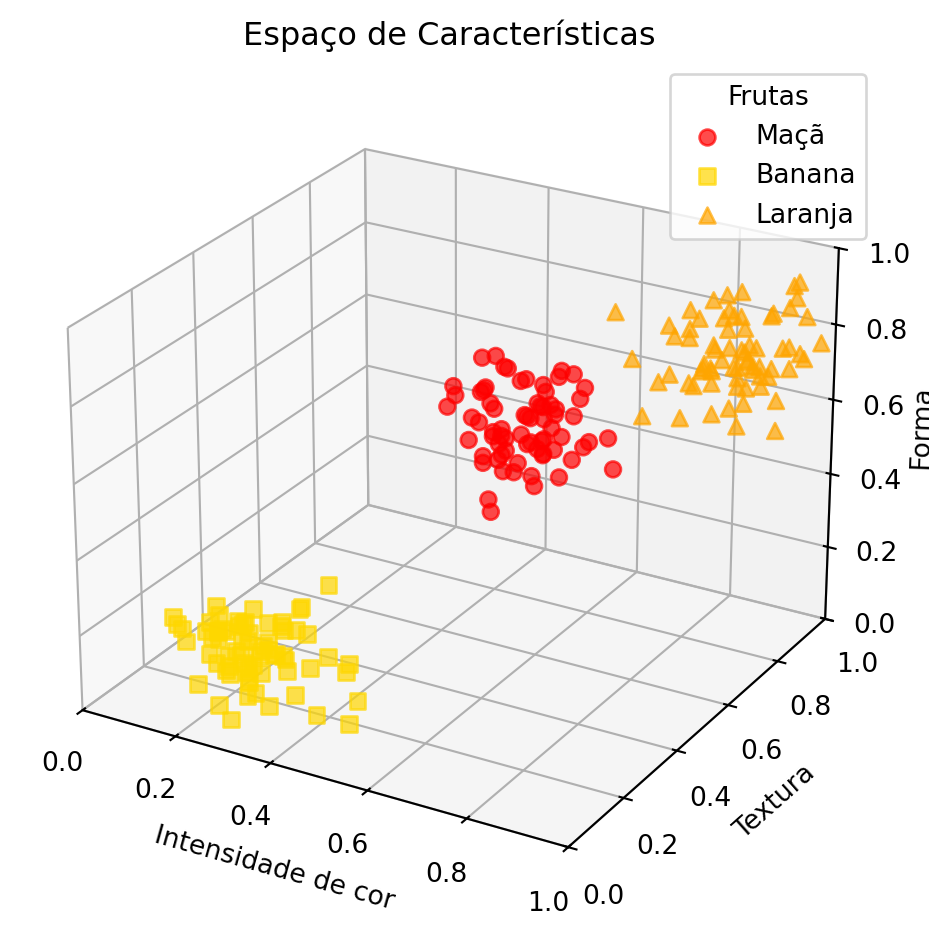

**Figura 7.1:** Ejemplo motivacional: diferentes frutas formando agrupaciones distintas en un espacio de características.


In [2]:
np.random.seed(42)

centros = {
    "Maçã":    [0.8, 0.2, 0.9],
    "Banana":  [0.3, 0.1, 0.2],
    "Laranja": [0.9, 0.8, 0.8],
}

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(projection="3d")

for fruta, centro, cor, marcador in zip(
    centros,
    centros.values(),
    ["red", "gold", "orange"],
    ["o", "s", "^"],
):
    X = np.clip(np.random.normal(centro, 0.08, (70, 3)), 0, 1)
    ax.scatter(X[:, 0], X[:, 1], X[:, 2],
               c=cor, marker=marcador, s=35,
               alpha=0.7, label=fruta)

ax.set(
    xlim=(0,1), ylim=(0,1), zlim=(0,1),
    xlabel="Intensidade de cor",
    ylabel="Textura",
    zlabel="Forma",
    title="Espaço de Características"
)
ax.view_init(elev=25, azim=-60)
ax.legend(title="Frutas")
ax.zaxis.labelpad = 0.01

plt.tight_layout()
plt.show()

## 7.4 🗺️ Panorama del Capítulo: El *Pipeline* Clásico de Clasificación de Imágenes

Antes de continuar, resulta útil presentar una visión integrada de lo que se
estudiará. La [Figura 7.2](#fig-07-infografo) muestra el flujo general de un sistema
clásico de clasificación de imágenes, desde la imagen de entrada hasta la
etapa de asignación de la etiqueta final. En las próximas secciones, cada una de
las etapas de este proceso se estudiará en detalle.

<figure id="fig-07-infografo" style="text-align:center; margin:1em 0;">
  <img src="imagens/fig-07-infografo.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 7.2:</strong> Panorama del *pipeline* clásico de clasificación de imágenes: extracción de descriptores (LBP, HOG), formación del espacio de características y clasificación mediante k-NN. No se aplica a modelos de Aprendizaje Profundo (CNNs, YOLO), que aprenden *features* de extremo a extremo directamente de los píxeles. **Fuente:** elaborado con ayuda de Gemini Notebook ({GOOGLE}, 2025).</figcaption>
</figure>

> ### 📝 Alcance de este capítulo
>
> En este capítulo, el enfoque recae exclusivamente sobre el clasificador k-NN,
> por su simplicidad didáctica y por ilustrar de forma intuitiva el
> concepto de espacio de características. Otros clasificadores
> tradicionales ampliamente utilizados en Reconocimiento de Patrones — como
> Árboles de Decisión, Reglas de Clasificación y Máquinas de Vectores de
> Soporte (SVM) — se discuten en profundidad en
> Quilici-gonzalez (2014), especialmente en su 2ª edición, actualmente
> en producción (QUILICI-GONZALEZ, 2026).

## 7.5 Fundamentos del Reconocimiento de Patrones

Un sistema de **reconocimiento de patrones** tiene como objetivo asignar una
categoría (etiqueta) a una observación — una imagen completa, una región de
interés o una señal — con base en ejemplos previamente etiquetados. De
forma general, este proceso se organiza en las siguientes etapas:

1. **Adquisición:** obtención de la imagen o de la señal que se va a clasificar;
2. **Preprocesamiento:** normalización, eliminación de ruido, corrección
   geométrica o de iluminación — etapas ya estudiadas en los capítulos
   anteriores;
3. **Extracción de descriptores (*features*):** transformación de la imagen en
   un **vector de características** de dimensión fija, que representa las
   propiedades relevantes para la tarea de clasificación;
4. **Clasificación:** aplicación de un modelo que asocia el vector de
   características a una clase;
5. **Evaluación:** análisis del rendimiento del modelo en un conjunto de datos
   independiente de aquel utilizado para el entrenamiento.

El conjunto de todos los vectores de características posibles constituye el
**espacio de características** (*feature space*). Un buen descriptor produce
representaciones que aproximan, en ese espacio, observaciones de la misma clase y
alejan observaciones de clases distintas. Esta propiedad favorece
métodos de clasificación basados en proximidad, como el **k-NN**, y
también beneficia a diversos otros clasificadores.

La [Figura 7.1](#fig-07-frutas-motivacao) ilustra este concepto de forma esquemática:
cada fruta se representa mediante un punto en un espacio de características de
tres dimensiones (color, textura y forma). Aunque ese espacio sea solo una
simplificación didáctica, muestra cómo las muestras de la misma clase tienden a
formar agrupaciones, mientras que clases diferentes ocupan regiones distintas,
facilitando la tarea de clasificación.

## 7.6 Extracción de Descriptores Clásicos

Antes de la popularización de las redes neuronales profundas, los descriptores de
imagen eran, en su mayoría, diseñados manualmente por expertos
(*hand-crafted features*), con base en propiedades estadísticas o
geométricas conocidas. Tres familias clásicas son particularmente
relevantes:

* **Descriptores de color:** histogramas de intensidad o de matiz,
  que capturan la distribución de los valores de color de una región, ya
  introducidos en el **Capítulo 3** mediante la función `mm.hist`;
* **Descriptores de textura:** capturan patrones locales de repetición,
  rugosidad u orientación, como el *Local Binary Patterns* (LBP),
  estudiado a continuación;
* **Descriptores de forma/gradiente:** describen la distribución de los
  bordes y de las orientaciones del gradiente, como el *Histogram of Oriented
  Gradients* (HOG), ampliamente empleado en la detección de personas y
  otros objetos.

Para comparar la información capturada por cada enfoque, la [Figura 7.3](#fig-07-visualizacao-descritores)
muestra cómo diferentes técnicas "ven" la misma imagen.

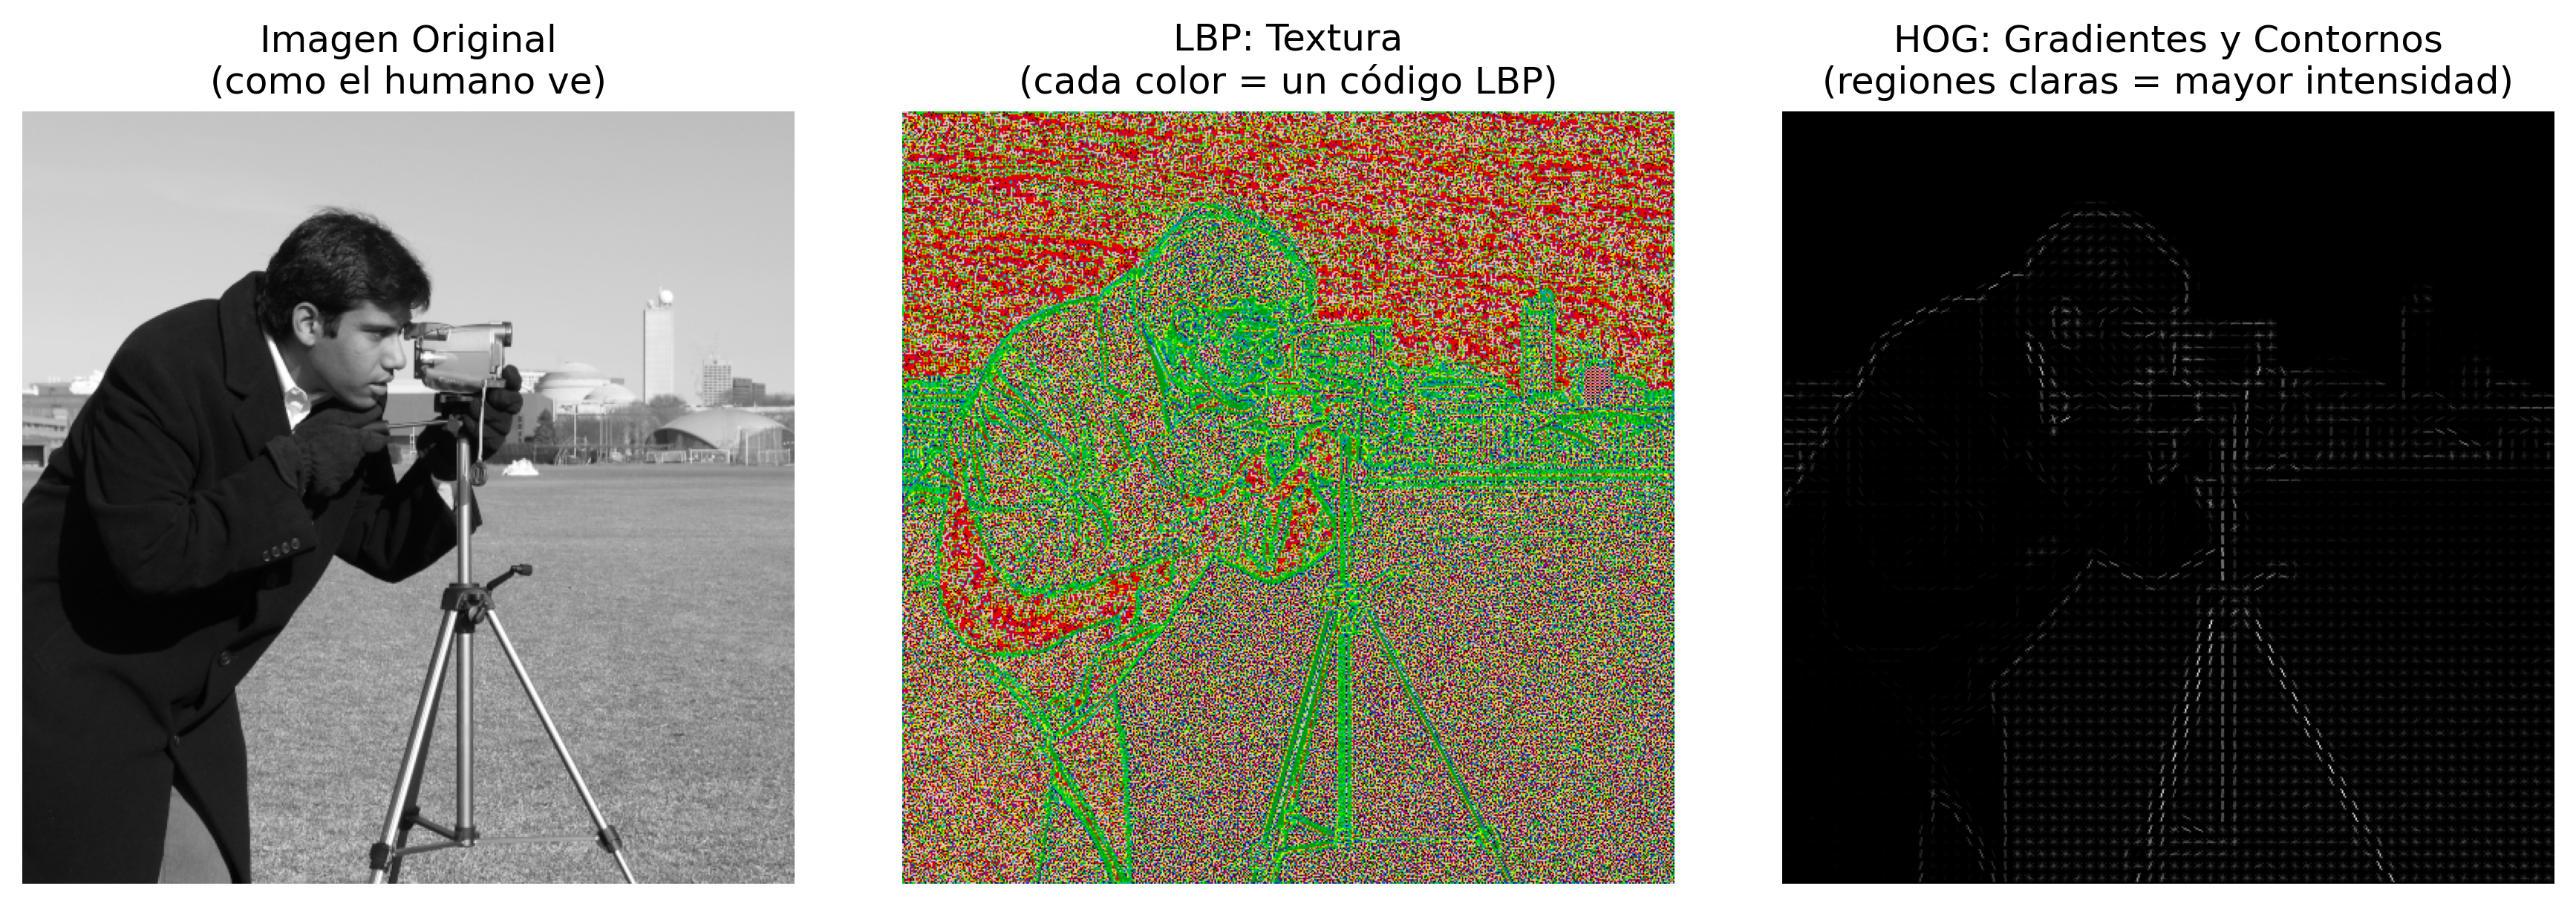

**Figura 7.3:** Comparación visual de diferentes descriptores aplicados a la misma imagen. Cada descriptor revela aspectos distintos de la escena.


Observa cómo cada descriptor resalta propiedades diferentes:
• LBP: evidencia patrones locales de textura.
• HOG: evidencia contornos y orientaciones de los bordes.
• Imagen original: contiene solo los valores de intensidad.


In [3]:
# Cargar imagen de ejemplo
imagem = skdata.camera()

# Aplicar descriptores
lbp_img = local_binary_pattern(
    imagem, 
    P=8, 
    R=1, 
    method="uniform"
    )

# Convertir el LBP a RGB solo para facilitar la visualización
lbp_norm = (lbp_img - lbp_img.min()) / (lbp_img.max() - lbp_img.min() + 1e-8)
lbp_rgb = (cm.nipy_spectral(lbp_norm)[..., :3] * 255).astype("uint8")

hog_features, hog_img = hog(
    imagem,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    visualize=True,
)

# Exhibición estandarizada
mm.show(
    [imagem, lbp_rgb, hog_img],
    titles=[
        "Imagen Original\n(como el humano ve)",
        "LBP: Textura\n(cada color = un código LBP)",
        "HOG: Gradientes y Contornos\n(regiones claras = mayor intensidad)",
    ],
    cols=3,
    figsize=(12, 4),
)

print("Observa cómo cada descriptor resalta propiedades diferentes:")
print("• LBP: evidencia patrones locales de textura.")
print("• HOG: evidencia contornos y orientaciones de los bordes.")
print("• Imagen original: contiene solo los valores de intensidad.")

### 7.6.1 *Local Binary Patterns* (LBP)

El LBP es un descriptor de textura que codifica, para cada píxel central
$g_c$, la relación entre su intensidad y la de los $P$ vecinos dispuestos en
una vecindad circular de radio $R$:

$$
\mathrm{LBP}_{P,R}(x_c, y_c) = \sum_{p=0}^{P-1} s(g_p - g_c)\, 2^p,
\qquad
s(z) =
\begin{cases}
1, & z \geq 0 \\
0, & z < 0
\end{cases}
$$

donde:

- $(x_c, y_c)$ son las coordenadas del píxel central;
- $g_c$ es la intensidad del píxel central;
- $g_p$ es la intensidad del $p$-ésimo píxel vecino;
- $P$ es el número de vecinos considerados;
- $R$ es el radio de la vecindad circular;
- $p$ es el índice del vecino, con $p = 0, 1, \ldots, P-1$;
- $s(z)$ es la función de umbral definida en la ecuación, donde $z = g_p - g_c$;
  toma el valor 1 cuando $z \geq 0$ y 0 cuando $z < 0$;
- $2^p$ corresponde al peso binario asociado al $p$-ésimo vecino.

El código LBP obtenido describe el patrón local de contraste alrededor del píxel. El histograma de estos códigos forma un vector de características compacto para representar la textura de la imagen ([Figura 7.4](#fig-07-vetor-lbp)). En este capítulo se utiliza la variante **uniforme**, que agrupa los patrones no uniformes en una única categoría, reduciendo la dimensionalidad y aumentando la robustez del descriptor.

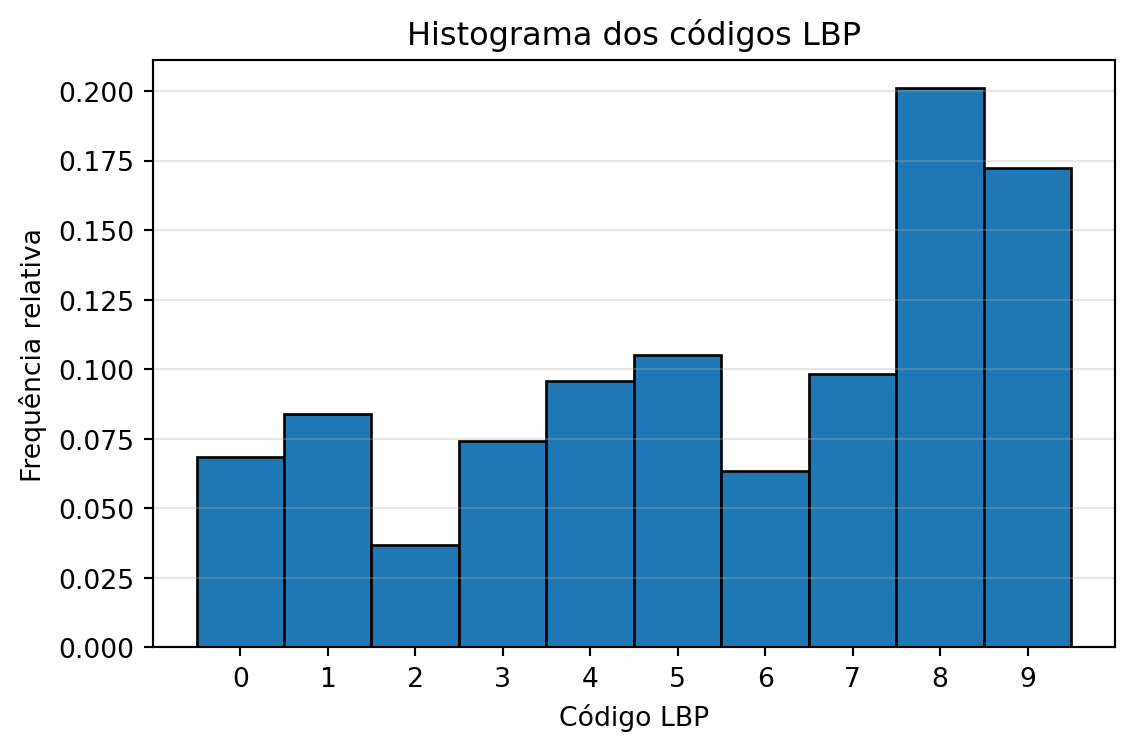

**Figura 7.4:** Histograma de los códigos LBP de la imagen de los camarógrafos. Cada barra representa la frecuencia relativa de un código LBP, formando el vector de características utilizado para describir la textura.


In [4]:
plt.figure(figsize=(6, 4))

plt.hist(
    lbp_img.ravel(),
    bins=np.arange(-0.5, lbp_img.max() + 1.5, 1),
    density=True,
    edgecolor="black",
)

plt.title("Histograma dos códigos LBP")
plt.xlabel("Código LBP")
plt.ylabel("Frequência relativa")
plt.xticks(range(int(lbp_img.max()) + 1))
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

> ### 💡 Función `local_binary_pattern`
>
> La implementación utilizada en este capítulo es proporcionada por la biblioteca
> `scikit-image`:
>
> ```python
> local_binary_pattern(
>     imagem,
>     P=8,
>     R=1,
>     method="uniform"
> )
> ```
>
> donde:
>
> * `image`: imagen en escala de grises;
> * `P`: número de vecinos igualmente espaciados en la vecindad circular;
> * `R`: radio de la vecindad, en píxeles;
> * `method`: estrategia de codificación. En este capítulo se utiliza el valor
>   `"uniform"`.
>
> La ecuación presentada anteriormente describe el **LBP original**. En la
> implementación adoptada en este capítulo, la opción `method="uniform"`
> calcula inicialmente ese código y, a continuación, reasigna los patrones no
> uniformes a una única categoría, reduciendo la dimensionalidad del
> descriptor y haciéndolo más robusto ante pequeñas variaciones locales.

La [Figura 7.3](#fig-07-visualizacao-descritores) presenta la representación visual del LBP, mientras que la [Figura 7.4](#fig-07-vetor-lbp) muestra el histograma de los códigos LBP utilizado como vector de características.

El **Proyecto Práctico 2** (sección **Comparación de Descriptores para Clasificación de Texturas**) emplea el LBP en la clasificación de diferentes tipos de textura sintética.

### 7.6.2 *Histograma de Gradientes Orientados* (HOG)

El HOG es un descriptor que representa la forma de un objeto mediante la distribución de las orientaciones del gradiente local. Así como en el operador de Canny (**Capítulo 6**), inicialmente se calcula el gradiente:

$$
|\nabla f(x,y)| =
\sqrt{\left(\frac{\partial f}{\partial x}\right)^2 +
      \left(\frac{\partial f}{\partial y}\right)^2},
\qquad
\theta(x,y) =
\operatorname{atan2}\!\left(
\frac{\partial f}{\partial y},
\frac{\partial f}{\partial x}
\right).
$$

donde:

- $f(x,y)$ es la intensidad de la imagen en el píxel $(x,y)$;
- $\frac{\partial f}{\partial x}$ y $\frac{\partial f}{\partial y}$ son, respectivamente, las derivadas parciales de la imagen en las direcciones horizontal y vertical;
- $|\nabla f(x,y)|$ es la magnitud del vector gradiente en el píxel $(x,y)$, que indica la intensidad de la variación local de la imagen;
- $\theta(x,y)$ es la orientación del vector gradiente en el píxel $(x,y)$, calculada mediante la función $\operatorname{atan2}$, cuyo resultado pertenece al intervalo $(-\pi,\pi]$.

Aunque $\theta(x,y)$, tal como se calcula con la función $\operatorname{atan2}$, pertenece al intervalo $(-\pi,\pi]$, la implementación estándar del HOG utiliza el **gradiente no signado** (*unsigned*): las orientaciones opuestas (por ejemplo, $0$ y $\pi$) se tratan como equivalentes, y los ángulos se mapean al intervalo $[0,\pi)$ antes de construir el histograma. Esta elección hace que el descriptor sea invariante a la dirección del contraste (por ejemplo, un borde claro-oscuro y un borde oscuro-claro producen la misma orientación).

La imagen se divide entonces en **celdas** (*cells*). Para cada celda, se construye un histograma de las orientaciones del gradiente, ponderado por la magnitud correspondiente. La concatenación de los histogramas de todas las celdas forma el vector de características HOG, que representa la distribución espacial de las orientaciones del gradiente y captura información sobre la forma y los contornos del objeto ([Figura 7.5](#fig-07-vetor-hog)).

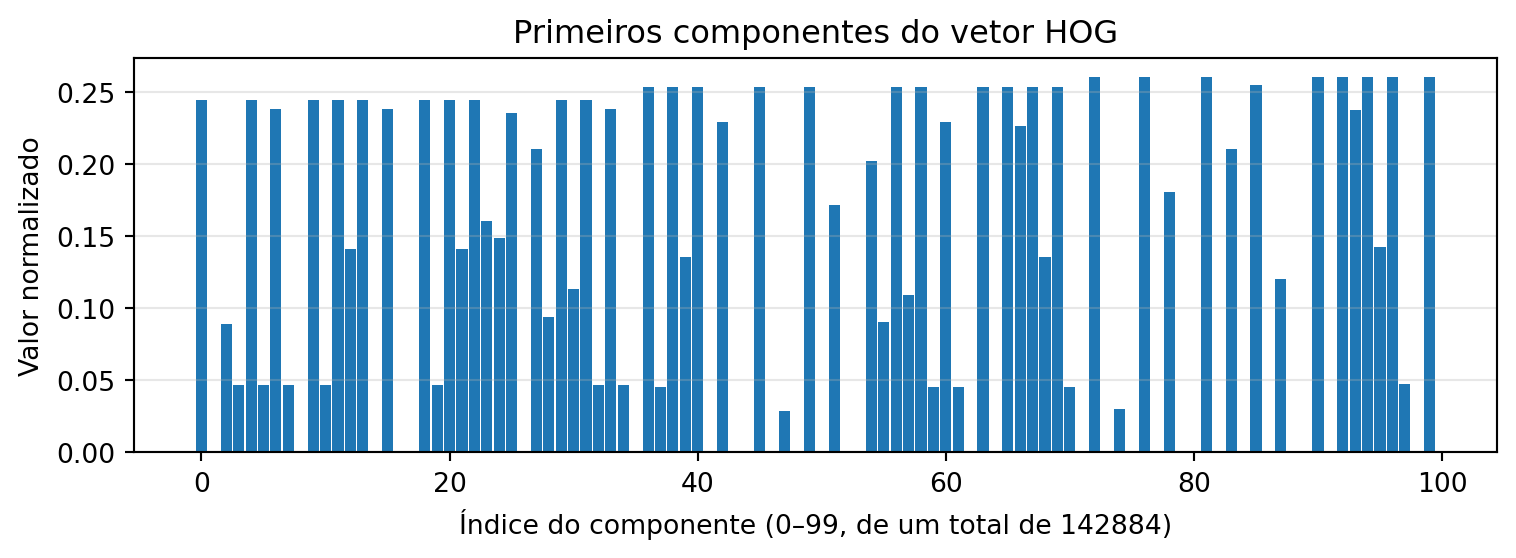

**Figura 7.5:** Primeros 100 componentes del vector de características HOG.


In [5]:
n = 100

plt.figure(figsize=(8, 3))
plt.bar(
    range(n),
    hog_features[:n],
    width=0.9
)

plt.title("Primeiros componentes do vetor HOG")
plt.xlabel(f"Índice do componente (0–{n-1}, de um total de {hog_features.shape[0]})")
plt.ylabel("Valor normalizado")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

> ### 💡 Función `hog`
>
> La extracción del descriptor HOG se realiza mediante la función:
>
> ```python
> hog(
>     image,
>     orientations=9,
>     pixels_per_cell=(8, 8),
>     cells_per_block=(2, 2),
>     visualize=True,
> )
> ```
>
> Los parámetros principales son:
>
> * `image`: imagen de entrada;
> * `orientations`: número de divisiones angulares del histograma de orientaciones en cada celda;
> * `pixels_per_cell`: tamaño, en píxeles, de cada celda donde se calcula el histograma;
> * `cells_per_block`: número de celdas utilizadas en la normalización del descriptor;
> * `visualize`: cuando es `True`, devuelve también una imagen que ilustra los gradientes utilizados por el HOG.
>
> La ecuación presentada anteriormente describe el cálculo de la magnitud y la
> orientación del gradiente, que constituyen la base del descriptor HOG. En la
> implementación adoptada en este capítulo, la función `hog()` utiliza esta
> información para construir histogramas de orientaciones en cada celda de la
> imagen y, a continuación, realiza la normalización en bloques (`cells_per_block`),
> reduciendo la sensibilidad del descriptor a variaciones de iluminación y contraste.


La [Figura 7.3](#fig-07-visualizacao-descritores) presenta la representación visual del HOG, mientras que la [Figura 7.5](#fig-07-vetor-hog) ilustra los primeros componentes del vector de características extraído de la imagen.

El **Proyecto Práctico 1** (sección **Clasificación de Dígitos Manuscritos con k-NN**)
compara el rendimiento de los descriptores HOG con el uso directo de las intensidades
de los píxeles como vector de características.

### 7.6.3 El Impacto de la Escala y la Normalización de Características

El clasificador $k$-NN toma sus decisiones basándose en la distancia entre los
vectores de características. Por ello, la escala de cada característica
influye directamente en el resultado de la clasificación. Si una variable
presenta valores mucho mayores que las demás (por ejemplo, una
intensidad de color que varía de $0$ a $255$, mientras que un índice de
circularidad varía de $0$ a $1$), tiende a dominar el cálculo de la
distancia, reduciendo la influencia de los otros descriptores.

Para evitar este problema, se aplica una etapa de **normalización de las
características**, generalmente mediante la estandarización (*Z-score
standardization*). En este procedimiento, cada característica pasa a tener
media igual a cero y desviación estándar igual a uno, haciendo comparables
magnitudes originalmente medidas en escalas diferentes.

La estandarización se realiza mediante la transformación

$$
z = \frac{x - \mu}{\sigma},
$$

donde:

- $x$ es el valor original de la característica;
- $\mu$ es la media de esa característica calculada sobre el conjunto de entrenamiento;
- $\sigma$ es la desviación estándar de la característica;
- $z$ es el valor estandarizado.

Después de esta transformación, todas las características pasan a tener media
igual a cero y desviación estándar igual a uno, permitiendo que contribuyan de
forma equilibrada al cálculo de las distancias.

> ### 💡 Clase `StandardScaler`
>
> La estandarización utilizada en este capítulo se realiza mediante la clase
> `StandardScaler`, de la biblioteca `scikit-learn`:
>
> ```python
> from sklearn.preprocessing import StandardScaler
>
> scaler = StandardScaler()
> X_norm = scaler.fit_transform(X)
> ```
>
> donde:
>
> * `StandardScaler()`: crea el objeto responsable de la estandarización;
> * `fit_transform(X)`: calcula la media y la desviación estándar de cada
>   característica del conjunto `X` y devuelve la matriz estandarizada.
>
> En la práctica, el método `fit_transform()` ejecuta dos etapas: primero
> (`fit`), estima la media ($\mu$) y la desviación estándar ($\sigma$) de cada
> característica; a continuación (`transform`), aplica la transformación de estandarización presentada anteriormente a todos los valores de la matriz de entrada.

La [Figura 7.6](#fig-07-normalizacao-features) muestra el efecto de la normalización.
Visualmente, la distribución de los puntos permanece igual; lo que cambia es la
escala de los ejes. Sin la normalización, la característica de mayor
magnitud domina el cálculo de las distancias entre las muestras. Tras la estandarización, todas las características pasan a contribuir de
forma equilibrada al cálculo de las distancias utilizadas por el
clasificador $k$-NN.

Efecto de la normalización:
  Característica 1: escala ≈ 100
  Característica 2: escala ≈ 1

Sin normalización, la primera característica domina el cálculo de las distancias.
Con normalización, ambas contribuyen de forma equilibrada.

La normalización es esencial cuando las características poseen escalas diferentes.


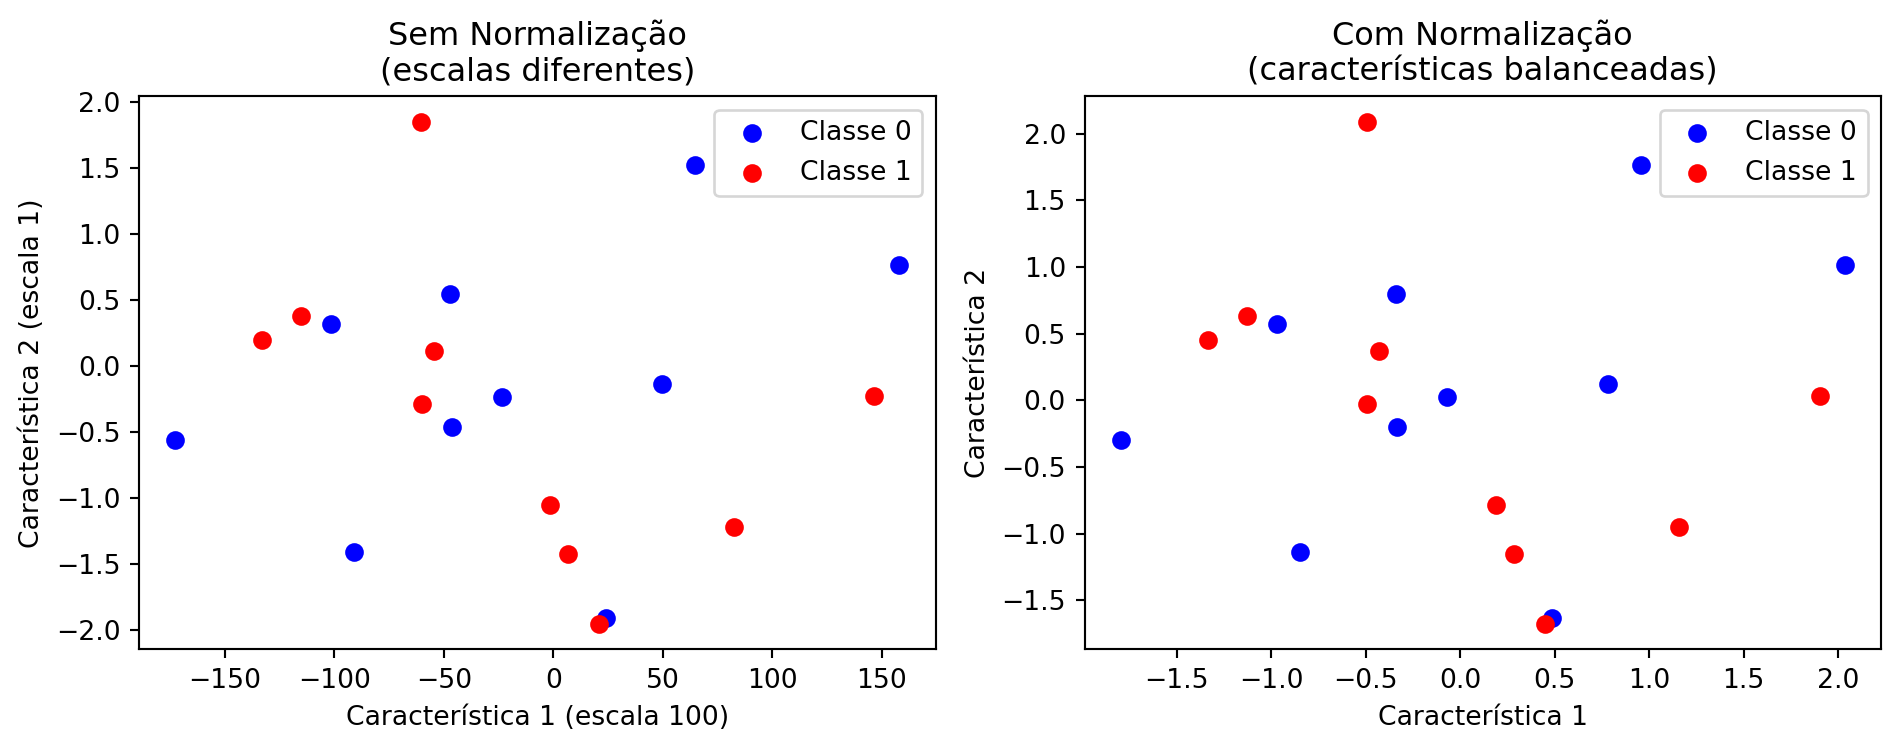

**Figura 7.6:** Importancia de la normalización de las características para el clasificador k-NN.


In [6]:
# Datos sintéticos con escalas muy diferentes
np.random.seed(42)
X_demo = np.random.randn(20, 2) * [100, 1]
y_demo = np.array([0] * 10 + [1] * 10)

print("Efecto de la normalización:")
print("  Característica 1: escala ≈ 100")
print("  Característica 2: escala ≈ 1")
print("\nSin normalización, la primera característica domina el cálculo de las distancias.")
print("Con normalización, ambas contribuyen de forma equilibrada.")
print("\nLa normalización es esencial cuando las características poseen escalas diferentes.")
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Sin normalización
axes[0].scatter(
    X_demo[y_demo == 0, 0], X_demo[y_demo == 0, 1],
    c="blue", label="Classe 0"
)
axes[0].scatter(
    X_demo[y_demo == 1, 0], X_demo[y_demo == 1, 1],
    c="red", label="Classe 1"
)
axes[0].set_title("Sem Normalização\n(escalas diferentes)")
axes[0].set_xlabel("Característica 1 (escala 100)")
axes[0].set_ylabel("Característica 2 (escala 1)")
axes[0].legend()

# Con normalización
scaler = StandardScaler()
X_norm = scaler.fit_transform(X_demo)

axes[1].scatter(
    X_norm[y_demo == 0, 0], X_norm[y_demo == 0, 1],
    c="blue", label="Classe 0"
)
axes[1].scatter(
    X_norm[y_demo == 1, 0], X_norm[y_demo == 1, 1],
    c="red", label="Classe 1"
)
axes[1].set_title("Com Normalização\n(características balanceadas)")
axes[1].set_xlabel("Característica 1")
axes[1].set_ylabel("Característica 2")
axes[1].legend()

plt.tight_layout()
plt.show()

## 7.7 📌 Mapa Conceptual

Hasta aquí, se han presentado los descriptores clásicos (LBP, HOG, píxeles
brutos) y la forma en que organizan las muestras en un espacio de
características. La [Figura 7.7](#fig-07-mapa-conceitual) sintetiza ese recorrido y
sitúa estas etapas dentro del flujo general de un sistema clásico de
clasificación de imágenes, indicando también las etapas siguientes —
clasificación (k-NN) y evaluación de los
resultados — que se formalizarán en las próximas secciones.

<figure id="fig-07-mapa-conceitual" style="text-align:center; margin:1em 0;">
  <img src="imagens/fig-07-mapa-conceitual.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 7.7:</strong> Mapa conceptual del proceso de clasificación de imágenes utilizando descriptores clásicos (LBP, HOG, píxeles brutos) y clasificador tradicional (k-NN). No se aplica a modelos de Aprendizaje Profundo (CNNs, YOLO), que aprenden *features end-to-end* directamente de los píxeles.</figcaption>
</figure>

## 7.8 Descriptores en la Práctica

Tras conocer los principales descriptores clásicos, es natural preguntarse
cómo influyen en el rendimiento de un clasificador en situaciones
cercanas a las que se encuentran en la práctica.

En esta sección, se compara el uso de tres representaciones distintas de
las mismas imágenes: intensidades de los píxeles, descriptores LBP y descriptores
HOG. Para hacer el experimento más realista, se añade ruido sintético
a los datos, en intensidades diferentes para cada descriptor — una forma
simplificada de simular el hecho de que, en la práctica, diferentes
representaciones toleran de manera desigual las imperfecciones de la captura
(ruido del sensor, pequeñas variaciones de posición, etc.).

La [Figura 7.8](#fig-07-matrizes-confusao) presenta las matrices de confusión obtenidas
para cada descriptor, permitiendo identificar en qué clases ocurren los
principales errores de clasificación.
La interpretación de estas matrices fue introducida en el **Capítulo 1**, cuando
se presentaron los conceptos de **Verdadero Positivo (VP)**,
**Falso Positivo (FP)**, **Verdadero Negativo (VN)** y **Falso Negativo (FN)**.
Estos conceptos fueron explorados en los **EPs 01_02** (métricas de clasificación)
y **01_03** (*mean Average Precision* – mAP), disponibles en:

- <https://fzampirolli.github.io/pdi-vc/eps/py.pt/EP01_02.html>
- <https://fzampirolli.github.io/pdi-vc/eps/py.pt/EP01_03.html>

En este capítulo, las matrices de confusión se emplean para analizar
cómo diferentes descriptores influyen en el rendimiento del clasificador.

A continuación, la [Figura 7.9](#fig-07-comparacao-descritores-detalhada) resume la precisión
global obtenida por cada descriptor.

Los resultados muestran que el rendimiento del clasificador depende
directamente de la representación elegida para describir las imágenes.
Mientras que el uso directo de las intensidades de los píxeles es más sensible a las
degradaciones introducidas, los descriptores LBP y HOG preservan mejor la
información relevante para la clasificación, resultando en un mayor
rendimiento en este escenario. Es importante resaltar que los niveles de ruido
aplicados a cada descriptor fueron elegidos solo con fines didácticos,
de modo que ilustren el principio general de que descriptores más elaborados
*pueden* ser más robustos a degradaciones — lo que no significa que esta
relación se verifique siempre, como el estudio de caso de la próxima sección
demostrará.

> ### 💡 Cómo se realiza el experimento
>
> Dado que el objetivo de esta sección es comparar únicamente el efecto de los descriptores,
> se genera un conjunto de datos sintético simple: tres nubes de puntos
> gaussianas, centradas en los mismos valores de "color, textura y forma" ya
> utilizados en la [Figura 7.1](#fig-07-frutas-motivacao) — el mismo patrón empleado desde el
> inicio del capítulo para representar las tres clases de frutas.
>
> ```python
> import numpy as np
> from sklearn.model_selection import train_test_split
> from sklearn.neighbors import KNeighborsClassifier
> from sklearn.metrics import accuracy_score, confusion_matrix
> ```
>
> ```python
> centros = {
>     "Maçã":    [0.8, 0.2, 0.9],
>     "Banana":  [0.3, 0.1, 0.2],
>     "Laranja": [0.9, 0.8, 0.8],
> }
>
> n_por_classe = 100
> X = np.vstack([
>     np.random.normal(centro, 0.12, (n_por_classe, 3))
>     for centro in centros.values()
> ])
> y = np.repeat(list(centros.keys()), n_por_classe)
> ```
>
> donde:
>
> * `centros`: diccionario con el punto medio de cada clase en el espacio de características (color, textura, forma);
> * `n_por_classe`: número de muestras generadas por clase;
> * `np.random.normal(centro, 0.12, (n_por_classe, 3))`: genera `n_por_classe` muestras alrededor de cada centro, con desviación estándar 0,12 en cada dimensión;
> * `np.repeat(list(centros.keys()), n_por_classe)`: genera el vector de etiquetas correspondiente, en el mismo orden que los centros.
>
> A continuación, se utiliza el flujo de entrenamiento y evaluación:
>
> * `train_test_split(X, y, test_size=0.3)`: divide los datos en entrenamiento (70%) y prueba (30%);
> * `KNeighborsClassifier(n_neighbors=5)`: crea un clasificador $k$-NN con $k=5$ vecinos;
> * `fit(X_train, y_train)`: ajusta el modelo a los datos de entrenamiento;
> * `predict(X_test)`: clasifica las muestras de prueba;
> * `accuracy_score(y_test, y_pred)`: calcula la precisión;
> * `confusion_matrix(y_test, y_pred)`: genera la matriz de confusión.
>
> En este experimento, el conjunto de entrenamiento, el clasificador y el método
> de evaluación permanecen exactamente los mismos. La única diferencia entre los
> experimentos es la representación utilizada para cada imagen (píxeles
> brutos, LBP o HOG), lo que permite evaluar exclusivamente la influencia del
> descriptor sobre el rendimiento del clasificador.

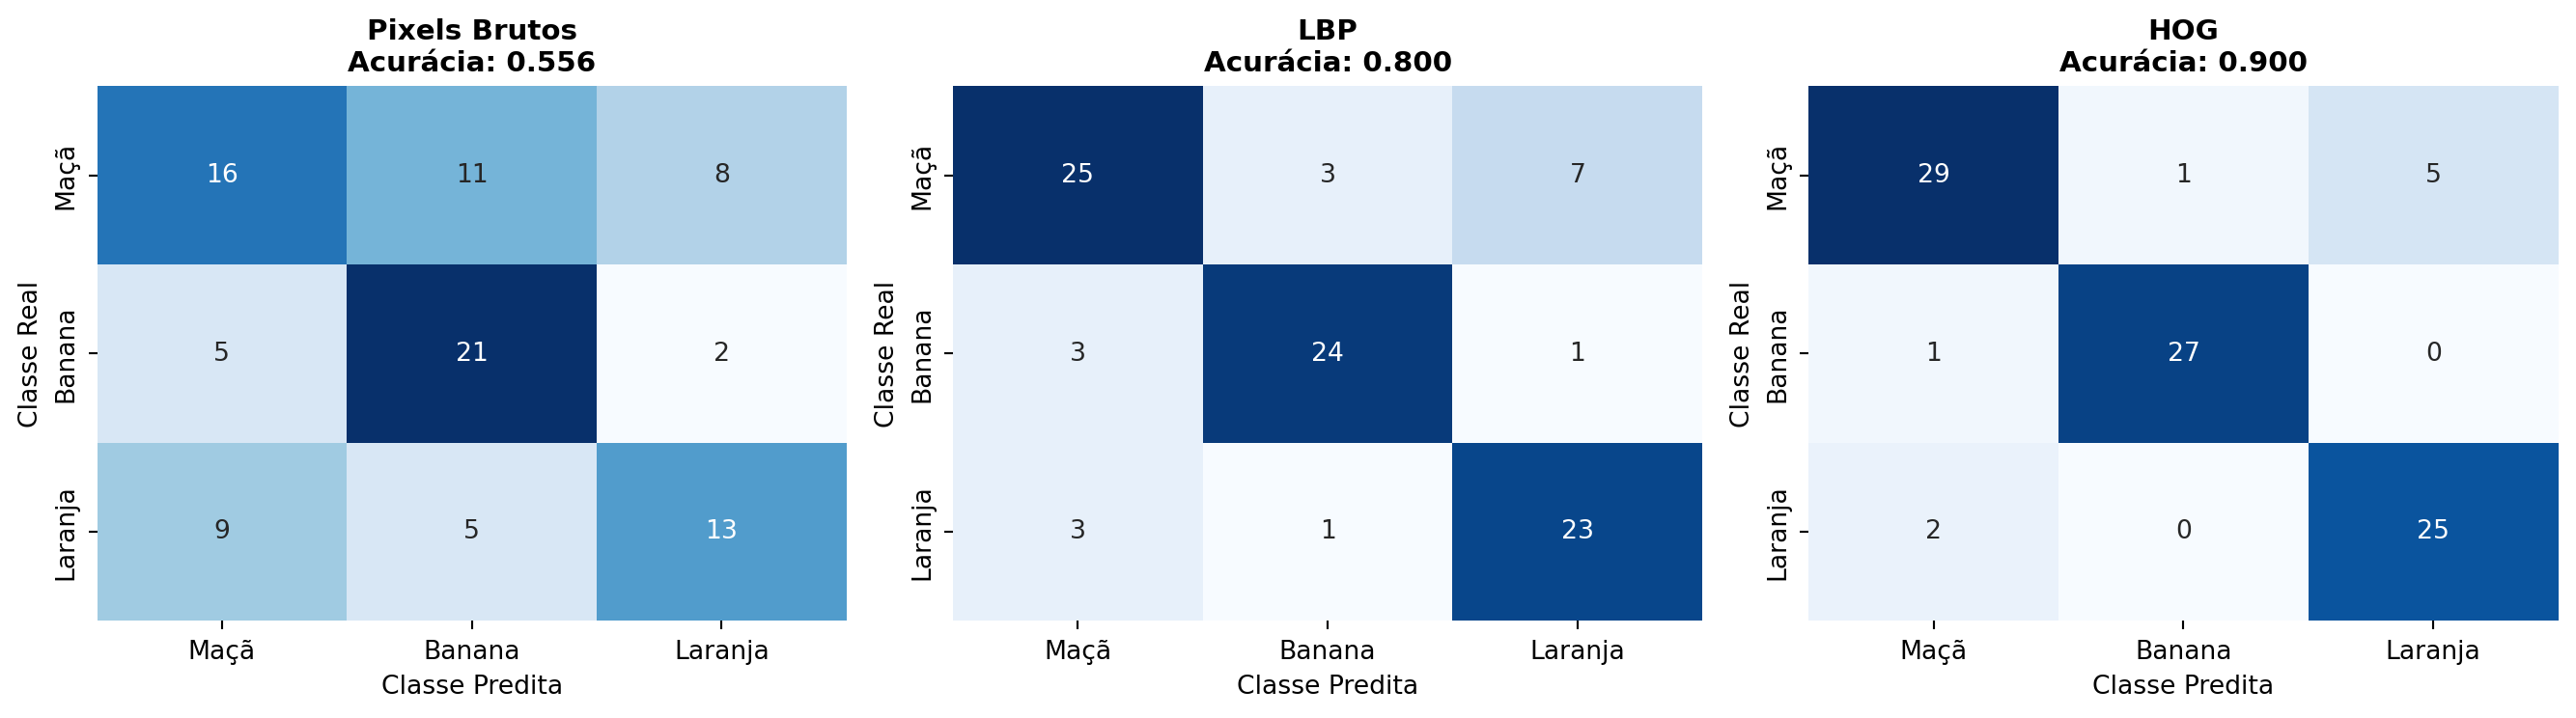

**Figura 7.8:** Matrices de confusión obtenidas por el clasificador k-NN utilizando tres descriptores diferentes. Las filas representan la clase real (Manzana, Plátano y Naranja) y las columnas la clase predicha. Cuanto mayor sea la concentración de valores en la diagonal principal, mejor será el desempeño del descriptor.


In [7]:
classes = ["Maçã", "Banana", "Laranja"]

np.random.seed(42)

# Mismos centros de clase (color, textura, forma) utilizados en el
# ejemplo anterior, ahora reutilizados para generar los datos
# sintéticos de entrenamiento y prueba de este experimento.
centros = {
    "Maçã":    [0.8, 0.2, 0.9],
    "Banana":  [0.3, 0.1, 0.2],
    "Laranja": [0.9, 0.8, 0.8],
}

n_por_classe = 100
X = np.vstack([
    np.random.normal(centro, 0.12, (n_por_classe, 3))
    for centro in centros.values()
])
y = np.repeat(list(centros.keys()), n_por_classe)

# Simular descriptores con diferentes niveles de sensibilidad al ruido.
# Cuanto mayor sea el ruido añadido, peor tiende a ser la representación.
descritores = {
    "Pixels Brutos": X + 0.5 * np.random.randn(*X.shape),
    "LBP":           X + 0.3 * np.random.randn(*X.shape),
    "HOG":           X + 0.2 * np.random.randn(*X.shape),
}

# Crear una única figura con 3 subplots lado a lado para las matrices
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
resultados = {}

for idx, (nome, Xd) in enumerate(descritores.items()):
    X_train, X_test, y_train, y_test = train_test_split(Xd, y, test_size=0.3, random_state=42)
    
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    resultados[nome] = acc
    
    # Matriz de confusión en el subplot correspondiente

    cm = confusion_matrix(y_test, y_pred, labels=classes)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=classes,
        yticklabels=classes,
        ax=axes[idx],
    )

    axes[idx].set_title(
        f"{nome}\nAcurácia: {acc:.3f}",
        fontsize=11,
        fontweight="bold"
    )
    axes[idx].set_xlabel("Classe Predita")
    axes[idx].set_ylabel("Classe Real")


plt.tight_layout()
plt.show()


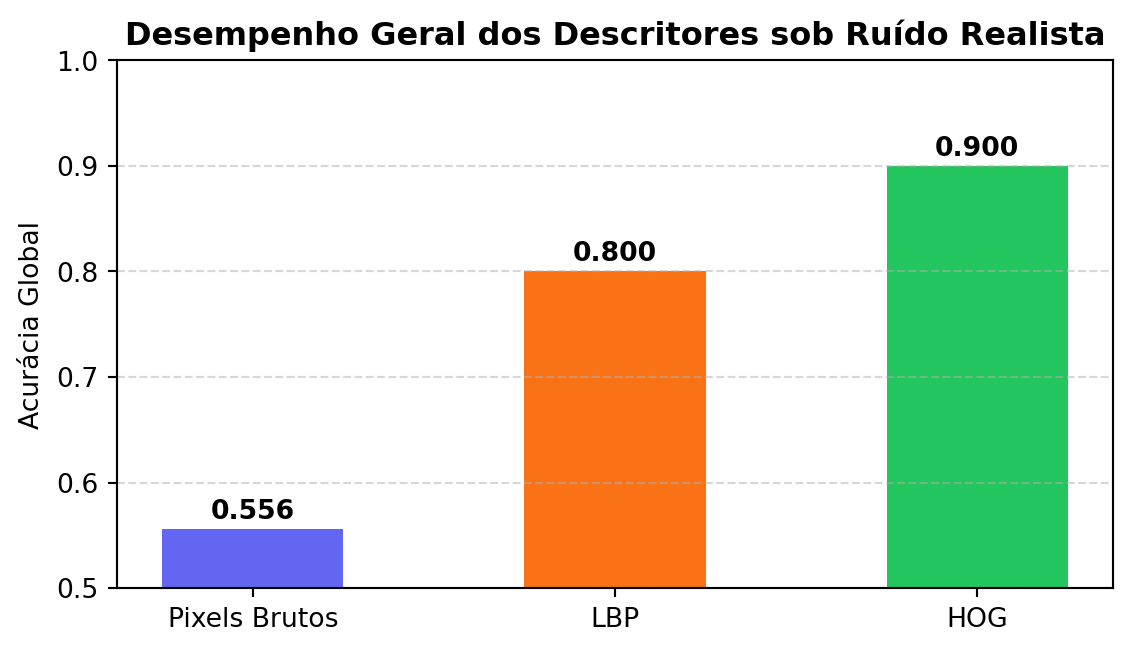

**Figura 7.9:** Comparación detallada de precisión global en escenario realista. Observe cómo los descriptores extraídos estructuralmente (LBP y HOG) superan el uso de intensidades puras de píxeles brutos.


Análisis de los resultados:
- Píxeles Brutos: Sensibles a variaciones locales de iluminación y ruido.
- LBP: Buena tolerancia para variaciones monótonas de iluminación global.
- HOG: Excelente para contornos y formas estables bajo pequeñas fluctuaciones geométricas.


In [8]:
# Comparación visual en una figura aislada
plt.figure(figsize=(6, 3.5))
nomes = list(resultados.keys())
acuracia = list(resultados.values())
colors = ['#6366f1', '#f97316', '#22c55e']

bars = plt.bar(nomes, acuracia, color=colors, width=0.5)
plt.ylabel('Acurácia Global')
plt.title('Desempenho Geral dos Descritores sob Ruído Realista', fontsize=12, fontweight='bold')
plt.ylim(0.5, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Agregar los valores encima de las barras usando round estándar para visualización
for bar, val in zip(bars, acuracia):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print("Análisis de los resultados:")
print("- Píxeles Brutos: Sensibles a variaciones locales de iluminación y ruido.")
print("- LBP: Buena tolerancia para variaciones monótonas de iluminación global.")
print("- HOG: Excelente para contornos y formas estables bajo pequeñas fluctuaciones geométricas.")

## 7.9 Un Problema Concreto: Simulando Descriptores de Frutas

Retomando el problema de clasificación de frutas presentado al inicio del capítulo, cada imagen puede representarse mediante un vector de características (*feature vector*) obtenido a partir de la extracción de descriptores de color, textura y forma. La [Tabela 7.1](#tbl-descritores-frutas) presenta algunos descriptores frecuentemente utilizados en aplicaciones de Visión por Computador, incluyendo técnicas introducidas en el Capítulo 3 y en este capítulo.

<a id="tbl-descritores-frutas"></a>

**Tabela 7.1:** Conjunto de descriptores cromáticos, texturales y geométricos utilizados para representar imágenes de frutas.

| Característica       | Descripción                                                |
|----------------------|------------------------------------------------------------|
| R, G, B              | intensidad media de los canales rojo, verde y azul         |
| NC                   | intensidad media en niveles de gris (*grayscale*)          |
| LBP                  | descriptor de textura (*Local Binary Pattern*)             |
| HOG                  | descriptor de forma (*Histogram of Oriented Gradients*)    |
| Área                 | número de píxeles del objeto                               |
| Perímetro            | longitud del contorno                                      |
| Circularidad         | medida de cuán circular es el objeto                       |
| Relación ancho/alto  | proporción entre ancho y alto de la región                 |


En este ejemplo, cada imagen se representa mediante el vector

$$
X=(R,G,B,NC,\text{LBP},\text{HOG},\text{Área},\text{Perímetro},\text{Circularidad},\text{Razón}).
$$

> ### 📝 Simplificación adoptada en esta tabla
>
> En la práctica, LBP y HOG no son valores escalares, sino histogramas con decenas o centenas de componentes. En esta sección, cada uno de ellos se representa mediante un único valor solo para simplificar la presentación. En aplicaciones reales, esas posiciones serían sustituidas por las componentes completas de los respectivos histogramas.

En aplicaciones reales, no todos los descriptores contribuyen igualmente a distinguir las clases. Algunos proporcionan información más relevante, mientras que otros pueden ser redundantes o escasamente discriminativos.

Para reproducir este escenario de forma controlada, se utilizará `make_classification()`, de la biblioteca `scikit-learn`. La función genera un conjunto de datos sintético cuyas características pueden interpretarse como descriptores de imágenes, permitiendo definir cuántas de ellas serán informativas para la clasificación.

En este ejemplo, se generan diez características sintéticas, de las cuales solo siete (`n_informative=7`) participan en la separación entre las tres clases. Las restantes simulan atributos poco informativos o redundantes. La [Figura 7.10](#fig-07-make-classification-ilustracao) presenta una representación conceptual de este proceso.

Antes de introducir el algoritmo que se estudiará en detalle en este capítulo, cabe una observación: para identificar, entre las diez características sintéticas, cuáles son más discriminativas — y así seleccionar dos de ellas para la visualización en 2D —, se utiliza un *Random Forest* solo como herramienta auxiliar de diagnóstico. El KNN, foco de este capítulo, se presenta a continuación.

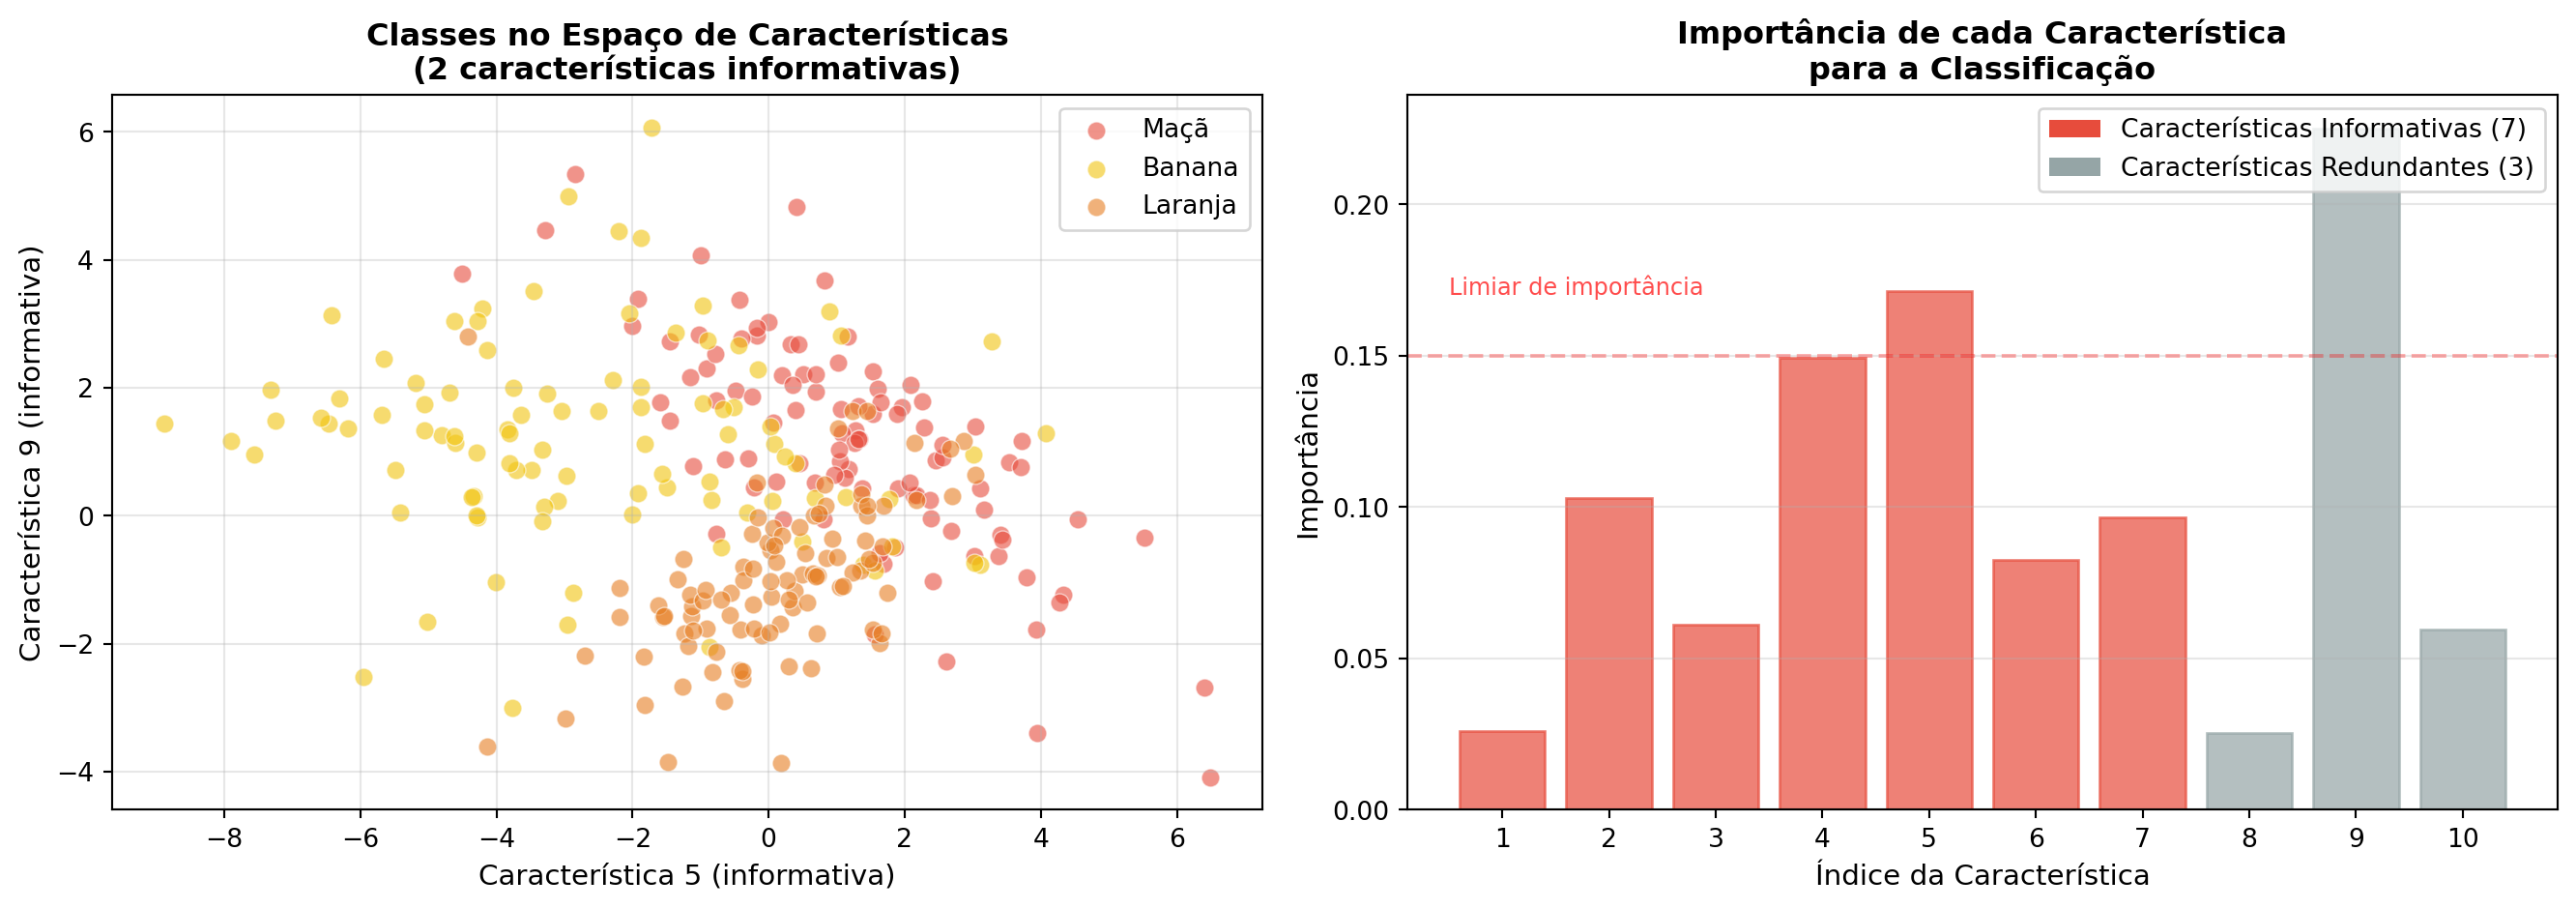

**Figura 7.10:** Ilustración del proceso de generación de datos sintéticos con *make_classification*. A la izquierda, visualización de las tres clases en un espacio bidimensional formado por dos características informativas. A la derecha, importancia relativa de cada característica para la clasificación, evidenciando que solo 7 de las 10 características son efectivamente discriminativas, mientras que las demás son redundantes (2) o repetidas (1).



🔍 Análisis de los datos generados:
  • Total de muestras: 300
  • Número de características: 10
  • Características informativas: 7 (columnas 1 a 7 del gráfico)
  • Características redundantes: 2 (columnas 8 y 9)
  • Características repetidas: 1 (columna 10)
  • Distribución de las clases: [101  98 101]


In [9]:
# Configuración para reproducción
np.random.seed(42)

# Generación de datos sintéticos con características controladas
X, y = make_classification(
    n_samples=300,
    n_features=10,
    n_informative=7,
    n_redundant=2,
    n_repeated=1,        # Una característica es copia de otra
    n_classes=3,
    n_clusters_per_class=1,
    random_state=42,
)

# Crear figura con dos subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Visualización de las clases en 2D (usando dos características informativas)
# Identificar cuáles características son más informativas
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)
importancias = rf.feature_importances_
caracteristicas_informativas = np.argsort(importancias)[-2:]  # Dos más importantes

cores = {0: "#e74c3c", 1: "#f1c40f", 2: "#e67e22"}  # Manzana, Banana, Naranja
rotulos = {0: "Maçã", 1: "Banana", 2: "Laranja"}

for classe in range(3):
    idx = y == classe
    ax1.scatter(X[idx, caracteristicas_informativas[0]], 
               X[idx, caracteristicas_informativas[1]],
               c=cores[classe], label=rotulos[classe], 
               alpha=0.6, s=50, edgecolors="white", linewidth=0.5)

ax1.set_xlabel(f"Característica {caracteristicas_informativas[0]+1} (informativa)", fontsize=11)
ax1.set_ylabel(f"Característica {caracteristicas_informativas[1]+1} (informativa)", fontsize=11)
ax1.set_title("Classes no Espaço de Características\n(2 características informativas)", 
             fontsize=12, fontweight="bold")
ax1.legend(loc="upper right")
ax1.grid(alpha=0.3)

# Subplot 2: Importancia de las características
bars = ax2.bar(range(1, 11), importancias, color="#4a90d9", alpha=0.7)
ax2.set_xlabel("Índice da Característica", fontsize=11)
ax2.set_ylabel("Importância", fontsize=11)
ax2.set_title("Importância de cada Característica\npara a Classificação", 
             fontsize=12, fontweight="bold")
ax2.set_xticks(range(1, 11))
ax2.grid(axis="y", alpha=0.3)

# Colorear barras para destacar características
cores_barras = ["#e74c3c" if i < 7 else "#95a5a6" for i in range(10)]
for bar, cor in zip(bars, cores_barras):
    bar.set_color(cor)

# Añadir leyenda
from matplotlib.patches import Patch
legenda_elements = [
    Patch(facecolor="#e74c3c", label="Características Informativas (7)"),
    Patch(facecolor="#95a5a6", label="Características Redundantes (3)")
]
ax2.legend(handles=legenda_elements, loc="upper right")

# Anotar el número de características informativas
ax2.axhline(y=0.15, color="red", linestyle="--", alpha=0.3)
ax2.text(0.5, 0.17, "Limiar de importância", fontsize=9, color="red", alpha=0.7)

plt.tight_layout()
plt.show()

print("\n🔍 Análisis de los datos generados:")
print(f"  • Total de muestras: {X.shape[0]}")
print(f"  • Número de características: {X.shape[1]}")
print(f"  • Características informativas: 7 (columnas 1 a 7 del gráfico)")
print(f"  • Características redundantes: 2 (columnas 8 y 9)")
print(f"  • Características repetidas: 1 (columna 10)")
print(f"  • Distribución de las clases: {np.bincount(y)}")

## 7.10 Clasificador k-NN: Cómo Funciona por Dentro

El **k-*Nearest Neighbors* (k-NN)** es uno de los algoritmos de clasificación más simples e intuitivos del Aprendizaje Automático. A diferencia de muchos clasificadores, no construye explícitamente un modelo durante la etapa de entrenamiento. En su lugar, almacena las muestras etiquetadas y, cuando una nueva muestra necesita ser clasificada, busca aquellas que más se le parecen.

El principio del algoritmo se basa en la hipótesis de que las muestras con características similares tienden a pertenecer a la misma clase. Para cuantificar esta proximidad, el k-NN utiliza una medida de distancia entre los vectores de características.

Como ejemplo, considere la [Tabela 7.2](#tbl-knn-frutas), que presenta una versión simplificada del problema de clasificación de frutas utilizando solo dos características: intensidad de color y circularidad, ambas normalizadas en el intervalo de 0 a 1.

<a id="tbl-knn-frutas"></a>

**Tabela 7.2:** Ejemplo simplificado de clasificación de frutas utilizando dos características normalizadas.

| Muestra          | Color | Circularidad | Clase  |
|------------------|------:|-------------:|--------|
| Fruta 1          | 0,82  | 0,88         | Manzana |
| Fruta 2          | 0,30  | 0,20         | Plátano |
| Fruta 3          | 0,88  | 0,85         | Manzana |
| Fruta ? (prueba) | 0,80  | 0,90         | ?      |


Observando solo estas dos características, se percibe que la fruta de prueba está mucho más cerca de las muestras etiquetadas como **Manzana** que de la muestra etiquetada como **Plátano**. En la siguiente sección, esta noción intuitiva de proximidad se formalizará mediante una métrica de distancia, utilizada por el algoritmo para identificar los vecinos más cercanos y decidir la clase de la nueva muestra.

### 7.10.1 Métrica de Distancia

La proximidad entre dos muestras se cuantifica normalmente mediante la
**distancia euclidiana**, definida por

$$
d(x,x_i)=\|x-x_i\|_2=
\sqrt{\sum_{j=1}^{n}(x_j-x_{i,j})^2},
$$

donde:

-   $x$ es la muestra de prueba;
-   $x_i$ es una muestra del conjunto de entrenamiento;
-   $n$ es el número de características;
-   $x_j$ y $x_{i,j}$ representan la $j$-ésima característica.

En la implementación de este capítulo, $x$ corresponde a una fila de `X_test`
y $x_i$ a una fila de `X_train`. El método `predict()` calcula
automáticamente la distancia entre $x$ y todas las muestras de
entrenamiento.

En el ejemplo de la [Tabela 7.2](#tbl-knn-frutas):

$$
d(\text{teste}, \text{Fruta 1}) \approx 0{,}028,\qquad
d(\text{teste}, \text{Fruta 2}) \approx 0{,}860,\qquad
d(\text{teste}, \text{Fruta 3}) \approx 0{,}094.
$$

Como las distancias más pequeñas corresponden a las Frutas 1 y 3, estas muestras
se utilizarán en la etapa de decisión.

### 7.10.2 Regla de Decisión

Tras ordenar las distancias, el algoritmo selecciona los $k$ vecinos más
cercanos. Sea $N_k(x)$ ese conjunto. La clase predicha está dada por

$$
\hat y=\operatorname{moda}\{\,y_i:x_i\in N_k(x)\,\},
$$

donde $y_i$ es la etiqueta de la muestra $x_i$ y $\hat y$ es la clase asignada
a la muestra de prueba.

En el ejemplo, para $k=3$, los vecinos son Fruta 1 (Manzana), Fruta 3 (Manzana) y
Fruta 2 (Banana). Como **Manzana** recibe dos votos, esa es la clase
predicha.

::: callout-tip
### Clase `KNeighborsClassifier`

En este capítulo, el algoritmo se implementa con la clase
`KNeighborsClassifier`, de la biblioteca `scikit-learn`:

``` python
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
```

donde:

-   `KNeighborsClassifier(n_neighbors=3)`: define el valor de $k$;
-   `fit(X_train, y_train)`: almacena las muestras de entrenamiento
    (`X_train`) y sus etiquetas (`y_train`);
-   `predict(X_test)`: devuelve las clases predichas para las muestras de
    `X_test`.

Internamente, `predict()` ejecuta los pasos descritos anteriormente:
calcula las distancias, identifica los $k$ vecinos más cercanos y
determina la clase por votación mayoritaria.
:::

La [Figura 7.11](#fig-07-knn-passo-passo) ilustra este procedimiento en un conjunto
bidimensional. La figura destaca los vecinos utilizados en la clasificación,
mientras que la consola presenta los pasos del algoritmo: cálculo de las
distancias, ordenamiento, selección de los vecinos, votación y predicción de la
clase.

1. Distancias calculadas: 30
2. Distancias ordenadas
3. 3 vecinos más cercanos:
   1.0850 → Classe A
   1.6379 → Classe B
   1.6382 → Classe A
4. Votos: {np.str_('Classe A'): 2, np.str_('Classe B'): 1}
5. Clase predicha: Classe A


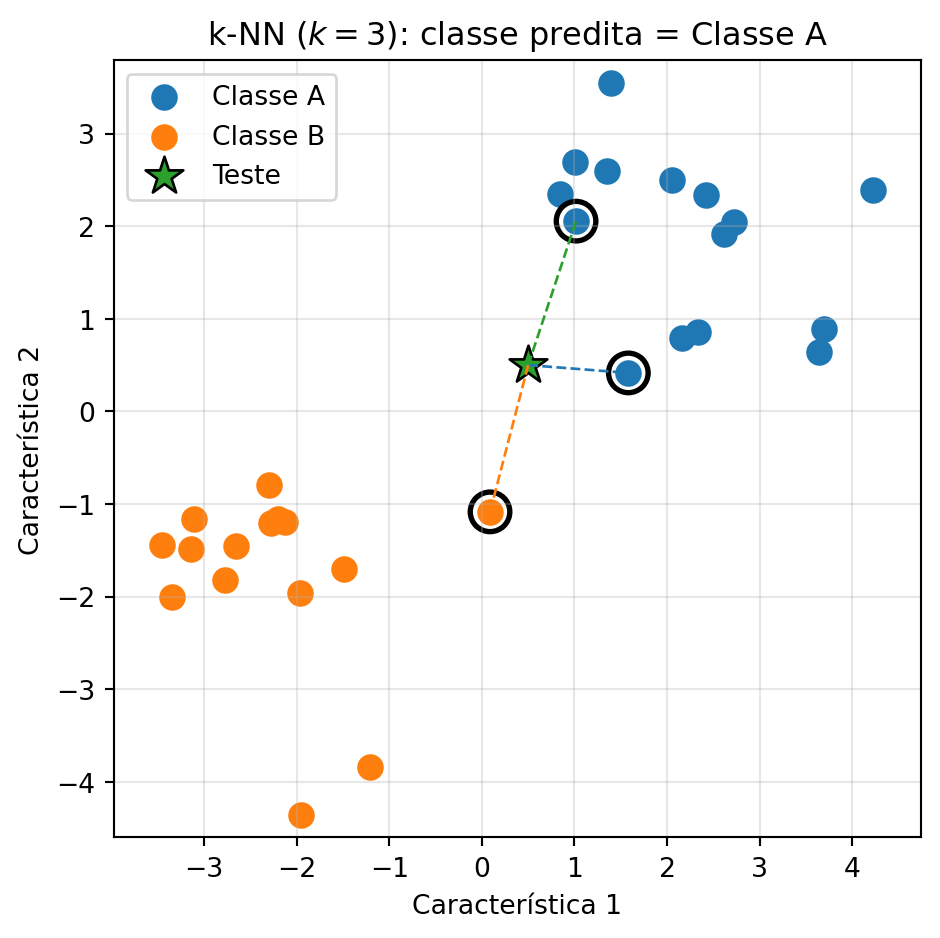

**Figura 7.11:** Clasificación de una nueva muestra por el algoritmo k-NN. El punto de prueba (estrella) se clasifica a partir de los tres vecinos más cercanos, resaltados por círculos.


In [10]:
def knn_passo_a_passo(X, y, x, k=3):
    """Ejecuta los cinco pasos del algoritmo k-NN.
    Parámetros: X (entrenamiento), y (etiquetas), x (prueba) y k (número de vecinos).
    """
    # 1. Distancias
    dist = [(np.linalg.norm(x-xi), yi, i) for i, (xi, yi) in enumerate(zip(X, y))]
    print(f"1. Distancias calculadas: {len(dist)}")

    # 2. Ordenación
    dist.sort(key=lambda t: t[0])
    print("2. Distancias ordenadas")

    # 3. Selección
    vizinhos = dist[:k]
    print(f"3. {k} vecinos más cercanos:")
    for d, c, _ in vizinhos:
        print(f"   {d:.4f} → {c}")

    # 4. Votación
    votos = {}
    for _, c, _ in vizinhos:
        votos[c] = votos.get(c, 0) + 1
    print("4. Votos:", votos)

    # 5. Decisión
    classe = max(votos, key=votos.get)
    print("5. Clase predicha:", classe)

    return classe, vizinhos


# Datos de ejemplo
np.random.seed(4)
X = np.r_[np.random.randn(15,2)+[2,2],
          np.random.randn(15,2)+[-2,-2]]
y = np.array(["Classe A"]*15 + ["Classe B"]*15)
x = np.array([0.5,0.5])

classe, vizinhos = knn_passo_a_passo(X, y, x)

# Visualización
plt.figure(figsize=(5,5))

for c, rotulo in [("Classe A","Classe A"), ("Classe B","Classe B")]:
    P = X[y==c]
    plt.scatter(P[:,0], P[:,1], s=80, label=rotulo)

plt.scatter(*x, marker="*", s=220, edgecolors="black", label="Teste")

for _, _, i in vizinhos:
    plt.scatter(*X[i], s=220, facecolors="none", edgecolors="black", linewidths=2)
    plt.plot([x[0], X[i,0]], [x[1], X[i,1]], "--", lw=1)

plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.title(f"k-NN ($k=3$): classe predita = {classe}")
plt.legend()
plt.grid(alpha=.3)
plt.axis("equal")
plt.tight_layout()
plt.show()

### 7.10.3 El Papel del Parámetro $k$

El parámetro $k$ determina cuántos vecinos participan en la decisión de clasificación.

- **Valores pequeños de $k$** (por ejemplo, $k=1$) hacen que el clasificador sea más sensible a ruidos y variaciones locales, produciendo fronteras de decisión más irregulares y favoreciendo el *sobreajuste*.
- **Valores mayores de $k$** producen fronteras de decisión más suaves, pero pueden reducir la sensibilidad a estructuras locales, favoreciendo el *subajuste*.

En problemas con dos clases, es común utilizar valores impares de $k$ para reducir la ocurrencia de empates.

Otro aspecto importante es la **maldición de la dimensionalidad** (*curse of dimensionality*). A medida que el número de características aumenta, las distancias entre las muestras tienden a volverse más similares, dificultando la identificación de vecinos realmente representativos.

::: callout-note
### Resumen

El algoritmo k-NN puede resumirse en tres etapas:

1. extraer el vector de características de la nueva muestra;
2. identificar los $k$ vecinos más cercanos;
3. clasificar la muestra por la clase más frecuente entre esos vecinos.

El simulador de la [Figura 7.12](#fig-07-sim-07-knn) permite explorar visualmente el efecto del parámetro $k$ sobre la frontera de decisión.
:::

In [11]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML("""
<div id="sim-07-knn" style="background-color:#fbf7ee;border-radius:18px;border:1px solid #e4dcc8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);position:relative;">

<style>
  #sim-07-knn * { box-sizing: border-box; margin: 0; padding: 0; }
  #sim-07-knn canvas { display: block; max-width: 100%; height: auto; border-radius: 8px; border: 1px solid #e4dcc8; background: #ffffff; cursor: crosshair; margin: 0 auto; }
  #sim-07-knn button { font-size: 11px; padding: 6px 12px; border-radius: 8px; border: 1px solid #e4dcc8; background: #f1ead7; color: #5e5a4a; cursor: pointer; transition: all 0.15s ease; font-weight: 600; display: inline-flex; align-items: center; justify-content: center; gap: 5px; }
  #sim-07-knn button:hover { background: #e8dfcf; }
  #sim-07-knn button.sim-07-knn_active { background: #26241d !important; border-color: #26241d !important; color: #7ee7c6 !important; }
  #sim-07-knn input[type=range] { width: 100%; accent-color: #26241d; cursor: pointer; height: 4px; }
  .sim-07-knn_pill { font-size: 10px; font-weight: 700; padding: 3px 10px; border-radius: 40px; border: 1px solid #e4dcc8; background: #26241d; color: #7ee7c6; font-family: monospace; }
  .sim-07-knn_panel { background: #fafaf7; border: 1px solid #e9e3d3; border-radius: 12px; padding: 12px; }
  .sim-07-knn_grid_stats { display: grid; grid-template-columns: repeat(3, 1fr); gap: 10px; margin-bottom: 12px; }
  .sim-07-knn_stat_box { background: #fafaf7; border: 1px solid #e9e3d3; border-radius: 10px; padding: 10px; text-align: center; }
  .sim-07-knn_stat_label { font-size: 9.5px; color: #8a8371; text-transform: uppercase; letter-spacing: 0.04em; margin-bottom: 2px; font-weight: 700; }
  .sim-07-knn_stat_value { font-size: 16px; font-weight: 700; font-family: monospace; color: #26241d; }
  .sim-07-knn_legend { display: flex; align-items: center; gap: 6px; font-size: 11px; font-weight: 600; color: #5e5a4a; }
  .sim-07-knn_dot { width: 10px; height: 10px; border-radius: 50%; display: inline-block; border: 1px solid rgba(38,36,29,0.2); }
</style>

<!-- Cabeçalho -->
<div style="background:#f1ead7;padding:8px 16px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #e4dcc8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
  <span style="font-weight:600;color:#26241d;">📌 Simulador: Frontera de Decisión del k-NN</span>
  <span class="sim-07-knn_pill">Haz clic en el lienzo para añadir puntos</span>
</div>

<div style="padding:16px;background:#ffffff;">

  <!-- Painel de Controles e Estatísticas -->
  <div class="sim-07-knn_panel" style="margin-bottom:14px;">
    
    <div class="sim-07-knn_grid_stats">
      <div class="sim-07-knn_stat_box">
        <div class="sim-07-knn_stat_label">Vecinos (k)</div>
        <div id="sim-07-knn_kVal" class="sim-07-knn_stat_value" style="color:#2980b9;">3</div>
      </div>
      <div class="sim-07-knn_stat_box">
        <div class="sim-07-knn_stat_label">Clase Azul</div>
        <div id="sim-07-knn_nAzul" class="sim-07-knn_stat_value" style="color:#2980b9;">0</div>
      </div>
      <div class="sim-07-knn_stat_box">
        <div class="sim-07-knn_stat_label">Clase Roja</div>
        <div id="sim-07-knn_nVerm" class="sim-07-knn_stat_value" style="color:#c0392b;">0</div>
      </div>
    </div>

    <!-- Botões de Ação -->
    <div style="display:flex; gap:6px; flex-wrap:wrap; margin-bottom:12px; justify-content:center;">
      <button id="sim-07-knn_btnAzul" class="sim-07-knn_active">🔵 Añadir Azul</button>
      <button id="sim-07-knn_btnVerm">🔴 Añadir Rojo</button>
      <button id="sim-07-knn_btnLimpar" style="border-color:#f5b7b1; color:#c0392b; background:#fdecea;">🗑️ Limpiar</button>
      <button id="sim-07-knn_btnReset">↺ Reiniciar</button>
    </div>

    <!-- Slider k -->
    <div style="display:flex; justify-content:space-between; align-items:center; margin-bottom:6px;">
      <label style="font-size:11px; font-weight:700; color:#5e5a4a;">
        Valor de k: <span id="sim-07-knn_slVal" style="font-family:monospace; color:#26241d;">3</span>
      </label>
    </div>
    <input type="range" id="sim-07-knn_slider" min="1" max="15" step="1" value="3">

  </div>

  <!-- Canvas -->
  <div style="margin-bottom:14px; text-align:center;">
    <canvas id="sim-07-knn_canvas" width="640" height="360"></canvas>
  </div>

  <!-- Legenda e Rodapé -->
  <div class="sim-07-knn_panel">
    <div style="display:flex; justify-content:space-between; align-items:center; flex-wrap:wrap; gap:10px;">
      <div style="display:flex; gap:16px;">
        <div class="sim-07-knn_legend"><span class="sim-07-knn_dot" style="background:#2980b9;"></span> Clase Azul</div>
        <div class="sim-07-knn_legend"><span class="sim-07-knn_dot" style="background:#c0392b;"></span> Clase Roja</div>
      </div>
      <div style="font-size:10.5px; color:#8a8371; font-weight:600;">
        La región coloreada de fondo representa la clase asignada por el algoritmo a cada punto del espacio.
      </div>
    </div>
  </div>

</div>
</div>

<script>
(function(){
  function initSim07Knn(root){
    if (!root || root.dataset.sim07KnnInit) return;
    root.dataset.sim07KnnInit = "1";

    const canvas = root.querySelector("#sim-07-knn_canvas");
    const ctx = canvas.getContext("2d");
    const W = canvas.width, H = canvas.height;
    const CELL = 10;

    let currentLabel = 0; // 0 = azul, 1 = vermelho
    let kVal = 3;
    let points = [];

    function defaultPoints(){
      return [
        {x:120,y:260,l:0},{x:150,y:230,l:0},{x:100,y:200,l:0},{x:160,y:290,l:0},
        {x:90,y:250,l:0},{x:140,y:190,l:0},{x:175,y:250,l:0},{x:110,y:150,l:0},
        {x:200,y:230,l:0},{x:130,y:310,l:0},
        {x:480,y:100,l:1},{x:450,y:130,l:1},{x:500,y:160,l:1},{x:440,y:80,l:1},
        {x:510,y:110,l:1},{x:470,y:60,l:1},{x:430,y:150,l:1},{x:520,y:190,l:1},
        {x:490,y:220,l:1},{x:460,y:190,l:1},
        {x:300,y:170,l:0},{x:320,y:190,l:1},{x:280,y:200,l:1},{x:310,y:150,l:0}
      ];
    }

    function classify(x, y, k, pontos){
      if (pontos.length === 0) return null;
      const dists = pontos.map(p => ({
        d: (p.x - x) * (p.x - x) + (p.y - y) * (p.y - y),
        l: p.l
      }));
      dists.sort((a, b) => a.d - b.d);
      const vizinhos = dists.slice(0, Math.min(k, dists.length));
      let votos = [0, 0];
      vizinhos.forEach(v => votos[v.l]++);
      return votos[1] > votos[0] ? 1 : 0;
    }

    function render(){
      ctx.clearRect(0, 0, W, H);

      // Região de decisão em grade
      for (let gy = 0; gy < H; gy += CELL){
        for (let gx = 0; gx < W; gx += CELL){
          const cx = gx + CELL / 2, cy = gy + CELL / 2;
          const classe = points.length > 0 ? classify(cx, cy, kVal, points) : null;
          if (classe === 0) ctx.fillStyle = "rgba(41, 128, 185, 0.15)";
          else if (classe === 1) ctx.fillStyle = "rgba(192, 57, 43, 0.15)";
          else ctx.fillStyle = "#fafaf7";
          ctx.fillRect(gx, gy, CELL, CELL);
        }
      }

      // Desenhar pontos de treinamento
      points.forEach(p => {
        ctx.beginPath();
        ctx.arc(p.x, p.y, 6.5, 0, 2 * Math.PI);
        ctx.fillStyle = p.l === 0 ? "#2980b9" : "#c0392b";
        ctx.fill();
        ctx.lineWidth = 1.5;
        ctx.strokeStyle = "#ffffff";
        ctx.stroke();
      });

      root.querySelector("#sim-07-knn_nAzul").textContent = points.filter(p => p.l === 0).length;
      root.querySelector("#sim-07-knn_nVerm").textContent = points.filter(p => p.l === 1).length;
      root.querySelector("#sim-07-knn_kVal").textContent = kVal;
    }

    canvas.addEventListener("click", function(ev){
      const rect = canvas.getBoundingClientRect();
      const scaleX = canvas.width / rect.width;
      const scaleY = canvas.height / rect.height;
      const x = (ev.clientX - rect.left) * scaleX;
      const y = (ev.clientY - rect.top) * scaleY;
      points.push({x: x, y: y, l: currentLabel});
      render();
    });

    root.querySelector("#sim-07-knn_slider").addEventListener("input", function(ev){
      kVal = parseInt(ev.target.value, 10);
      root.querySelector("#sim-07-knn_slVal").textContent = kVal;
      render();
    });

    const btnAzul = root.querySelector("#sim-07-knn_btnAzul");
    const btnVerm = root.querySelector("#sim-07-knn_btnVerm");

    function setLabel(l){
      currentLabel = l;
      btnAzul.classList.toggle("sim-07-knn_active", l === 0);
      btnVerm.classList.toggle("sim-07-knn_active", l === 1);
    }

    btnAzul.addEventListener("click", function(){ setLabel(0); });
    btnVerm.addEventListener("click", function(){ setLabel(1); });

    root.querySelector("#sim-07-knn_btnLimpar").addEventListener("click", function(){
      points = [];
      render();
    });

    root.querySelector("#sim-07-knn_btnReset").addEventListener("click", function(){
      points = defaultPoints();
      render();
    });

    setLabel(0);
    points = defaultPoints();
    render();
  }

  function tryInitSim07Knn(){
    var root = document.getElementById("sim-07-knn");
    if (root) initSim07Knn(root); else setTimeout(tryInitSim07Knn, 200);
  }
  tryInitSim07Knn();
})();
</script>
</div>
""")

**Figura 7.12:** Simulador interactivo de la frontera de decisión del k-NN: añada puntos de entrenamiento y ajuste el valor de k para observar el efecto sobre la región de decisión.


## 7.11 Proyecto Práctico 1: Clasificación de Dígitos Manuscritos con k-NN

Las secciones anteriores presentaron el algoritmo k-NN mediante un ejemplo simplificado de clasificación de frutas, utilizando únicamente dos características. A continuación, el mismo algoritmo se aplica a un conjunto de datos de imágenes, en el cual cada muestra está representada por un vector de mayor dimensión.

Como estudio de caso, se utiliza la base pública `load_digits`, disponible en la biblioteca `scikit-learn`. Este conjunto de datos contiene 1797 imágenes de dígitos manuscritos de las clases de 0 a 9, cada una con una resolución de $8 \times 8$ píxeles en niveles de gris. Cada imagen está representada por un vector con 64 características, correspondientes a las intensidades de los píxeles, y cada vector posee una etiqueta que indica el dígito correspondiente.

La base `load_digits` está disponible en la biblioteca `scikit-learn` y se utiliza en este capítulo para ilustrar la aplicación del algoritmo k-NN. Además de estar disponible directamente en `scikit-learn`, evita etapas adicionales de obtención y preparación de los datos, permitiendo concentrar la atención en la implementación y la evaluación del clasificador.

La [Figura 7.13](#fig-07-digits-amostra) presenta una muestra de las imágenes de la base de datos.

Total de muestras: 1797, dimensión del vector: 64
Clases: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


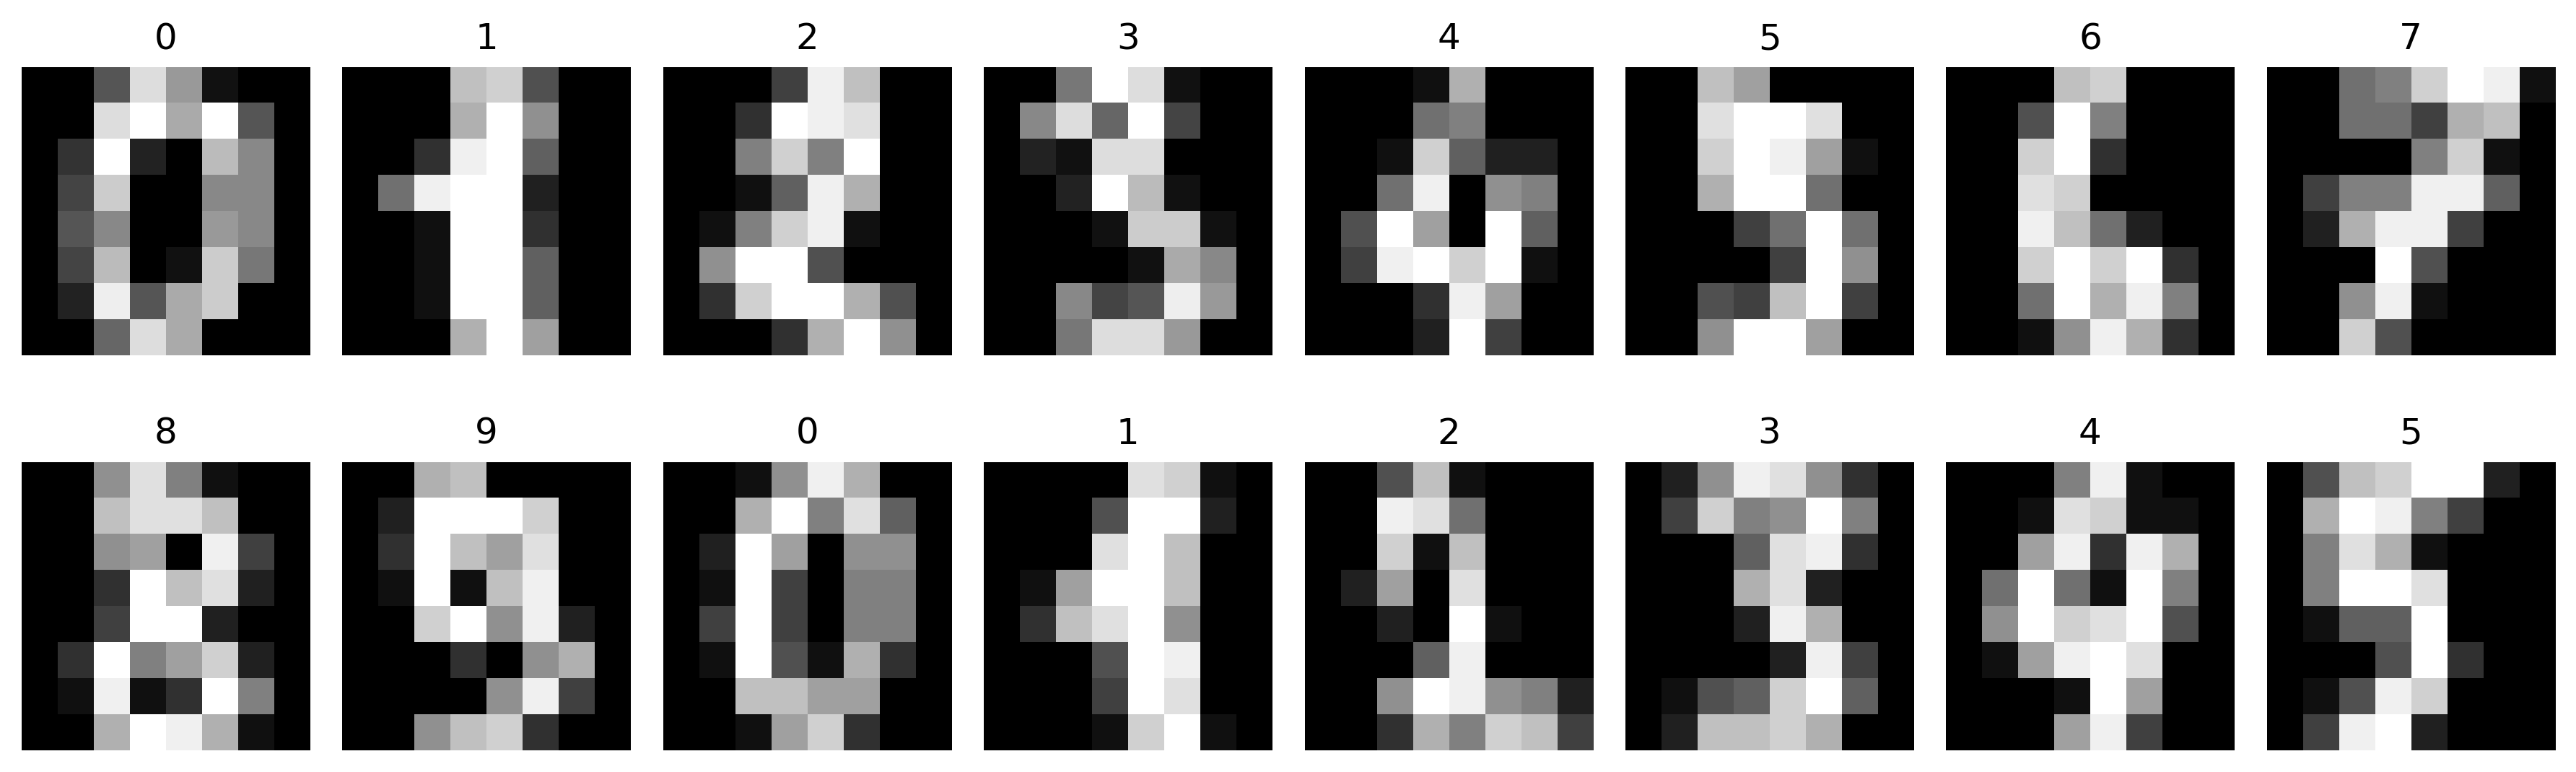

**Figura 7.13:** Muestra de dígitos manuscritos de la base *load_digits*, utilizada como caso de estudio de clasificación.


In [12]:
digits = load_digits()
print(f"Total de muestras: {digits.data.shape[0]}, dimensión del vector: {digits.data.shape[1]}")
print(f"Clases: {[int(i) for i in sorted(set(digits.target))]}")

n_amostras = 16
imgs = list(digits.images[:n_amostras])
imgs_titles = [str(label) for label in digits.target[:n_amostras]]
mm.show(imgs, titles=imgs_titles, cols=8, figsize=(12, 4))


### 7.11.1 Clasificación con Vectores de Intensidad

En este primer experimento, cada imagen de dimensión $8 \times 8$ se representa directamente mediante las intensidades de sus 64 píxeles, sin la extracción de descriptores adicionales. Así, cada muestra corresponde a un vector de 64 características, utilizado como entrada del clasificador k-NN.

A continuación, el conjunto de datos se divide en subconjuntos de entrenamiento y prueba, preservando la proporción de las diez clases mediante el parámetro `stratify=y`. El clasificador se entrena con $k=3$ y se evalúa sobre el conjunto de prueba utilizando la exactitud y la matriz de confusión presentada en la [Figura 7.14](#fig-07-knn-pixels)..

Precisión (vectores de intensidad, k=3): 0.9870


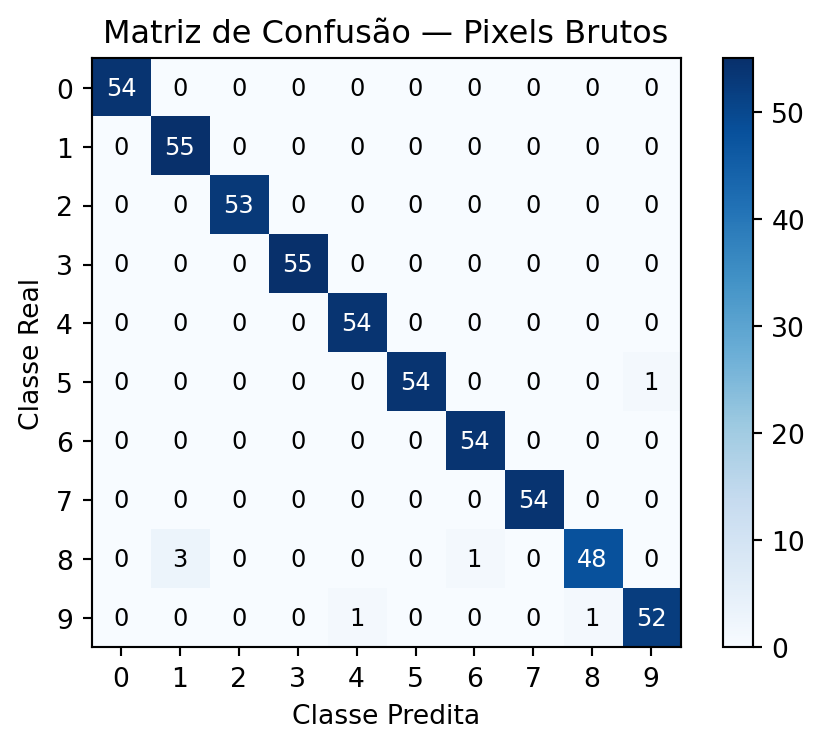

**Figura 7.14:** Matriz de confusión del clasificador k-NN entrenado con vectores de intensidad brutos (píxeles).


In [13]:
X, y = digits.data, digits.target

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

n_neighbors = 3
knn_pixels = KNeighborsClassifier(n_neighbors=n_neighbors)
knn_pixels.fit(X_treino, y_treino)
pred_pixels = knn_pixels.predict(X_teste)

acc_pixels = accuracy_score(y_teste, pred_pixels)
print(f"Precisión (vectores de intensidad, k={n_neighbors}): {acc_pixels:.4f}")

cm = confusion_matrix(y_teste, pred_pixels)

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, cm[i, j],
            ha="center", va="center",
            color="white" if cm[i, j] > cm.max()/2 else "black",
            fontsize=9
        )

plt.title("Matriz de Confusão — Pixels Brutos")
plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")
plt.xticks(range(10))
plt.yticks(range(10))
plt.colorbar(fraction=0.046)
plt.tight_layout()
plt.show()


### 7.11.2 Clasificación con Descriptores HOG

En el experimento anterior, cada imagen fue representada directamente por las intensidades de sus píxeles. En esta sección, esa representación se sustituye por descriptores HOG (*Histogram of Oriented Gradients*), que codifican información sobre la distribución de las orientaciones de los gradientes de la imagen.

Se mantienen la misma partición de los datos, el mismo clasificador k-NN y el mismo protocolo de evaluación, cambiando únicamente la representación de las imágenes. La [Figura 7.15](#fig-07-comparativo-descritores) compara los resultados obtenidos con vectores de intensidad y con descriptores HOG.

Dimensión del vector HOG: 32
Precisión (descriptor HOG, k=3): 0.7593


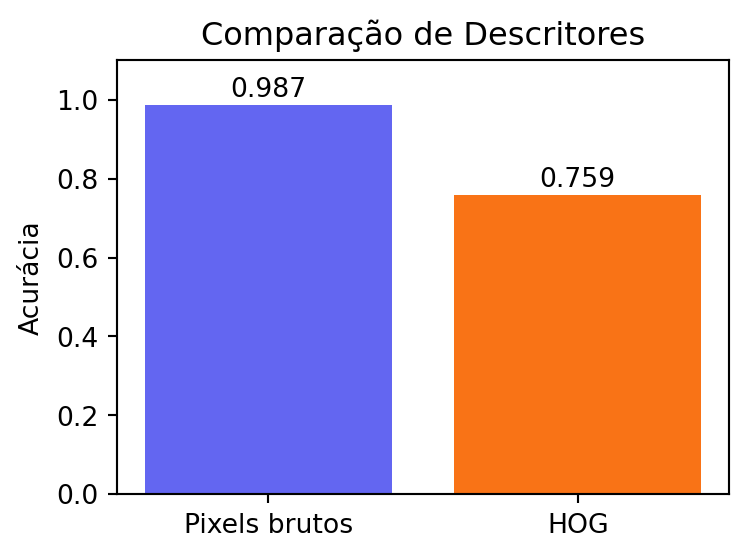

**Figura 7.15:** Comparación de precisión entre descriptores de píxeles brutos y HOG para el clasificador k-NN (k=3) en la base de dígitos.


In [14]:
descritores_hog = np.array([
    hog(img, orientations=8, pixels_per_cell=(4, 4), cells_per_block=(1, 1))
    for img in digits.images
])
print(f"Dimensión del vector HOG: {descritores_hog.shape[1]}")

Xh_treino, Xh_teste, yh_treino, yh_teste = train_test_split(
    descritores_hog, y, test_size=0.3, random_state=42, stratify=y
)

n_neighbors = 3
knn_hog = KNeighborsClassifier(n_neighbors=n_neighbors)
knn_hog.fit(Xh_treino, yh_treino)
pred_hog = knn_hog.predict(Xh_teste)
acc_hog = accuracy_score(yh_teste, pred_hog)
print(f"Precisión (descriptor HOG, k={n_neighbors}): {acc_hog:.4f}")

plt.figure(figsize=(4, 3))
plt.bar(["Pixels brutos", "HOG"], [acc_pixels, acc_hog], color=["#6366f1", "#f97316"])
plt.ylim(0, 1.1)  # Aumenta el límite superior para dar espacio
plt.ylabel("Acurácia")
plt.title("Comparação de Descritores")
for i, v in enumerate([acc_pixels, acc_hog]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center")  # Aumenta el desplazamiento vertical
plt.tight_layout()

> ### 📝 ¿Por qué sucede esto?
>
> En [Figura 7.15](#fig-07-comparativo-descritores), el clasificador entrenado con vectores de **intensidad de los píxeles** alcanza una mayor exactitud ($0.987$) que aquel basado en descriptores **HOG** ($0.759$). Este resultado está relacionado con las características de la base `load_digits`.
>
> Las imágenes poseen una resolución de solo $8\times8$ píxeles, se encuentran aproximadamente centradas y presentan poca variación de iluminación, escala y orientación. En este escenario, las intensidades de los píxeles preservan prácticamente toda la información necesaria para distinguir las clases. En contraste, el HOG resume la imagen en histogramas de orientaciones de los gradientes, reduciendo parte del detalle espacial disponible en los píxeles originales.
>
> Esta reducción de información puede dificultar la separación de dígitos visualmente similares, como 3 y 8 o 4 y 9, especialmente cuando la resolución de la imagen es baja.
>
> En problemas con imágenes de mayor resolución o sujetas a variaciones de iluminación, posición, escala o pequeñas deformaciones, descriptores como el HOG tienden a representar mejor la estructura local de la imagen que los valores individuales de los píxeles. Así, este experimento ilustra un principio importante del Aprendizaje Automático: **la representación de los datos debe elegirse de acuerdo con las características del problema y no por la complejidad del descriptor.**

## 7.12 Evaluación de Clasificadores

En las secciones anteriores, la calidad del clasificador fue analizada
mediante la exactitud y la matriz de confusión. En esta sección, estas herramientas
se complementan con métricas utilizadas en la evaluación de modelos y con
un procedimiento para seleccionar el valor del parámetro $k$.

La exactitud corresponde a la proporción de muestras clasificadas
correctamente. Aunque es una medida simple y ampliamente utilizada, puede
ser insuficiente cuando las clases presentan distribuciones muy
desbalanceadas.

A partir de la matriz de confusión — introducida en el **Capítulo 1** y
utilizada a lo largo de este capítulo — se pueden calcular métricas por
clase, como precisión y exhaustividad:

$$
\text{Precisión}=\frac{VP}{VP+FP},
\qquad
\text{Exhaustividad}=\frac{VP}{VP+FN},
$$

donde $VP$, $FP$ y $FN$ representan, respectivamente, el número de
verdaderos positivos, falsos positivos y falsos negativos de la clase
analizada. La precisión cuantifica la proporción de predicciones positivas
correctas, mientras que la exhaustividad mide la capacidad del clasificador de
identificar los ejemplos pertenecientes a la clase.

### 7.12.1 Elección de $k$ por Validación Cruzada

En los experimentos anteriores, se adoptó $k=3$ para ilustrar el funcionamiento del algoritmo. Sin embargo, este parámetro influye directamente en el desempeño del clasificador y, en la práctica, debe seleccionarse a partir de los datos.

Un enfoque ampliamente utilizado es la **validación cruzada** (*cross-validation*), en la cual el conjunto de entrenamiento se divide en particiones sucesivas para estimar el desempeño del modelo en datos no utilizados durante el entrenamiento.

El siguiente código calcula la precisión media obtenida por validación cruzada de cinco particiones (*5-fold cross-validation*) para diferentes valores de $k$. La [Figura 7.16](#fig-07-elbow-k) presenta los resultados, permitiendo identificar la región en la que el clasificador alcanza un mejor desempeño.

Mejor valor de k encontrado: 2 (precisión media=0.9672)


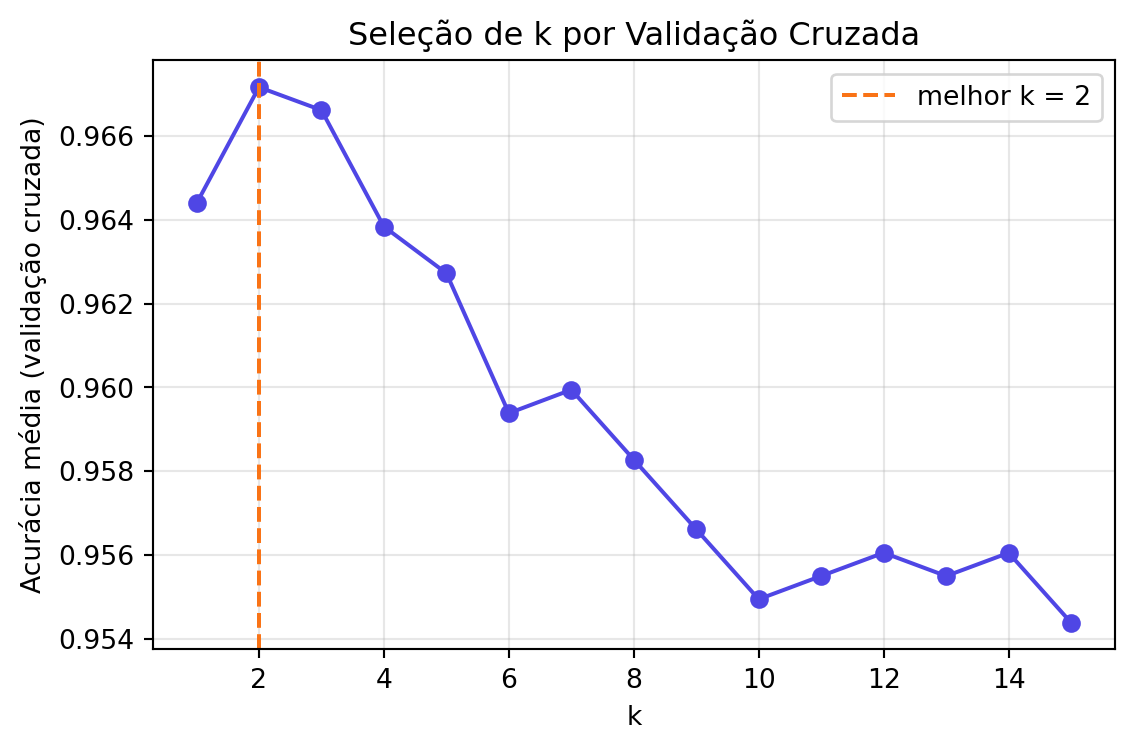

**Figura 7.16:** Precisión media por validación cruzada (5 particiones) en función del parámetro k, para la base de dígitos con vectores de intensidad brutos.


In [15]:
valores_k = range(1, 16)
acuracias_medias = []

for k in valores_k:
    modelo = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(modelo, X, y, cv=5)
    acuracias_medias.append(scores.mean())

melhor_k = list(valores_k)[int(np.argmax(acuracias_medias))]
print(f"Mejor valor de k encontrado: {melhor_k} (precisión media={max(acuracias_medias):.4f})")

plt.figure(figsize=(6, 4))
plt.plot(list(valores_k), acuracias_medias, marker="o", color="#4f46e5")
plt.axvline(melhor_k, color="#f97316", linestyle="--", label=f"melhor k = {melhor_k}")
plt.xlabel("k")
plt.ylabel("Acurácia média (validação cruzada)")
plt.title("Seleção de k por Validação Cruzada")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

### 7.12.2 El Compromiso entre Sesgo y Varianza: Diagnóstico de *Overfitting* y *Underfitting*

El hiperparámetro $k$ influye en la complejidad de la frontera de decisión del clasificador k-NN y, en consecuencia, en su capacidad de generalización. En términos generales, valores pequeños de $k$ hacen que el modelo sea más sensible a las muestras de entrenamiento, mientras que valores mayores producen fronteras de decisión más suaves.

Estos comportamientos están asociados con el compromiso entre **sesgo** (*bias*) y **varianza** (*variance*). Valores muy pequeños de $k$ tienden a aumentar el riesgo de **sobreajuste** (*overfitting*), especialmente en conjuntos de datos ruidosos, mientras que valores muy grandes pueden llevar al **subajuste** (*underfitting*), reduciendo la capacidad del modelo para capturar estructuras locales de los datos.

Mientras que la [Figura 7.16](#fig-07-elbow-k) presentó solo la precisión media obtenida mediante validación cruzada, la [Figura 7.17](#fig-07-overfitting-analysis) compara las precisiones de entrenamiento y de prueba para diferentes valores de $k$. Las regiones resaltadas en el gráfico representan el comportamiento esperado del algoritmo: mayor riesgo de sobreajuste para valores pequeños de $k$, una región intermedia que frecuentemente produce un buen equilibrio entre sesgo y varianza, y un mayor riesgo de subajuste para valores elevados de $k$.

Sin embargo, estas regiones deben interpretarse solo como una referencia conceptual. El comportamiento observado depende de las características del conjunto de datos. En la base `load_digits`, por ejemplo, las imágenes presentan poca variabilidad y una buena separación entre las clases, de modo que valores pequeños de $k$ pueden presentar un rendimiento similar —o incluso superior— a los demás, sin evidenciar un sobreajuste significativo.

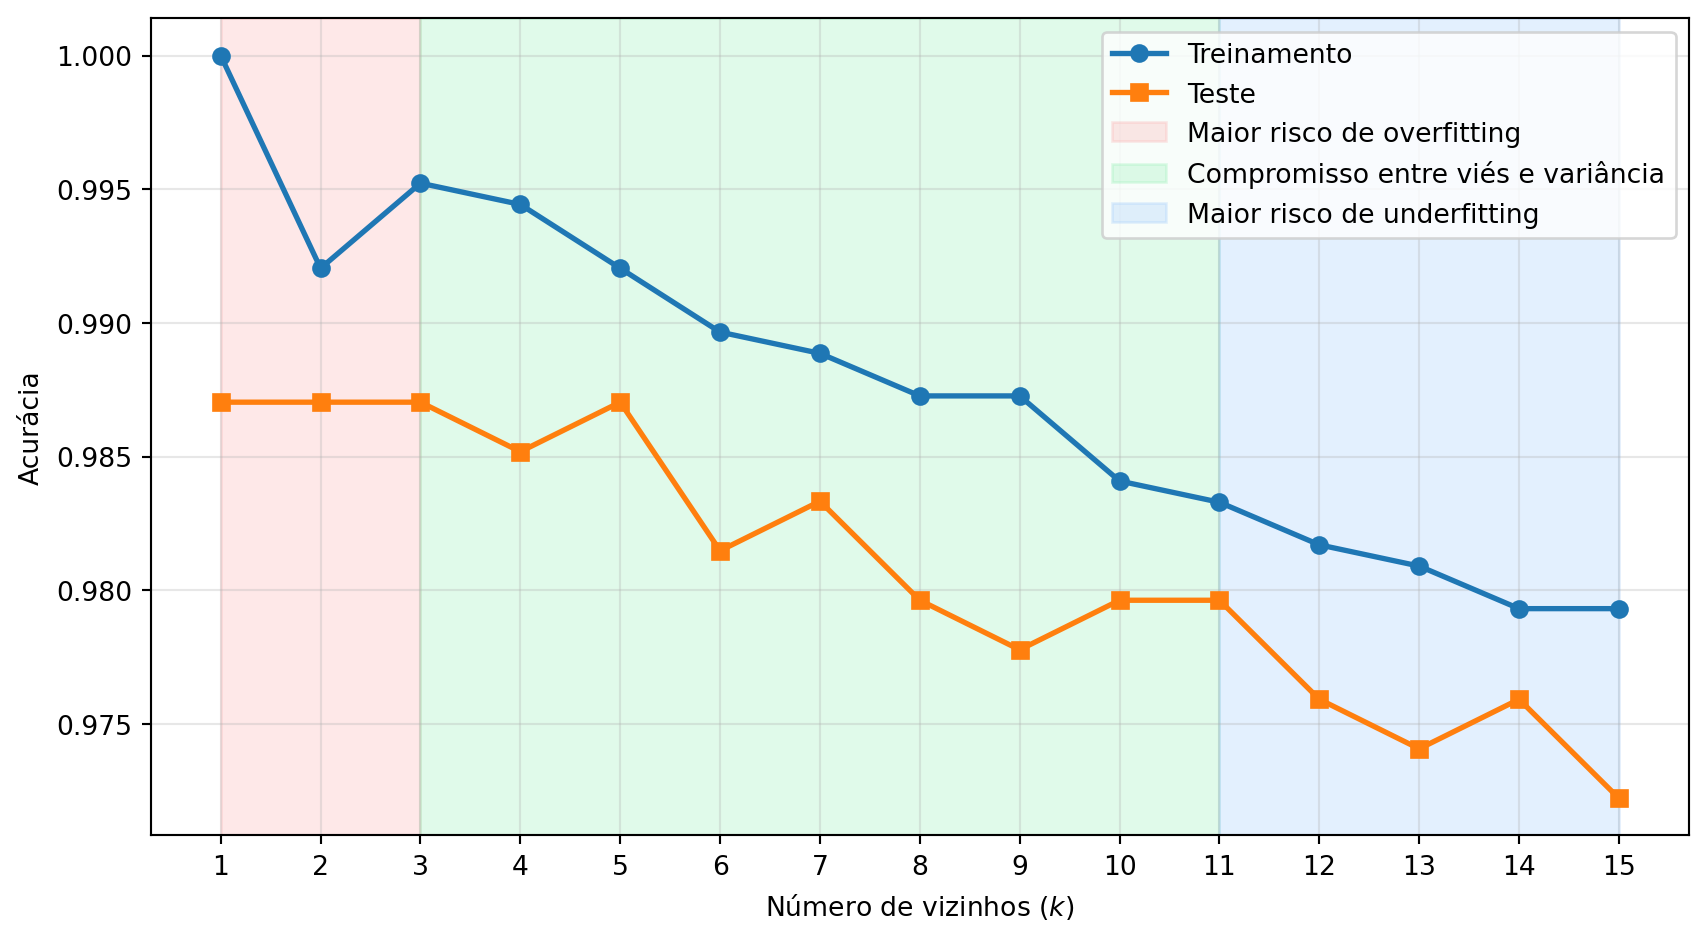

**Figura 7.17:** Precisión en los conjuntos de entrenamiento y prueba para diferentes valores de $k$. Las regiones coloreadas representan, de forma conceptual, tendencias de comportamiento del clasificador: mayor riesgo de sobreajuste (rojo), compromiso entre sesgo y varianza (verde) y mayor riesgo de subajuste (azul).


Interpretación
- Valores pequeños de k: mayor riesgo de overfitting.
- Valores intermedios: mejor compromiso entre sesgo y varianza.
- Valores grandes de k: mayor riesgo de underfitting.

Las regiones coloreadas representan tendencias generales;
el comportamiento observado depende del conjunto de datos.

Mayor precisión en la prueba: 0.987
Valores de k que alcanzaron esa precisión: [1, 2, 3, 5]


In [16]:
k_values = range(1, 16)
train_acc, test_acc = [], []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k).fit(X_treino, y_treino)
    train_acc.append(accuracy_score(y_treino, knn.predict(X_treino)))
    test_acc.append(accuracy_score(y_teste, knn.predict(X_teste)))

plt.figure(figsize=(9,5))
plt.plot(k_values, train_acc, "o-", lw=2, label="Treinamento")
plt.plot(k_values, test_acc,  "s-", lw=2, label="Teste")

plt.axvspan(1, 3,  color="#fca5a5", alpha=.25, label="Maior risco de overfitting")
plt.axvspan(3,11,  color="#86efac", alpha=.25, label="Compromisso entre viés e variância")
plt.axvspan(11,15, color="#93c5fd", alpha=.25, label="Maior risco de underfitting")

plt.xlabel("Número de vizinhos ($k$)")
plt.ylabel("Acurácia")
plt.xticks(k_values)
plt.grid(alpha=.3)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

maior_acc = max(test_acc)
melhores_k = [k for k, a in zip(k_values, test_acc) if np.isclose(a, maior_acc)]

print("Interpretación")
print("- Valores pequeños de k: mayor riesgo de overfitting.")
print("- Valores intermedios: mejor compromiso entre sesgo y varianza.")
print("- Valores grandes de k: mayor riesgo de underfitting.")
print("\nLas regiones coloreadas representan tendencias generales;")
print("el comportamiento observado depende del conjunto de datos.")
print(f"\nMayor precisión en la prueba: {maior_acc:.3f}")
print(f"Valores de k que alcanzaron esa precisión: {melhores_k}")

## 7.13 Proyecto Práctico 2: Comparación de Descriptores para Clasificación de Texturas

En el **Capítulo 6**, la varianza local se utilizó como descriptor de textura para **detectar** anomalías en superficies industriales, distinguiendo muestras **conformes** y **defectuosas**. En este proyecto, el problema se reformula como una tarea de **clasificación multiclase**, en la cual diferentes representaciones de la imagen se utilizan como entrada para un clasificador.

Se considerarán tres tipos de descriptores: las **intensidades de los píxeles**, el **Local Binary Patterns (LBP)** y el **Histogram of Oriented Gradients (HOG)**. Para cada representación, se extraerá un vector de características que servirá de entrada para el algoritmo de los $k$ vecinos más cercanos ($k$-NN). Al final, se compararán las precisiones obtenidas por cada descriptor en las condiciones definidas para este experimento.

La evaluación se realizará mediante **validación cruzada estratificada en cinco particiones (*5-fold stratified cross-validation*)**. En este procedimiento, el conjunto de datos se divide en cinco subconjuntos preservando la proporción entre las clases. En cada iteración, una partición se utiliza para prueba y las cuatro restantes para entrenamiento, repitiéndose el proceso hasta que todas las particiones hayan sido utilizadas como conjunto de prueba. Al término de las cinco ejecuciones, se calculan la precisión media y la desviación estándar para cada descriptor.

El conjunto de datos está compuesto por tres clases de texturas sintéticas: **granular**, obtenida a partir de ruido gaussiano suavizado; **listada**, formada por patrones sinusoidales periódicos; y **manchada**, compuesta por regiones circulares superpuestas. Para introducir variabilidad entre las muestras, todas las imágenes reciben una perturbación por ruido gaussiano de baja intensidad. La [Figura 7.18](#fig-07-texturas-amostra) presenta ejemplos de las tres clases utilizadas en el experimento.

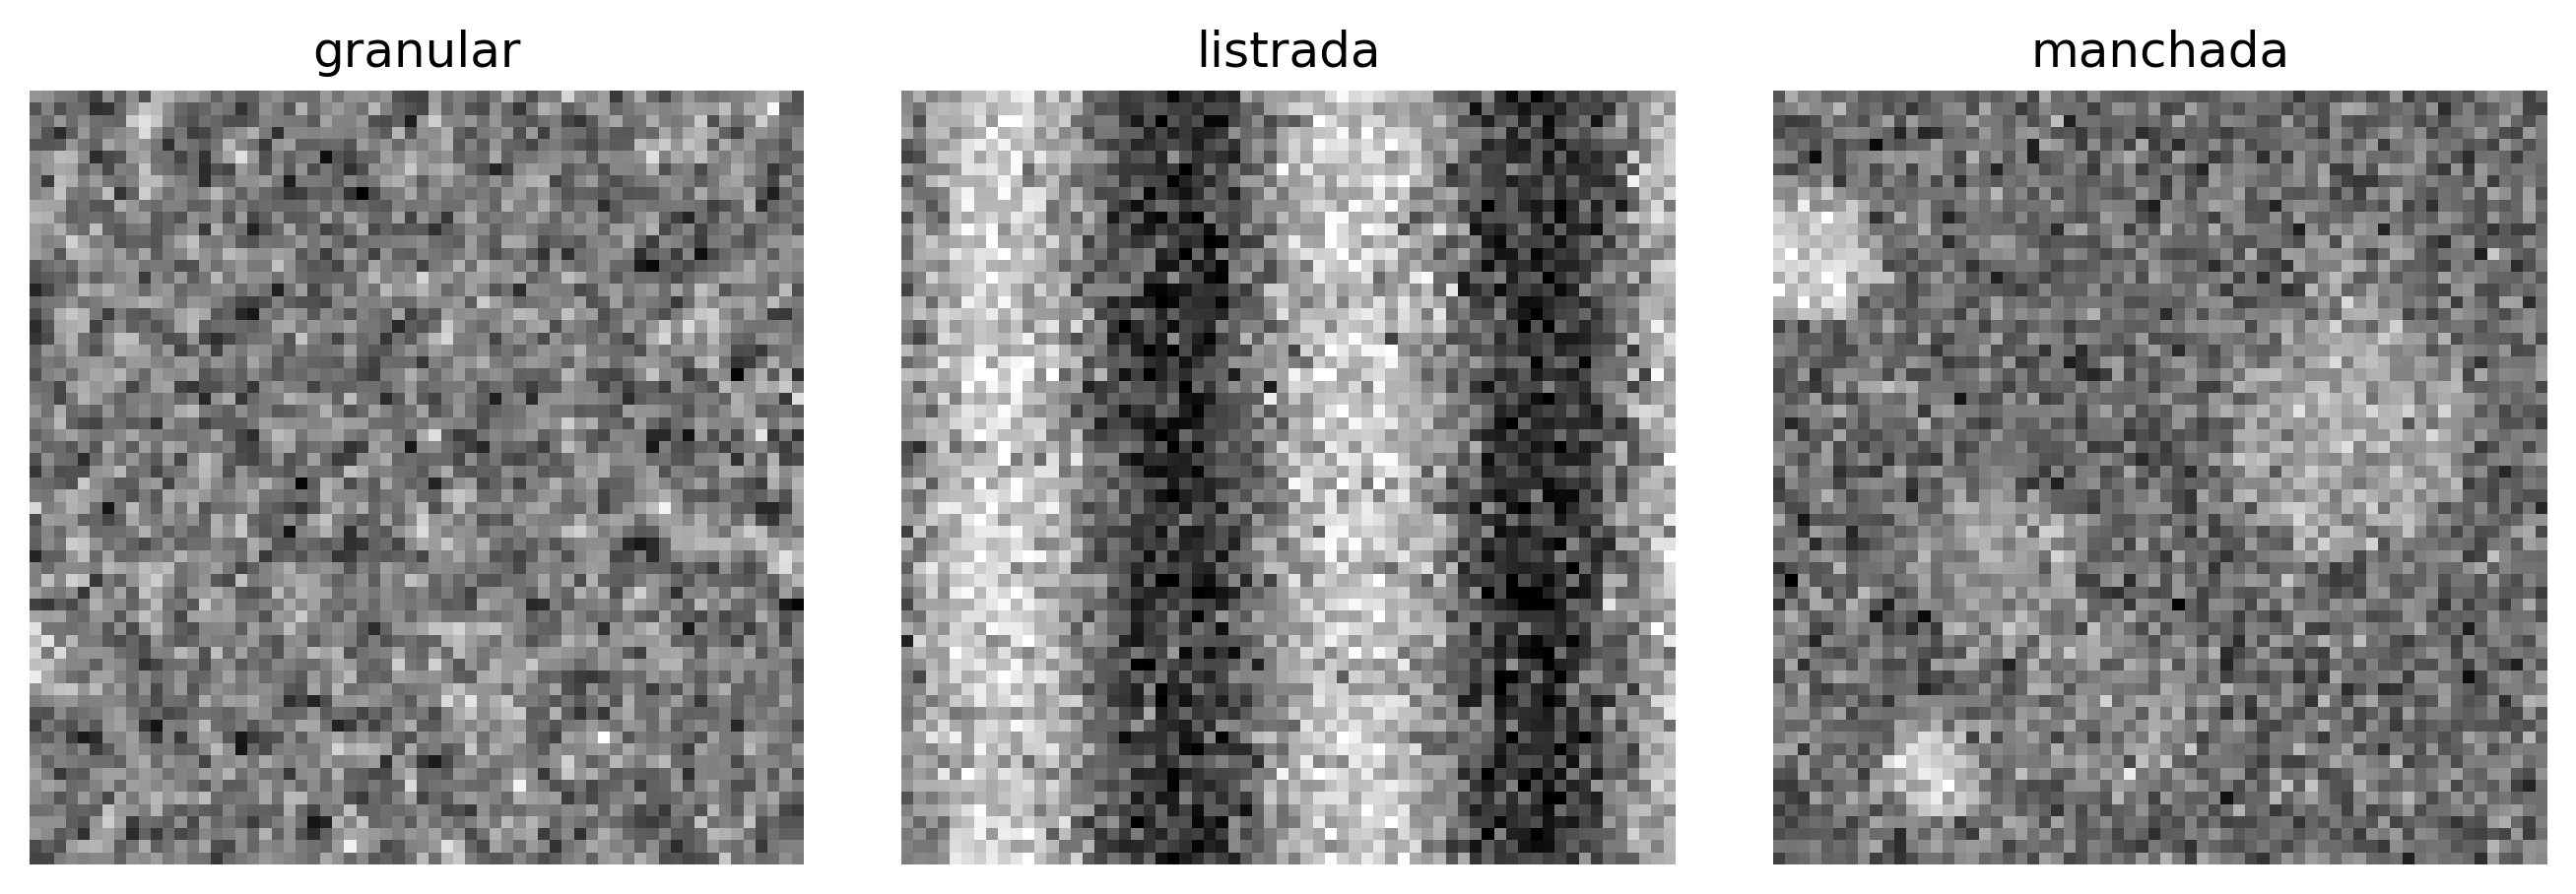

**Figura 7.18:** Muestras sintéticas de las tres clases de textura utilizadas en el experimento de clasificación, generadas con ruido gaussiano y variabilidad intra-clase.


In [17]:
rng = np.random.default_rng(42)

def gerar_textura(classe, tamanho=64, ruido=0.10):
    """Genera una textura sintética de 64x64 perteneciente a una de las tres clases."""
    if classe == "granular":
        escala = rng.uniform(0.14, 0.22)
        img = rng.normal(0.5, escala, (tamanho, tamanho))
        img = cv2.GaussianBlur(img.astype(np.float32), (3, 3), 0)

    elif classe == "listrada":
        n_periodos = rng.uniform(4, 8)
        amplitude = rng.uniform(0.22, 0.38)
        eixo_x = np.linspace(0, n_periodos * np.pi, tamanho)
        base = 0.5 + amplitude * np.sin(eixo_x)
        img = np.tile(base, (tamanho, 1)).astype(np.float32)
        img += rng.normal(0, 0.09, (tamanho, tamanho)).astype(np.float32)

    elif classe == "manchada":
        img = np.full((tamanho, tamanho), 0.5, dtype=np.float32)
        n_manchas = rng.integers(5, 11)
        for _ in range(n_manchas):
            cx, cy = rng.integers(0, tamanho, 2)
            raio = int(rng.integers(3, 11))
            intensidade = float(rng.uniform(0.15, 0.9))
            cv2.circle(img, (int(cx), int(cy)), raio, intensidade, -1)
        img = cv2.GaussianBlur(img, (5, 5), 0)

    else:
        raise ValueError(f"Classe desconhecida: {classe}")

    img = img + rng.normal(0, ruido, (tamanho, tamanho)).astype(np.float32)
    img = np.clip(img, 0, 1)
    return (img * 255).astype(np.uint8)

classes_textura = ["granular", "listrada", "manchada"]
amostras = [gerar_textura(c) for c in classes_textura]

mm.show(amostras, titles=classes_textura, cols=3, figsize=(9, 3))

### 7.13.1 *Pipeline* de Extracción de Características y Evaluación Comparativa

Para comparar el rendimiento de diferentes formas de representación de las imágenes, se generó un conjunto de datos balanceado que contiene 60 muestras para cada clase. A partir de este conjunto, se extrajeron tres tipos de vectores de características, cada uno representando aspectos distintos de la información visual:

1. **Píxeles crudos**: vector obtenido mediante el aplanamiento (*flattening*) de la matriz de intensidades de la imagen, resultando en un vector de $64 \times 64 = 4096$ atributos;
2. **Histograma LBP uniforme**: histograma normalizado de las frecuencias de los patrones locales producidos por el operador LBP uniforme, compuesto por 10 atributos;
3. **Descriptor HOG**: vector formado por histogramas de gradientes orientados, que representan la distribución espacial de las orientaciones de los bordes, totalizando 128 atributos.

Como estos descriptores poseen escalas y dimensionalidades distintas, los vectores de características se estandarizan utilizando el `StandardScaler`, de modo que cada atributo presente media cero y desviación estándar unitaria. Esta etapa evita que atributos con mayor amplitud influyan desproporcionadamente en el cálculo de las distancias euclidianas empleado por el clasificador.

La evaluación se realiza utilizando el algoritmo $k$-NN con $k=5$, bajo el mismo protocolo de validación cruzada estratificada en cinco particiones descrito en la sección anterior. La precisión media obtenida a lo largo de las cinco ejecuciones, ver [Figura 7.19](#fig-07-comparativo-kfolds), proporciona una estimación más estable del rendimiento del clasificador, reduciendo la dependencia de una única división entre entrenamiento y prueba.

Pixels Brutos   -> Precisión Media: 0.6889 (± 0.0478)
LBP (Textura)   -> Precisión Media: 0.7611 (± 0.0648)
HOG (Forma)     -> Precisión Media: 0.4889 (± 0.0624)


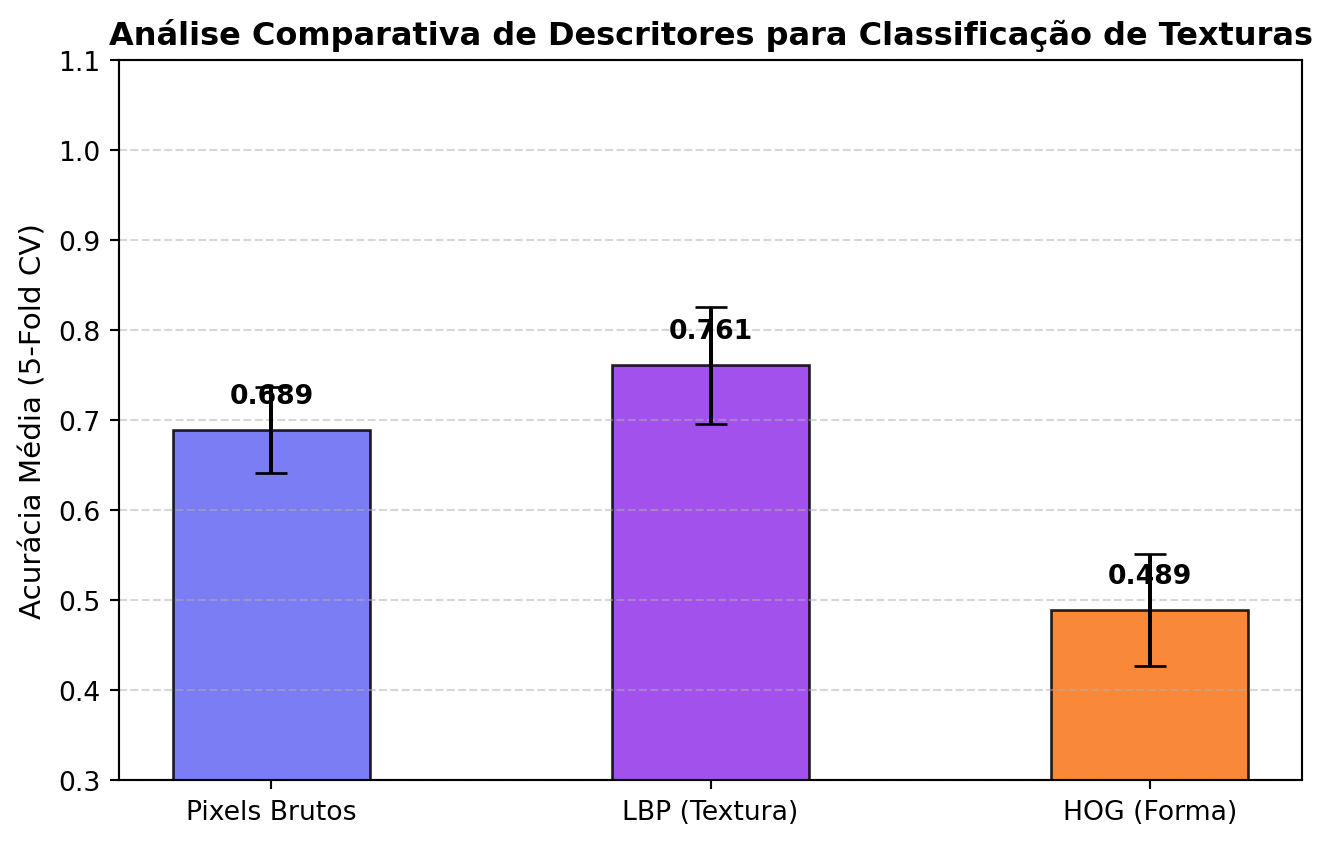

**Figura 7.19:** Precisión media obtenida mediante validación cruzada (5-fold) para los descriptores de Píxeles Brutos, LBP y HOG aplicados a la base de texturas sintéticas.


In [18]:
rng = np.random.default_rng(42)

# 1. Generación de la base de datos
X_bruto, X_lbp, X_hog, y_textura = [], [], [], []

for classe in classes_textura:
    for _ in range(60):
        img = gerar_textura(classe, ruido=0.10)
        
        # Extracción 1: Píxeles brutos
        X_bruto.append(img.ravel())
        
        # Extracción 2: Histograma LBP uniforme
        lbp = local_binary_pattern(img, P=8, R=1, method="uniform")
        hist_lbp, _ = np.histogram(lbp, bins=10, range=(0, 10), density=True)
        X_lbp.append(hist_lbp)
        
        # Extracción 3: Descriptor HOG
        feat_hog = hog(img, orientations=8, pixels_per_cell=(16, 16), cells_per_block=(1, 1))
        X_hog.append(feat_hog)
        
        y_textura.append(classe)

y_textura = np.array(y_textura)
descritores = {
    "Pixels Brutos": np.array(X_bruto),
    "LBP (Textura)": np.array(X_lbp),
    "HOG (Forma)": np.array(X_hog)
}

# 2. Evaluación estadística mediante validación cruzada de 5 pliegues
resultados_media = {}
resultados_desvio = {}

knn = KNeighborsClassifier(n_neighbors=5)
scaler = StandardScaler()

for nome, X_dados in descritores.items():
    X_norm = scaler.fit_transform(X_dados)
    scores = cross_val_score(knn, X_norm, y_textura, cv=5, scoring="accuracy")
    resultados_media[nome] = scores.mean()
    resultados_desvio[nome] = scores.std()
    print(f"{nome:15s} -> Precisión Media: {scores.mean():.4f} (± {scores.std():.4f})")

# 3. Trazado del gráfico comparativo formal
plt.figure(figsize=(7, 4.5))
nomes_desc = list(resultados_media.keys())
medias = list(resultados_media.values())
desvios = list(resultados_desvio.values())

bars = plt.bar(nomes_desc, medias, yerr=desvios, capsize=6, 
               color=["#6366f1", "#9333ea", "#f97316"], 
               width=0.45, edgecolor="black", alpha=0.85)
plt.ylabel("Acurácia Média (5-Fold CV)", fontsize=11)
plt.title("Análise Comparativa de Descritores para Classificação de Texturas", 
          fontsize=12, fontweight="bold")
plt.ylim(0.3, 1.1)
plt.grid(axis="y", linestyle="--", alpha=0.5)

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, 
             h + 0.03, f"{h:.3f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

> ### 📝 ¿Por qué funciona? — LBP como representación de texturas
>
> El descriptor LBP representa la textura de una imagen mediante un histograma normalizado que contabiliza la frecuencia de los patrones locales de intensidad. En lugar de almacenar directamente los valores de los píxeles o sus posiciones, esta representación resume la distribución de las microestructuras presentes en la imagen, produciendo un vector de características compacto.
>
> En este experimento se compararon tres tipos de descriptores: píxeles brutos, LBP y HOG. Los vectores formados por los **píxeles brutos** preservan todas las intensidades de la imagen, pero también incorporan variaciones derivadas del ruido y de pequeños desplazamientos espaciales, lo que puede dificultar la comparación entre muestras mediante la distancia euclidiana.
>
> El descriptor **HOG** representa la distribución de las orientaciones de los gradientes, siendo adecuado para describir formas y contornos. Dado que las imágenes utilizadas en este proyecto difieren principalmente por sus propiedades de textura, y no por la presencia de contornos bien definidos, esta representación tiende a capturar menos información discriminativa que el LBP.
>
> En cambio, el **LBP** fue desarrollado específicamente para caracterizar patrones locales de textura. Su histograma describe la frecuencia de las microestructuras presentes en la imagen, independientemente de su posición exacta, haciendo que la representación sea menos sensible a pequeñas variaciones espaciales y a cambios monótonos de iluminación.
>
> Aunque los histogramas de las diferentes clases presentan distribuciones distintas, el ruido gaussiano introducido en la generación de las imágenes aumenta la variabilidad entre muestras de la misma clase y puede producir regiones de solapamiento en el espacio de características. Como consecuencia, algunas texturas pueden ser confundidas por el clasificador. Aun así, cuando las características relevantes para distinguir las clases están asociadas a los patrones locales de textura, se espera que descriptores diseñados para ese fin, como el LBP, produzcan representaciones más informativas que aquellas basadas únicamente en las intensidades de los píxeles o en las orientaciones de los gradientes.

### 7.13.2 Diagnóstico Fino del Clasificador: Precisión, Exhaustividad y Puntuación F1

La exactitud resume el desempeño del clasificador en un único valor, pero
no indica cómo se distribuye ese desempeño entre las diferentes clases.
Para un análisis más detallado, se utilizan métricas calculadas
individualmente para cada clase.

La **precisión** (*precision*) mide la proporción de muestras clasificadas
como pertenecientes a una clase que realmente pertenecen a ella. La
**exhaustividad** (*recall*) mide la proporción de muestras de la clase que fueron
correctamente identificadas por el clasificador. La **puntuación F1**
corresponde a la media armónica entre precisión y exhaustividad, proporcionando un
indicador que equilibra ambas medidas.

El informe también indica el **soporte** (*support*), es decir, el número de
muestras de cada clase presentes en el conjunto de prueba. Esta información
es importante para contextualizar las métricas, pues los resultados obtenidos
sobre pocas muestras tienden a presentar una mayor variabilidad.

La [Figura 7.20](#fig-07-metricas-avaliacao-detalhadas) presenta estas métricas para las
tres clases de textura. En conjunto, permiten identificar diferencias
de desempeño que no son evidentes solo a partir de la exactitud. Por ejemplo,
una clase puede presentar alta precisión y menor exhaustividad, lo que indica
que el clasificador comete pocos falsos positivos, pero deja de
identificar parte de las muestras que realmente pertenecen a esa clase.
Este tipo de análisis ayuda a comprender las limitaciones del modelo y a
identificar posibles estrategias para su mejora.

=== INFORME DE CLASIFICACIÓN DETALLADO ===
Classe         Precisão    Revocação   F1-score    Suporte
granular           0.67         0.78       0.72         18
listrada           0.55         0.61       0.58         18
manchada           1.00         0.72       0.84         18


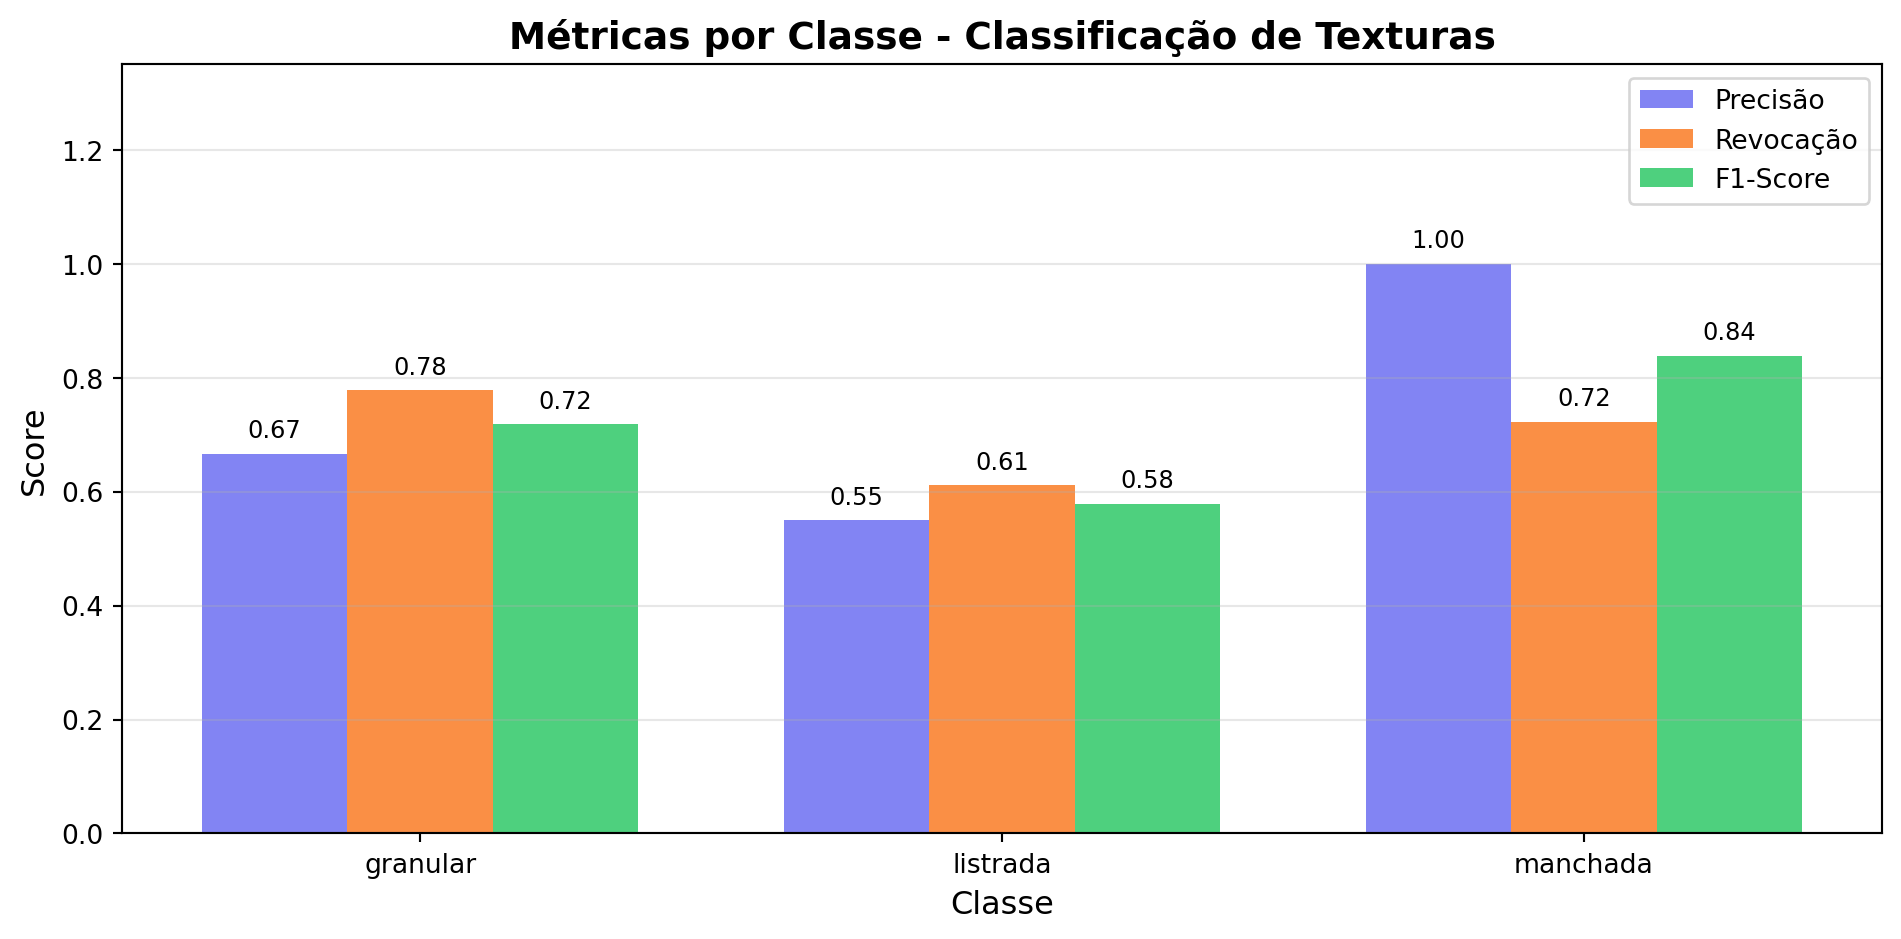

**Figura 7.20:** Métricas de evaluación detalladas para el clasificador k-NN con descriptores LBP


Interpretación de las métricas:
- Precisión: entre las muestras clasificadas como pertenecientes a la clase, ¿cuántas eran correctas?
- Revocación: entre las muestras que realmente pertenecen a la clase, ¿cuántas fueron identificadas?
- Puntuación F1: media armónica entre precisión y revocación.
- Soporte: número de muestras reales de cada clase presentes en el conjunto de prueba.

El soporte no mide el rendimiento; solo informa cuántos ejemplos de cada clase fueron 
utilizados en la evaluación.


In [19]:
X_lbp_data = np.array(X_lbp)
y_textura_data = np.array(y_textura)

# Realizar una división de entrenamiento/prueba para el informe detallado
Xt_treino, Xt_teste, yt_treino, yt_teste = train_test_split(
    X_lbp_data, y_textura_data, test_size=0.3, random_state=42, stratify=y_textura_data
)

# Escalar los datos
scaler = StandardScaler()
Xt_treino_scaled = scaler.fit_transform(Xt_treino)
Xt_teste_scaled = scaler.transform(Xt_teste)

# Entrenar el clasificador k-NN
knn_textura = KNeighborsClassifier(n_neighbors=5)
knn_textura.fit(Xt_treino_scaled, yt_treino)

y_pred = knn_textura.predict(Xt_teste_scaled)

report = classification_report(
    yt_teste,
    y_pred,
    target_names=classes_textura,
    output_dict=True
)

print("=== INFORME DE CLASIFICACIÓN DETALLADO ===")
print(f"{'Classe':<12} {'Precisão':>10} {'Revocação':>12} {'F1-score':>10} {'Suporte':>10}")
for classe in classes_textura:
    r = report[classe]
    print(f"{classe:<12} {r['precision']:>10.2f} {r['recall']:>12.2f} "
          f"{r['f1-score']:>10.2f} {r['support']:>10.0f}")

precision = precision_score(yt_teste, y_pred, average=None, labels=classes_textura)
recall = recall_score(yt_teste, y_pred, average=None, labels=classes_textura)
f1 = f1_score(yt_teste, y_pred, average=None, labels=classes_textura)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(classes_textura))
width = 0.25

bars1 = ax.bar(x - width, precision, width, label='Precisão', color='#6366f1', alpha=0.8)
bars2 = ax.bar(x, recall, width, label='Revocação', color='#f97316', alpha=0.8)
bars3 = ax.bar(x + width, f1, width, label='F1-Score', color='#22c55e', alpha=0.8)

ax.set_xlabel('Classe', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Métricas por Classe - Classificação de Texturas', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classes_textura)
ax.legend(loc='upper right')
ax.set_ylim(0, 1.35)
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                 f'{height:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("Interpretación de las métricas:")
print("- Precisión: entre las muestras clasificadas como pertenecientes a la clase,",
      "¿cuántas eran correctas?")
print("- Revocación: entre las muestras que realmente pertenecen a la clase, ¿cuántas",
      "fueron identificadas?")
print("- Puntuación F1: media armónica entre precisión y revocación.")
print("- Soporte: número de muestras reales de cada clase presentes en el conjunto de prueba.")
print("\nEl soporte no mide el rendimiento; solo informa cuántos ejemplos de cada",
      "clase fueron \nutilizados en la evaluación.")

## 7.14 Limitaciones de los Descriptores Artesanales

Los experimentos de este capítulo muestran que los descriptores clásicos pueden
ser bastante eficaces en tareas de clasificación, pero también presentan
limitaciones importantes:

- **Especificidad:** cada descriptor fue desarrollado para representar un
  determinado tipo de información, como color, textura o forma. Así, un
  descriptor adecuado para una tarea puede no ser el más apropiado para
  otra.
- **Dependencia de hiperparámetros:** el rendimiento de descriptores como
  LBP y HOG depende de la elección de parámetros, como radio de vecindad,
  número de puntos muestreados, tamaño de la celda y número de orientaciones,
  que deben ajustarse según la aplicación.
- **Representación limitada:** los descriptores de color, textura y gradiente
  capturan propiedades de bajo nivel de la imagen, pero no representan
  directamente conceptos semánticos más complejos, como objetos o escenas.
- **Maldición de la dimensionalidad:** los descriptores muy extensos pueden
  reducir la eficacia de los clasificadores basados en distancia, como el
  *k*-NN.

Estas limitaciones motivan la evolución de las técnicas estudiadas en los
próximos capítulos. El **Capítulo 8** presenta métodos clásicos para la
detección y correspondencia de características en imágenes, mientras que el
**Capítulo 9** introduce las **Redes Neuronales Convolucionales**, capaces de
aprender automáticamente representaciones adecuadas para cada tarea a partir
de los datos.

## 7.15 Resumen

En este capítulo se presentaron los fundamentos del reconocimiento de
patrones aplicado a imágenes. Los principales conceptos estudiados fueron:

- ***Pipeline* de reconocimiento de patrones:** adquisición,
  preprocesamiento, extracción de descriptores, clasificación y evaluación.
- **Descriptores clásicos:** descriptores de color, LBP para textura y HOG
  para forma, utilizados para representar diferentes características de las
  imágenes.
- **Normalización de características:** estandarización (*Z-score*) para
  evitar que atributos de mayor magnitud dominen el cálculo de las
  distancias.
- **Clasificador *k*-NN:** clasificación basada en los $k$ vecinos más
  cercanos en el espacio de características.
- **Elección del parámetro $k$:** influencia del valor de $k$ sobre el
  rendimiento del clasificador y uso de la validación cruzada para su
  selección.
- **Evaluación de clasificadores:** exactitud, matriz de confusión,
  precisión, recuperación y puntuación F1 como métricas complementarias de
  rendimiento.
- **Limitaciones de los descriptores artesanales:** especificidad,
  dependencia de hiperparámetros y dificultad para representar información
  de alto nivel.

Los conceptos se ilustraron mediante experimentos con la base pública
`load_digits`, texturas sintéticas generadas con fines didácticos y datos
simulados de descriptores de frutas.

## 7.16 🤖 Uso del Gemini Notebook como Tutor

En esta edición, el **Gemini Notebook** se presenta como una herramienta de apoyo
al estudio. El sistema utiliza exclusivamente los documentos proporcionados
por el autor como fuente de conocimiento, permitiendo explorar los conceptos
del capítulo mediante preguntas, resúmenes y explicaciones relacionadas con el
material estudiado.

> ### ❗ 🎓 Estudia con el Tutor Inteligente
>
> [🚀 ACCEDER AL GEMINI NOTEBOOK: CAPÍTULO 07](https://notebooklm.google.com/notebook/494d06c6-ca01-4cd2-aa00-dbe30469308c)
>
> #### 🌐 Idioma y Lenguaje de Programación
>
> El proyecto de este capítulo en el Gemini Notebook fue construido únicamente con el texto en **portugués** y los ejemplos de código en **Python**. Si estás estudiando con la edición en inglés o francés, o siguiendo la ruta en C++, las respuestas del tutor pueden no corresponder exactamente con la versión que estás leyendo.
>
> #### ⚠️ Aviso sobre Contenido Generado por IA
>
> Las respuestas proporcionadas por el Gemini Notebook pueden contener imprecisiones u omisiones. Siempre que sea necesario, confirma la información utilizando el material de este capítulo y otras fuentes académicas confiables. La ejecución de los ejemplos prácticos presentados a lo largo del texto sigue siendo la mejor forma de consolidar los conceptos estudiados.

## 7.17 Lista de Ejercicios

Los ejercicios siguientes exploran y extienden los conceptos presentados
en este capítulo mediante adaptaciones de los algoritmos implementados,
análisis experimentales y comparaciones entre diferentes enfoques.

1. **(10%)** Implemente un descriptor de color (histograma RGB o HSV, con al menos 16 *bins* por canal) para las tres clases de frutas simuladas en la [Figura 7.1](#fig-07-frutas-motivacao). Entrene un clasificador *k*-NN con este descriptor, compare su exactitud con la obtenida por los descriptores LBP y HOG ([Figura 7.9](#fig-07-comparacao-descritores-detalhada)) y discuta en qué situaciones la información de color es más discriminativa.

2. **(15%)** Investigue el efecto de la normalización de características (*Z-score*) sobre el desempeño del *k*-NN en un espacio de atributos heterogéneo, combinando descriptores de color, LBP y HOG en un único vector. Compare los resultados obtenidos con y sin normalización para al menos tres valores de $k$.

3. **(15%)** Reproduzca el análisis de *overfitting* y *underfitting* de la [Figura 7.17](#fig-07-overfitting-analysis) variando el tamaño del conjunto de entrenamiento (por ejemplo, 20%, 50% y 80% de la base `load_digits`). Discuta cómo la cantidad de ejemplos influye en la elección del valor de $k$.

4. **(15%)** Extienda el Proyecto Práctico 2 añadiendo una cuarta clase sintética de textura. Evalúe precisión, exhaustividad y F1-score para cada clase, siguiendo el patrón de la [Figura 7.20](#fig-07-metricas-avaliacao-detalhadas), y analice el impacto de la nueva clase en la matriz de confusión.

5. **(15%)** Implemente manualmente el clasificador *k*-NN, sin utilizar `sklearn`:

   `sklearn.neighbors.KNeighborsClassifier`,

   completando la función `knn_passo_a_passo` presentada en el capítulo. Compare la exactitud y el tiempo de ejecución de la implementación manual con la implementación de `scikit-learn` en conjuntos de datos de tamaños crecientes y relacione los resultados con la maldición de la dimensionalidad.

6. **(15%)** Investigue la influencia de los parámetros `orientations`, `pixels_per_cell` y `cells_per_block` del descriptor HOG en la base `load_digits`. Evalúe al menos cuatro combinaciones de parámetros y discuta el compromiso entre dimensionalidad del descriptor y desempeño del clasificador.

7. **(15%)** Evalúe la influencia de los parámetros $P$ (número de vecinos) y $R$ (radio) del descriptor LBP en la clasificación de las texturas sintéticas del Proyecto Práctico 2, considerando $P \in \{4,8,16\}$ y $R \in \{1,2,3\}$. Analice cómo estos parámetros afectan la capacidad discriminativa del descriptor.

8. **(Bono – 10%)** Implemente manualmente la validación cruzada *k-fold* para el clasificador *k*-NN en la base `load_digits`, sin utilizar `cross_val_score`, y compare los resultados con los obtenidos por la implementación de `scikit-learn` presentada en la [Figura 7.16](#fig-07-elbow-k).

## Referencias del Capítulo

La fundamentación teórica y los experimentos presentados en este capítulo se basan en las siguientes referencias:

- Gonzalez (2018), por los fundamentos de descriptores estadísticos de textura y de las operaciones de preprocesamiento aplicadas a la extracción de características.
- Szeliski (2022), por la presentación del pipeline clásico de reconocimiento de patrones, de la extracción de descriptores y de la evaluación de clasificadores en Visión por Computadora.
- Duda (2001), por los fundamentos teóricos del reconocimiento de patrones, del clasificador *k*-NN y de la relación entre sesgo y varianza.
- Cover (1967), por la formulación original del algoritmo de los *k* vecinos más cercanos.
- Ojala (2002), por la formulación del descriptor *Local Binary Patterns* (LBP) y de su variante uniforme, utilizada en este capítulo.
- Dalal (2005), por la formulación del descriptor *Histogram of Oriented Gradients* (HOG), empleado en la representación de forma y contorno.
- Pedregosa (2011), por la implementación del clasificador *k*-NN, de las métricas de evaluación y de la validación cruzada en la biblioteca `scikit-learn`.
- Quilici-gonzalez (2014), por la presentación didáctica de clasificadores tradicionales de Reconocimiento de Patrones, como Árboles de Decisión, Reglas de Clasificación y Máquinas de Vectores de Soporte (SVM), complementarios al clasificador k-NN explorado en este capítulo.
- Quilici-gonzalez (2026), por la actualización y ampliación de estos contenidos en su 2ª edición, actualmente en producción.

------------------------------------------------------------------------


<a href="https://colab.research.google.com/github/fzampirolli/pdi-vc/blob/master/notebooks_alunos/py.es/cap07/cap07.EPs_aluno.ipynb"><img src="imagens/colab-badge.png" style="height:20px;vertical-align:middle"></a>
<a href="https://github.com/fzampirolli/pdi-vc"><img src="imagens/github-badge.png" style="height:20px;vertical-align:middle"></a>

## 7.18 💻 **Parte Práctica con Ejercicios de Programación**

La presente lista de ejercicios de programación (EP) consolida las formulaciones teóricas presentadas a lo largo del Capítulo 7 — Clasificación de Imágenes y Reconocimiento de Patrones — mediante una ruta práctica aplicada. A diferencia de la manipulación directa de píxeles de los capítulos anteriores, los EPs de este capítulo trabajan con las **magnitudes intermedias** de un *pipeline* real de reconocimiento de patrones — vectores de características, distancias, etiquetas previstas y reales, códigos binarios locales e histogramas de orientación — permitiendo validar manualmente cada etapa del razonamiento sin depender de bibliotecas externas de aprendizaje automático.

El encadenamiento de los ejercicios reproduce el flujo conceptual del capítulo: se comienza con la implementación manual de la regla de decisión del clasificador **k-NN** sobre un pequeño espacio de características; a continuación, se revisita, desde la óptica de la normalización de características, el clasificador implementado en el primer ejercicio de la lista; se avanza hacia el cálculo de las métricas de **evaluación** (matriz de confusión, precisión y exhaustividad) a partir de etiquetas previstas y reales; se prosigue con la codificación manual del descriptor de textura **LBP** a partir de una vecindad $3\times3$; se profundiza en el cálculo del histograma de orientaciones del descriptor **HOG** para una única celda; se avanza, a continuación, hacia la integración de **extracción de descriptores**, **clasificación k-NN** y **evaluación multiclase** en un *pipeline* completo de reconocimiento de texturas; y se concluye con la aplicación de ese mismo *pipeline* sobre una **imagen real** (formato PGM), en el que el descriptor LBP se calcula directamente sobre los píxeles de un mosaico de texturas.

### 🎯 Objetivo de este Cuaderno

El cuaderno permite desarrollar, validar, organizar y probar soluciones de **Ejercicios de Programación (EPs)** en entornos interactivos, como Colab, con los mismos casos de prueba de Moodle, copiándolos allí solo al momento de registrar la nota oficial.

### *Download*

Descargue `morph.py` y `testsuite.py` ejecutando la celda siguiente:

In [20]:
import os, urllib.request

url = "https://raw.githubusercontent.com/fzampirolli/pdi-vc/master/morph/config.py"
if not os.path.exists("config.py"):
    urllib.request.urlretrieve(url, "config.py")

import config
config.setup(testsuite=True)
from morph import mm
from testsuite import TestSuite

✅ Entorno listo. Morph: 1.1.9 | OpenCV: 5.0.0 | TestSuite: 1.1.2


#### Ejecutando las pruebas
Para evaluar las pruebas, ejecute `TestSuite("EP07_01.extensión").run()` en una nueva celda, reemplazando la extensión por la del lenguaje utilizado (`.py`, `.java`, `.c`, `.cpp`, `.js` o `.r`). El sistema descarga los casos de prueba de GitHub, ejecuta el programa y calcula la nota automáticamente.

Para probar código Python directamente, sin guardar archivo, use `run_code(codigo)` pasando el código como *string* en una variable `codigo`:

```python
codigo = """
# 7 ... su código aquí ...
"""
TestSuite("EP07_01").run_code(codigo)
```

### 🛠️ Resumen de los Métodos de `morph.py` (Cap. 7)

La biblioteca `morph.py` ofrece dos versiones para la mayoría de los algoritmos: una **didáctica** (métodos terminados en `0`), implementada paso a paso en NumPy, y otra **clásica**, basada en las bibliotecas `scikit-learn` y `scikit-image`. Las implementaciones didácticas se utilizan en los **Ejercicios de Programación (EPs)**, ya que no dependen de bibliotecas externas y se ejecutan dentro del límite de memoria del entorno **VPL** de Moodle. En cambio, las versiones clásicas son más eficientes y se recomiendan para experimentos en entornos como Colab y Jupyter Notebook, pero normalmente **no pueden utilizarse en los EPs** de Moodle, ya que la biblioteca `scikit-learn` excede la memoria disponible en el VPL.

1. **Lectura de datos (`readClasses`, `readDataset`, `readTrain`, `readTest`)**  
   Estandarizan la entrada de los conjuntos de entrenamiento y prueba, devolviendo las matrices de características ($X$) y los vectores de etiquetas ($y$).

2. **Clasificación (`knn0` / `knn`)**  
   Implementan el algoritmo de los **k-vecinos más cercanos (k-NN)** para clasificación binaria y multiclase, utilizando distancia Euclidiana o Manhattan.

3. **Normalización (`zscore0` / `zscore`)**  
   Aplican la normalización *z-score* a los atributos, reduciendo diferencias de escala antes de la clasificación.

4. **Evaluación (`confusion0` / `confusion`)**  
   Calculan la matriz de confusión y métricas como exactitud, precisión y recuperación, tanto para problemas binarios como multiclase.

5. **Descriptor de textura (`lbp0` / `lbp`)**  
   Calculan el ***Local Binary Pattern* (LBP)**, permitiendo obtener el mapa LBP, el código de un píxel o el histograma de una región de la imagen.

6. **Descriptor de forma (`hog0` / `hog`)**  
   Calculan el ***Histogram of Oriented Gradients* (HOG)**, produciendo histogramas de las orientaciones de los gradientes para representar información de forma y contorno.

### 7.0.1 EP07_01 🟢 Clasificador k-NN Paso a Paso

El `KNeighborsClassifier` de `scikit-learn`, utilizado a lo largo del capítulo, oculta detrás de una única llamada (`.fit` / `.predict`) una regla de decisión bastante simple: para cada nueva observación, calcular la distancia a todos los ejemplos de entrenamiento, seleccionar los $k$ más cercanos y votar por la clase mayoritaria entre ellos.

Antes de confiar en la biblioteca, se te ha encargado implementar esta regla desde cero, para un espacio de características bidimensional, exactamente como el simulador interactivo de frontera de decisión del capítulo lo hace internamente en cada clic del usuario.

#### 7.0.1.1 📋 Directrices de Implementación

1. **Cantidad y parámetro:** Leer el entero $N$ (número de ejemplos de entrenamiento) y el entero impar $k$ (número de vecinos).
2. **Ejemplos de entrenamiento:** Para cada uno de los $N$ ejemplos, leer tres valores: las coordenadas $x$ e $y$ (reales) y la etiqueta $r$ (entera, $0$ o $1$).
3. **Consultas:** Leer el entero $Q$ (número de puntos de consulta) y, a continuación, las coordenadas $x_q$, $y_q$ (reales) de cada consulta.
4. **Distancia:** Para cada consulta, calcular la distancia euclidiana hasta **todos** los ejemplos de entrenamiento:
$$
d(x_q, x_i) = \sqrt{(x_q - x_i)^2 + (y_q - y_i)^2}.
$$
5. **Selección de vecinos:** Ordenar los ejemplos por distancia creciente y seleccionar los $k$ primeros. En caso de **empate de distancia** en la frontera del k-ésimo vecino, desempatar por el ejemplo leído **primero** en la entrada (orden de lectura estable).
6. **Votación mayoritaria:** Contar los votos de cada clase entre los $k$ vecinos seleccionados. Si hay **empate en la votación** (solo posible cuando $k$ es par, lo que no debería ocurrir según la directriz del punto 1, pero tratar defensivamente), asignar la clase del vecino más cercano entre las clases empatadas.
7. **Salida:** Para cada consulta, en el orden de entrada, imprimir la clase predicha. Al final, imprimir el total de consultas clasificadas como clase `1`.

#### 7.0.1.2 📌 Restricciones Computacionales

* **Métrica fija:** utilizar exclusivamente la distancia euclidiana (no la *distancia al cuadrado*) para la ordenación, aunque el resultado de la comparación sea el mismo.
* **k siempre impar:** la entrada garantiza $k$ impar y $k \le N$; aun así, implementar el desempate del punto 6 por robustez.
* **Estabilidad:** al ordenar por distancia, preservar el orden relativo de ejemplos con la misma distancia (ordenación estable).

#### 7.0.1.3 🧠 Fundamentación Teórica

| Elemento | Papel en el k-NN |
|---|---|
| Espacio de características | Conjunto de todos los vectores $(x, y)$ posibles |
| Distancia euclidiana | Medida de similitud entre observaciones |
| $k$ pequeño | Frontera irregular, alta varianza |
| $k$ grande | Frontera suave, alto sesgo |
| Votación mayoritaria | Regla de decisión $\hat y = \operatorname{moda}\{y_i : x_i \in N_k(x)\}$ |

#### 7.0.1.4 📦 Especificación de Entrada y Salida (VPL)

**Entrada:**

* Línea 1: Enteros $N$ y $k$, separados por espacio.
* Siguientes $N$ líneas: tres valores por línea — $x$, $y$ (reales) y $r$ (entero $\in \{0,1\}$), separados por espacio.
* Siguiente línea: entero $Q$.
* Siguientes $Q$ líneas: dos valores por línea — $x_q$, $y_q$ (reales), separados por espacio.

**Salida:**

* $Q$ líneas, cada una con la clase predicha (`0` o `1`) para la respectiva consulta, en el orden de entrada.
* Última línea: `Total clase 1: X`.

#### 7.0.1.5 📌 Ejemplos

| Entrada | Salida | Observación |
|---|---|---|
| 4 3<br>0 0 0<br>1 0 0<br>5 5 1<br>6 5 1<br>1<br>1 1 | 0<br>Total clase 1: 0 | Consulta cercana al agrupamiento de clase 0. |
| 4 1<br>0 0 0<br>1 0 0<br>5 5 1<br>6 5 1<br>2<br>0.9 0.1<br>5.5 5.1 | 0<br>1<br>Total clase 1: 1 | Con $k=1$, cada consulta hereda la clase del vecino más cercano. |

In [21]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML("""
<div id="sim-ep0701" style="background-color:#fbf7ee;border-radius:18px;border:1px solid #e4dcc8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);position:relative;">

<style>
  #sim-ep0701 * { box-sizing: border-box; margin: 0; padding: 0; }
  #sim-ep0701 button { font-size: 11px; padding: 6px 12px; border-radius: 8px; border: 1px solid #e4dcc8; background: #f1ead7; color: #5e5a4a; cursor: pointer; transition: all 0.15s ease; font-weight: 600; display: inline-flex; align-items: center; justify-content: center; gap: 5px; }
  #sim-ep0701 button:hover { background: #e8dfcf; }
  #sim-ep0701 input[type=range] { width: 100%; accent-color: #26241d; cursor: pointer; height: 4px; }
  .sim-ep0701_pill { font-size: 10px; font-weight: 700; padding: 3px 10px; border-radius: 40px; border: 1px solid #e4dcc8; background: #26241d; color: #7ee7c6; font-family: monospace; }
  .sim-ep0701_panel { background: #fafaf7; border: 1px solid #e9e3d3; border-radius: 12px; padding: 12px; }
</style>

<!-- Cabeçalho -->
<div style="background:#f1ead7;padding:8px 16px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #e4dcc8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
  <span style="font-weight:600;color:#26241d;">🎮 Simulador EP07_01: Clasificador k-NN Paso a Paso</span>
  <span class="sim-ep0701_pill">Votación Mayoritaria</span>
</div>

<div style="padding:16px;background:#ffffff;">

  <!-- Painel de Controles -->
  <div class="sim-ep0701_panel" style="margin-bottom:14px;">
    <div style="display:flex; justify-content:space-between; align-items:center; margin-bottom:6px;">
      <label style="font-size:11px; font-weight:700; color:#5e5a4a;">
        Número de Vecinos (k): <span id="sim-ep0701_vl" style="font-family:monospace; color:#26241d;">3</span>
      </label>
    </div>
    
    <input id="sim-ep0701_sl" type="range" min="1" max="7" step="2" value="3">
    
    <div style="font-size:10.5px; color:#8a8371; font-weight:600; margin-top:8px; text-align:center;">
      Ajusta k y observa qué ejemplos de entrenamiento (ordenados por distancia) participan en la votación para la consulta fija (&starf; en x = 3, y = 3).
    </div>
  </div>

  <!-- Cards de Amostras -->
  <div id="sim-ep0701_cards" style="display:grid; grid-template-columns: repeat(auto-fit, minmax(110px, 1fr)); gap:10px; margin-bottom:14px;"></div>

  <!-- Painel Informativo / Debug -->
  <div id="sim-ep0701_debug" class="sim-ep0701_panel" style="font-family:monospace; font-size:11px; color:#26241d; text-align:center;">
    &ndash;
  </div>

</div>
</div>

<script>
(function(){
  function initSim07Ep01(root){
    if (!root || root.dataset.sim07Ep01Init) return;
    root.dataset.sim07Ep01Init = "1";

    var query = {x: 3, y: 3};
    var pontos = [
      {nome: "A", x: 0, y: 0, r: 0},
      {nome: "B", x: 1, y: 0, r: 0},
      {nome: "C", x: 5, y: 5, r: 1},
      {nome: "D", x: 6, y: 5, r: 1},
      {nome: "E", x: 2, y: 2, r: 0},
      {nome: "F", x: 4, y: 4, r: 1},
      {nome: "G", x: 0, y: 2, r: 0},
      {nome: "H", x: 6, y: 3, r: 1}
    ];

    pontos.forEach(function(p, i){
      p.d = Math.sqrt(Math.pow(p.x - query.x, 2) + Math.pow(p.y - query.y, 2));
      p.idx = i;
    });

    pontos.sort(function(a, b){
      return (a.d - b.d) || (a.idx - b.idx);
    });

    var slEl  = root.querySelector('#sim-ep0701_sl');
    var vlEl  = root.querySelector('#sim-ep0701_vl');
    var cards = root.querySelector('#sim-ep0701_cards');
    var dbg   = root.querySelector('#sim-ep0701_debug');

    function render(){
      var k = parseInt(slEl.value, 10);
      vlEl.textContent = k;
      cards.innerHTML = '';
      var votos = [0, 0];

      pontos.forEach(function(p, i){
        var dentro = i < k;
        if (dentro) votos[p.r]++;

        var div = document.createElement('div');
        div.style.cssText = 'text-align:center; border-radius:10px; padding:10px 6px; font-size:11px; transition:all 0.15s ease;' +
          (dentro 
            ? (p.r === 0 
                ? 'background:#eafaf1; border:1px solid #a3e4d7; color:#04342C;' 
                : 'background:#fdecea; border:1px solid #f5b7b1; color:#c0392b;') 
            : 'background:#fafaf7; border:1px solid #e4dcc8; color:#8a8371;');

        div.innerHTML = '<div style="font-weight:700; margin-bottom:4px;">' + p.nome + ' (r = ' + p.r + ')</div>' +
          '<div style="font-family:monospace; margin-bottom:4px; font-size:10px;">d = ' + p.d.toFixed(2) + '</div>' +
          '<div style="font-weight:700; font-size:10px;">' + (dentro ? 'VOTA' : '&ndash;') + '</div>';

        cards.appendChild(div);
      });

      var previsto = votos[1] > votos[0] ? 1 : (votos[0] > votos[1] ? 0 : pontos[0].r);

      if (previsto === 0) {
        dbg.style.borderColor = '#a3e4d7';
        dbg.style.background  = '#eafaf1';
        dbg.style.color       = '#04342C';
      } else {
        dbg.style.borderColor = '#f5b7b1';
        dbg.style.background  = '#fdecea';
        dbg.style.color       = '#c0392b';
      }

      dbg.textContent = 'k = ' + k + '  |  Votos Classe 0: ' + votos[0] + ', Classe 1: ' + votos[1] + '  |  Classe prevista: ' + previsto;
    }

    slEl.addEventListener('input', render);
    render();
  }

  function tryInitSim07Ep01(){
    var root = document.getElementById('sim-ep0701');
    if (root) initSim07Ep01(root); else setTimeout(tryInitSim07Ep01, 200);
  }
  tryInitSim07Ep01();
})();
</script>
""")

**Figura 7.21:** Simulador EP07_01: Clasificador k-NN Paso a Paso


In [22]:
%%writefile EP07_01.py
# Código Python

Overwriting EP07_01.py


In [23]:
TestSuite("EP07_01.py").run()

### 7.0.2 EP07_02 🟡 Normalización *Z-score* y Robustez del k-NN ante Escalas Distintas

Este ejercicio revisita el clasificador implementado en el **EP07_01**, esta vez bajo la óptica discutida en la sección *El Impacto de la Escala y la Normalización de Características* del capítulo: el k-NN decide basándose en la distancia entre vectores, de modo que una característica medida en una escala mucho mayor que las demás tiende a **dominar** el cálculo de la distancia, incluso cuando no es la más relevante para separar las clases.

Un sistema de inspección registra, para cada pieza, su **área** (en píxeles, pudiendo llegar a cientos o miles) y su **circularidad** (siempre entre $0$ y $1$). Usted ha sido encargado de clasificar nuevas piezas mediante k-NN de dos formas — con y sin la estandarización *Z-score* presentada en el capítulo — y de reportar en qué casos ambas aproximaciones **divergen**.

#### 7.0.2.1 📋 Directrices de Implementación

1. **Cantidad y parámetro:** Leer el entero $N$ (número de ejemplos de entrenamiento) y el entero impar $k$.
2. **Ejemplos de entrenamiento:** Para cada uno de los $N$ ejemplos, leer tres valores: el área $x_1$ (real), la circularidad $x_2$ (real) y la etiqueta $r$ (entero, $0$ o $1$).
3. **Consultas:** Leer el entero $Q$ y, a continuación, las coordenadas $x_1, x_2$ de cada consulta.
4. **Clasificación sin normalización:** Para cada consulta, clasifíquela mediante k-NN directamente sobre $(x_1, x_2)$, con distancia euclidiana y las mismas reglas de desempate del EP07_01 (orden de lectura para distancias empatadas; vecino más cercano entre clases empatadas en la votación).
5. **Parámetros de normalización:** Calcular la media $\mu_j$ y la desviación estándar **poblacional** $\sigma_j$ (división por $N$, no por $N-1$ — la misma convención adoptada por la clase `StandardScaler`) de cada característica $j \in \{1,2\}$, **exclusivamente sobre el conjunto de entrenamiento**.
6. **Estandarización:** Transformar cada característica de entrenamiento y de consulta mediante
$$
z_j = \frac{x_j - \mu_j}{\sigma_j}.
$$
Si $\sigma_j = 0$ (característica constante en el entrenamiento), definir $z_j = 0$ para todas las muestras de esa característica, evitando la división por cero.
7. **Clasificación con normalización:** Repetir la clasificación k-NN del punto 4, ahora sobre los vectores estandarizados $(z_1, z_2)$, con las mismas reglas de desempate.
8. **Salida:** Para cada consulta, en el orden de entrada, imprimir las dos clases previstas. Al final, imprimir el número de consultas en las que las dos clasificaciones **divergen**.

#### 7.0.2.2 📌 Restricciones Computacionales

* **Ajuste solo en el entrenamiento:** $\mu_j$ y $\sigma_j$ se calculan únicamente a partir del conjunto de entrenamiento y se reaplican a las consultas — nunca se recalculan a partir de ellas. Esta práctica evita la **fuga de datos** (*data leakage*), mencionada en la sección de normalización del capítulo.
* **Desviación estándar poblacional:** utilizar $\sigma_j = \sqrt{\frac{1}{N}\sum_i (x_{i,j}-\mu_j)^2}$, y no la versión muestral (división por $N-1$).
* **Característica constante:** tratar $\sigma_j = 0$ como caso especial (punto 6); no debe ocurrir un error de división por cero.
* **Reglas de desempate:** reutilizar exactamente las convenciones del EP07_01, tanto en la selección de los $k$ vecinos como en la votación mayoritaria.

#### 7.0.2.3 🧠 Fundamentación Teórica

| Elemento | Papel |
|---|---|
| Estandarización *Z-score* | Reescala cada característica para media $0$ y desviación estándar $1$, haciendo comparables escalas heterogéneas |
| Ajuste (*fit*) solo en el entrenamiento | Garantiza que la evaluación sobre las consultas refleje únicamente lo que el modelo aprendió en el entrenamiento |
| Distancia euclidiana sin normalización | Dominada por la característica de mayor amplitud — aquí, el área |
| Predicción divergente | Evidencia que la escala de las características, y no solo el algoritmo o los datos, puede determinar la frontera de decisión del k-NN |

Este ejercicio refuerza, de forma controlada, la razón por la cual el `StandardScaler` se aplica antes del k-NN a lo largo del capítulo: sin esta etapa, las características de circularidad — incluso siendo altamente discriminativas — pueden ser prácticamente ignoradas por el clasificador frente a una característica de área con amplitud cientos de veces mayor.

#### 7.0.2.4 📦 Especificación de Entrada y Salida (VPL)

**Entrada:**

* Línea 1: Enteros $N$ y $k$, separados por espacio.
* Siguientes $N$ líneas: tres valores por línea — $x_1$, $x_2$ (reales) y $r$ (entero $\in \{0,1\}$), separados por espacio.
* Siguiente línea: entero $Q$.
* Siguientes $Q$ líneas: dos valores por línea — $x_1$, $x_2$ (reales) de la consulta, separados por espacio.

**Salida:**

* $Q$ líneas, en el formato `SemNorm=<0|1> ComNorm=<0|1>`, en el orden de entrada de las consultas.
* Última línea: `Divergiu: <int>`.

#### 7.0.2.5 📌 Ejemplos

| Entrada | Salida | Observación |
|---|---|---|
| 4 3<br>10 0.9 0<br>12 0.85 0<br>900 0.2 1<br>950 0.25 1<br>1<br>500 0.88 | SemNorm=1 ComNorm=0<br>Divergiu: 1 | Sin normalización, el área (escala de cientos) domina la distancia y la consulta se clasifica como clase `1`. Tras la estandarización, la circularidad — mucho más cercana a las muestras de clase `0` — pasa a pesar de forma comparable, y la predicción cambia a `0`. |
| 2 1<br>0 0.5 0<br>100 0.5 1<br>1<br>60 0.5 | SemNorm=1 ComNorm=1<br>Divergiu: 0 | La circularidad es constante en el entrenamiento ($\sigma_2=0$); por la regla del punto 6, $z_2=0$ para todas las muestras, y la clasificación depende solo del área en ambos casos. |

In [24]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML("""
<div id="sim-ep0702" style="background-color:#fbf7ee;border-radius:18px;border:1px solid #e4dcc8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);position:relative;">

<style>
  #sim-ep0702 * { box-sizing: border-box; margin: 0; padding: 0; }
  #sim-ep0702 button { font-size: 11px; padding: 6px 12px; border-radius: 8px; border: 1px solid #e4dcc8; background: #f1ead7; color: #5e5a4a; cursor: pointer; transition: all 0.15s ease; font-weight: 600; display: inline-flex; align-items: center; justify-content: center; gap: 5px; }
  #sim-ep0702 button:hover { background: #e8dfcf; }
  #sim-ep0702 button.sim-ep0702_active { background: #26241d !important; border-color: #26241d !important; color: #7ee7c6 !important; }
  .sim-ep0702_pill { font-size: 10px; font-weight: 700; padding: 3px 10px; border-radius: 40px; border: 1px solid #e4dcc8; background: #26241d; color: #7ee7c6; font-family: monospace; }
  .sim-ep0702_panel { background: #fafaf7; border: 1px solid #e9e3d3; border-radius: 12px; padding: 12px; }
</style>

<!-- Cabeçalho -->
<div style="background:#f1ead7;padding:8px 16px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #e4dcc8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
  <span style="font-weight:600;color:#26241d;">🎮 Simulador EP07_02: Normalización Z-score y Distancia k-NN</span>
  <span class="sim-ep0702_pill">Estandarización de Características</span>
</div>

<div style="padding:16px;background:#ffffff;">

  <!-- Descrição e Seleção de Modo -->
  <div class="sim-ep0702_panel" style="margin-bottom:14px;">
    <div style="font-size:10.5px; color:#8a8371; font-weight:600; text-align:center; margin-bottom:8px;">
      Cada ejemplo posee dos características: área (px) y circularidad [0, 1]. Alterne la normalización y observe el cambio en la clase prevista.
    </div>
    
    <div id="sim-ep0702_query" style="font-size:11px; color:#26241d; text-align:center; font-family:monospace; font-weight:700; margin-bottom:10px;"></div>

    <div style="display:flex; justify-content:center; gap:8px; flex-wrap:wrap;">
      <button id="sim-ep0702_btn_raw" class="sim-ep0702_active">Sin Normalización</button>
      <button id="sim-ep0702_btn_norm">Con Normalización (Z-score)</button>
    </div>
  </div>

  <!-- Cards de Amostras -->
  <div id="sim-ep0702_cards" style="display:grid; grid-template-columns: repeat(auto-fit, minmax(110px, 1fr)); gap:10px; margin-bottom:14px;"></div>

  <!-- Painel Informativo / Debug -->
  <div id="sim-ep0702_debug" class="sim05_ep01_panel" style="font-family:monospace; font-size:11px; color:#26241d; text-align:center; background:#fafaf7; border:1px solid #e9e3d3; border-radius:12px; padding:12px;">
    &ndash;
  </div>

</div>
</div>

<script>
(function(){
  function initSim07Ep02(root){
    if (!root || root.dataset.sim07Ep02Init) return;
    root.dataset.sim07Ep02Init = "1";

    var pontos = [
      {nome: "P1", x1: 10,  x2: 0.90, r: 0},
      {nome: "P2", x1: 12,  x2: 0.85, r: 0},
      {nome: "P3", x1: 900, x2: 0.20, r: 1},
      {nome: "P4", x1: 950, x2: 0.25, r: 1}
    ];

    pontos.forEach(function(p, i){ p.idx = i; });
    var query = {x1: 500, x2: 0.88};
    var k = 3;

    function stats(vals){
      var m = vals.reduce(function(a, b){ return a + b; }, 0) / vals.length;
      var v = vals.reduce(function(a, s){ return a + (s - m) * (s - m); }, 0) / vals.length;
      return {mean: m, std: Math.sqrt(v)};
    }

    var s1 = stats(pontos.map(function(p){ return p.x1; }));
    var s2 = stats(pontos.map(function(p){ return p.x2; }));

    function z(x, s){ return s.std === 0 ? 0 : (x - s.mean) / s.std; }

    var cards   = root.querySelector('#sim-ep0702_cards');
    var dbg     = root.querySelector('#sim-ep0702_debug');
    var qEl     = root.querySelector('#sim-ep0702_query');
    var btnRaw  = root.querySelector('#sim-ep0702_btn_raw');
    var btnNorm = root.querySelector('#sim-ep0702_btn_norm');
    var modoNorm = false;

    function render(){
      btnRaw.classList.toggle('sim-ep0702_active', !modoNorm);
      btnNorm.classList.toggle('sim-ep0702_active', modoNorm);

      qEl.textContent = '★ Consulta: Área = ' + query.x1 + ', Circularidade = ' + query.x2 +
        (modoNorm ? ' → z_área = ' + z(query.x1, s1).toFixed(3) + ', z_circ = ' + z(query.x2, s2).toFixed(3) : '');

      var qx1 = modoNorm ? z(query.x1, s1) : query.x1;
      var qx2 = modoNorm ? z(query.x2, s2) : query.x2;

      var lista = pontos.map(function(p){
        var px1 = modoNorm ? z(p.x1, s1) : p.x1;
        var px2 = modoNorm ? z(p.x2, s2) : p.x2;
        var d = Math.sqrt((px1 - qx1) * (px1 - qx1) + (px2 - qx2) * (px2 - qx2));
        return {nome: p.nome, r: p.r, d: d, idx: p.idx, area: p.x1, circ: p.x2, va: px1, vc: px2};
      });

      lista.sort(function(a, b){ return (a.d - b.d) || (a.idx - b.idx); });

      cards.innerHTML = '';
      var votos = [0, 0];

      lista.forEach(function(p, i){
        var dentro = i < k;
        if (dentro) votos[p.r]++;

        var div = document.createElement('div');
        div.style.cssText = 'text-align:center; border-radius:10px; padding:10px 6px; font-size:11px; transition:all 0.15s ease;' +
          (dentro 
            ? (p.r === 0 
                ? 'background:#eafaf1; border:1px solid #a3e4d7; color:#04342C;' 
                : 'background:#fdecea; border:1px solid #f5b7b1; color:#c0392b;') 
            : 'background:#fafaf7; border:1px solid #e4dcc8; color:#8a8371;');

        var valorUsado = modoNorm
          ? ('z = (' + p.va.toFixed(2) + ', ' + p.vc.toFixed(2) + ')')
          : ('área = ' + p.area + ', circ = ' + p.circ);

        div.innerHTML = '<div style="font-weight:700; margin-bottom:4px;">' + p.nome + ' (r = ' + p.r + ')</div>' +
          '<div style="font-family:monospace; margin-bottom:4px; font-size:10px;">' + valorUsado + '</div>' +
          '<div style="font-family:monospace; margin-bottom:4px;">d = ' + p.d.toFixed(3) + '</div>' +
          '<div style="font-weight:700; font-size:10px;">' + (dentro ? 'VOTA' : '&ndash;') + '</div>';

        cards.appendChild(div);
      });

      var previsto = votos[1] > votos[0] ? 1 : (votos[0] > votos[1] ? 0 : lista[0].r);

      if (previsto === 0) {
        dbg.style.borderColor = '#a3e4d7';
        dbg.style.background  = '#eafaf1';
        dbg.style.color       = '#04342C';
      } else {
        dbg.style.borderColor = '#f5b7b1';
        dbg.style.background  = '#fdecea';
        dbg.style.color       = '#c0392b';
      }

      dbg.textContent = (modoNorm ? 'COM Normalização' : 'SEM Normalização') +
        '  |  k = ' + k + '  |  Votos Classe 0: ' + votos[0] + ', Classe 1: ' + votos[1] +
        '  |  Classe prevista: ' + previsto;
    }

    btnRaw.addEventListener('click', function(){ modoNorm = false; render(); });
    btnNorm.addEventListener('click', function(){ modoNorm = true; render(); });
    render();
  }

  function tryInitSim07Ep02(){
    var root = document.getElementById('sim-ep0702');
    if (root) initSim07Ep02(root); else setTimeout(tryInitSim07Ep02, 200);
  }
  tryInitSim07Ep02();
})();
</script>
""")

**Figura 7.22:** Simulador EP07_02: Efecto de la Normalización *Z-score* en la Distancia k-NN


In [25]:
%%writefile EP07_02.py
# Código Python

Overwriting EP07_02.py


In [26]:
TestSuite("EP07_02.py").run()

### 7.0.3 EP07_03 🟡 Evaluación por Matriz de Confusión

Un clasificador binario de calidad de soldadura fue entrenado y probado en una línea de producción. Para cada pieza inspeccionada, el sistema registró la etiqueta **real** (obtenida por un especialista) y la etiqueta **predicha** por el clasificador, donde `1` representa "defectuosa" y `0` representa "conforme".

La gerencia de calidad quiere saber no solo la exactitud del sistema, sino también su **precisión** (cuando el sistema señala un defecto, ¿con qué frecuencia está en lo correcto?) y su **revocación** (de todas las piezas realmente defectuosas, ¿cuántas logró identificar el sistema?) — la distinción discutida en la sección de evaluación de clasificadores del capítulo.

#### 7.0.3.1 📋 Directrices de Implementación

1. **Cantidad:** Leer el entero $N$ (número de piezas inspeccionadas).
2. **Datos de cada pieza:** Para cada una de las $N$ piezas, leer dos enteros — la etiqueta real $y$ y la etiqueta predicha $\hat y$ (ambas $\in \{0, 1\}$).
3. **Matriz de confusión:** Considerando la clase `1` (defectuosa) como **positiva**, contar:
   - $VP$ (Verdadero Positivo): $y=1$ y $\hat y=1$;
   - $FP$ (Falso Positivo): $y=0$ y $\hat y=1$;
   - $FN$ (Falso Negativo): $y=1$ y $\hat y=0$;
   - $VN$ (Verdadero Negativo): $y=0$ y $\hat y=0$.
4. **Métricas:** Calcular
$$
\text{Exactitud} = \frac{VP+VN}{N}, \quad
\text{Precisión} = \frac{VP}{VP+FP}, \quad
\text{Revocación} = \frac{VP}{VP+FN}.
$$
5. **Casos degenerados:** Si $VP+FP=0$ (ninguna predicción positiva), imprimir `Precisao: indefinida`. Si $VP+FN=0$ (ningún caso positivo real), imprimir `Revocacao: indefinida`.
6. **Redondeo:** Todas las métricas numéricas deben redondearse a 4 decimales (*redondeo half away from zero*) solo en la visualización.

#### 7.0.3.2 📌 Restricciones Computacionales

* **Convención de clase positiva fija:** la clase `1` es siempre la clase positiva en este ejercicio, independientemente de su frecuencia relativa.
* **Protección contra división por cero:** implemente los casos degenerados del punto 5 antes de realizar la división.
* **Orden de salida:** siga exactamente el orden especificado en la sección de salida, incluso en los casos degenerados.

#### 7.0.3.3 🧠 Fundamentación Teórica

| Métrica | Pregunta que responde | ¿Sensible a desbalanceo? |
|---|---|---|
| Exactitud | ¿Qué fracción de las piezas fue clasificada correctamente? | Sí — puede enmascarar errores en la clase minoritaria |
| Precisión | De las piezas señaladas como defectuosas, ¿cuántas realmente lo son? | Penaliza falsos positivos |
| Revocación | De las piezas realmente defectuosas, ¿cuántas fueron detectadas? | Penaliza falsos negativos |

En un contexto industrial, una **revocación** baja es frecuentemente más grave que una **precisión** baja: dejar pasar una pieza defectuosa (falso negativo) tiende a ser más costoso que inspeccionar manualmente una pieza buena señalada por error (falso positivo).

#### 7.0.3.4 📦 Especificación de Entrada y Salida (VPL)

**Entrada:**

* Línea 1: Entero $N$.
* Siguientes $N$ líneas: dos enteros por línea — $y$ y $\hat y$, separados por espacio.

**Salida (en este orden exacto):**

```
VP=<int> FP=<int> FN=<int> VN=<int>
Acuracia: <valor o métrica indefinida>
Precisao: <valor o indefinida>
Revocacao: <valor o indefinida>
```

#### 7.0.3.5 📌 Ejemplos

| Entrada | Salida | Observación |
|---|---|---|
| 4<br>1 1<br>0 1<br>1 0<br>0 0 | VP=1 FP=1 FN=1 VN=1<br>Acuracia: 0.5000<br>Precisao: 0.5000<br>Revocacao: 0.5000 | Un error de cada tipo. |
| 3<br>0 0<br>0 0<br>0 0 | VP=0 FP=0 FN=0 VN=3<br>Acuracia: 1.0000<br>Precisao: indefinida<br>Revocacao: indefinida | Ningún caso positivo real ni predicho. |

In [27]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML("""
<div id="sim-ep0703" style="background-color:#fbf7ee;border-radius:18px;border:1px solid #e4dcc8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);position:relative;">

<style>
  #sim-ep0703 * { box-sizing: border-box; margin: 0; padding: 0; }
  #sim-ep0703 button { font-size: 11px; padding: 6px 12px; border-radius: 8px; border: 1px solid #e4dcc8; background: #f1ead7; color: #5e5a4a; cursor: pointer; transition: all 0.15s ease; font-weight: 600; display: inline-flex; align-items: center; justify-content: center; gap: 5px; }
  #sim-ep0703 button:hover { background: #e8dfcf; }
  #sim-ep0703 button.sim-ep0703_active { background: #26241d !important; border-color: #26241d !important; color: #7ee7c6 !important; }
  .sim-ep0703_pill { font-size: 10px; font-weight: 700; padding: 3px 10px; border-radius: 40px; border: 1px solid #e4dcc8; background: #26241d; color: #7ee7c6; font-family: monospace; }
  .sim-ep0703_panel { background: #fafaf7; border: 1px solid #e9e3d3; border-radius: 12px; padding: 12px; }
</style>

<!-- Cabeçalho -->
<div style="background:#f1ead7;padding:8px 16px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #e4dcc8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
  <span style="font-weight:600;color:#26241d;">🎮 Simulador EP07_03: Precisión x Revocación</span>
  <span class="sim-ep0703_pill">Línea de Producción</span>
</div>

<div style="padding:16px;background:#ffffff;">

  <!-- Painel de Seleção de Cenário -->
  <div class="sim-ep0703_panel" style="margin-bottom:14px;">
    <div style="font-size:10.5px; color:#8a8371; font-weight:600; text-align:center; margin-bottom:10px;">
      Elija un escenario de inspección y observe cómo reaccionan de manera diferente la Exactitud, la Precisión y la Revocación.
    </div>

    <div style="display:flex; gap:6px; flex-wrap:wrap; justify-content:center;">
      <button id="sim-ep0703_b1" class="sim-ep0703_active">Escenario A: Errores Equilibrados</button>
      <button id="sim-ep0703_b2">Escenario B: Falsos Negativos</button>
      <button id="sim-ep0703_b3">Escenario C: Sin Defecto Real</button>
      <button id="sim-ep0703_b4">Escenario D: Falsos Positivos</button>
    </div>
  </div>

  <!-- Cards das Peças do Cenário -->
  <div id="sim-ep0703_cards" style="display:grid; grid-template-columns: repeat(auto-fit, minmax(110px, 1fr)); gap:10px; margin-bottom:14px;"></div>

  <!-- Painel Informativo / Debug -->
  <div id="sim-ep0703_debug" class="sim-ep0703_panel" style="font-family:monospace; font-size:11px; color:#26241d; text-align:center;">
    &ndash;
  </div>

</div>
</div>

<script>
(function(){
  function initSim07Ep03(root){
    if (!root || root.dataset.sim07Ep03Init) return;
    root.dataset.sim07Ep03Init = "1";

    var cenarios = {
      A: [{y:1, p:1}, {y:0, p:1}, {y:1, p:0}, {y:0, p:0}],
      B: [{y:1, p:0}, {y:1, p:0}, {y:1, p:1}, {y:0, p:0}],
      C: [{y:0, p:0}, {y:0, p:0}, {y:0, p:0}],
      D: [{y:0, p:1}, {y:0, p:1}, {y:1, p:1}, {y:0, p:0}]
    };

    var cards = root.querySelector('#sim-ep0703_cards');
    var dbg   = root.querySelector('#sim-ep0703_debug');

    var botoes = {
      A: root.querySelector('#sim-ep0703_b1'),
      B: root.querySelector('#sim-ep0703_b2'),
      C: root.querySelector('#sim-ep0703_b3'),
      D: root.querySelector('#sim-ep0703_b4')
    };

    function render(key){
      Object.keys(botoes).forEach(function(k){
        botoes[k].classList.toggle('sim-ep0703_active', k === key);
      });

      var dados = cenarios[key];
      var VP = 0, FP = 0, FN = 0, VN = 0;
      cards.innerHTML = '';

      dados.forEach(function(d, i){
        if (d.y === 1 && d.p === 1) VP++;
        else if (d.y === 0 && d.p === 1) FP++;
        else if (d.y === 1 && d.p === 0) FN++;
        else VN++;

        var statusCor = '';
        var statusTxt = '';

        if (d.y === d.p) {
          statusCor = 'background:#eafaf1; border:1px solid #a3e4d7; color:#04342C;';
          statusTxt = d.y === 1 ? 'VP (Acerto)' : 'VN (Acerto)';
        } else {
          statusCor = 'background:#fdecea; border:1px solid #f5b7b1; color:#c0392b;';
          statusTxt = d.p === 1 ? 'FP (Alarme Falso)' : 'FN (Escapou)';
        }

        var div = document.createElement('div');
        div.style.cssText = 'text-align:center; border-radius:10px; padding:10px 6px; font-size:11px; transition:all 0.15s ease;' + statusCor;

        div.innerHTML = '<div style="font-weight:700; margin-bottom:4px;">Peça ' + (i + 1) + '</div>' +
          '<div style="font-family:monospace; font-size:10px; margin-bottom:4px;">Real = ' + d.y + ' | Prev = ' + d.p + '</div>' +
          '<div style="font-weight:700; font-size:10px;">' + statusTxt + '</div>';

        cards.appendChild(div);
      });

      var N = dados.length;
      var acc = ((VP + VN) / N).toFixed(4);
      var prec = (VP + FP) > 0 ? (VP / (VP + FP)).toFixed(4) : 'Indefinida';
      var rev = (VP + FN) > 0 ? (VP / (VP + FN)).toFixed(4) : 'Indefinida';

      if (prec === 'Indefinida' || parseFloat(prec) < 0.5) {
        dbg.style.borderColor = '#f5b7b1';
        dbg.style.background  = '#fdecea';
        dbg.style.color       = '#c0392b';
      } else {
        dbg.style.borderColor = '#a3e4d7';
        dbg.style.background  = '#eafaf1';
        dbg.style.color       = '#04342C';
      }

      dbg.textContent = 'VP = ' + VP + ' | FP = ' + FP + ' | FN = ' + FN + ' | VN = ' + VN +
        '  |  Acurácia = ' + acc + '  |  Precisão = ' + prec + '  |  Revocação = ' + rev;
    }

    botoes.A.addEventListener('click', function(){ render('A'); });
    botoes.B.addEventListener('click', function(){ render('B'); });
    botoes.C.addEventListener('click', function(){ render('C'); });
    botoes.D.addEventListener('click', function(){ render('D'); });

    render('A');
  }

  function tryInitSim07Ep03(){
    var root = document.getElementById('sim-ep0703');
    if (root) initSim07Ep03(root); else setTimeout(tryInitSim07Ep03, 200);
  }
  tryInitSim07Ep03();
})();
</script>
""")

**Figura 7.23:** Simulador EP07_03: Precisión x Revocación


In [28]:
%%writefile EP07_03.py
# Código Python

Overwriting EP07_03.py


In [29]:
TestSuite("EP07_03.py").run()

### 7.0.4 EP07_04 🟠 Codificación Manual del Descriptor LBP

La función `local_binary_pattern` de `scikit-image`, utilizada en el proyecto de clasificación de texturas, calcula automáticamente el código LBP de cada píxel de una imagen. Antes de utilizarla como una caja negra, se le ha encargado implementar manualmente el cálculo del código LBP clásico ($P=8$, $R=1$) para el píxel central de una vecindad $3\times3$, exactamente como se define en la ecuación del capítulo.

Además del código, el sistema de inspección de texturas también necesita saber si ese patrón es **uniforme** — un patrón es uniforme cuando el número de transiciones ($0\to1$ o $1\to0$) al recorrer los 8 bits **circularmente** (volviendo del último bit al primero) es **como máximo 2**, propiedad explorada por la variante *uniforme* del LBP mencionada en el capítulo.

#### 7.0.4.1 📋 Directrices de Implementación

1. **Cantidad:** Leer el entero $T$ (número de vecindades a procesar).
2. **Datos de cada vecindad:** Para cada una de las $T$ vecindades, leer una matriz $3\times3$ de enteros (intensidades), proporcionada en 3 líneas de 3 valores cada una. El píxel central es la posición `[1][1]`.
3. **Orden de los vecinos:** Recorra los 8 vecinos en sentido **horario**, comenzando en la esquina superior izquierda, en el siguiente orden de posiciones `[fila][columna]`: `[0][0]`, `[0][1]`, `[0][2]`, `[1][2]`, `[2][2]`, `[2][1]`, `[2][0]`, `[1][0]`. Este es el índice $p = 0, 1, \ldots, 7$ de la ecuación del LBP.
4. **Función umbral:** Para cada vecino $p$ con intensidad $g_p$ y centro $g_c$, calcule $s(g_p - g_c)$, que vale `1` si $g_p \geq g_c$ y `0` en caso contrario.
5. **Código LBP:** Calcule
$$
\mathrm{LBP} = \sum_{p=0}^{7} s(g_p - g_c)\, 2^p.
$$
6. **Transiciones:** Considerando la secuencia circular de bits $s_0, s_1, \ldots, s_7$ (en el orden del punto 3), cuente cuántos pares consecutivos **adyacentes en la secuencia circular** (incluyendo el par $s_7, s_0$) difieren entre sí.
7. **Clasificación:** Si el número de transiciones es $\le 2$, clasifique como `UNIFORME`; en caso contrario, `NAO_UNIFORME`.
8. **Salida:** Para cada vecindad, en el orden de entrada, imprimir el código LBP (entero decimal, $0$–$255$), el número de transiciones y la clasificación.

#### 7.0.4.2 📌 Restricciones Computacionales

* **Orden fija de los vecinos:** el orden del punto 3 es obligatorio — invertirlo produce un código numéricamente diferente, incluso representando el mismo patrón visual.
* **Comparación no estricta:** $s(z) = 1$ cuando $z \ge 0$ (el propio capítulo define la igualdad como incluida en el caso `1`).
* **Conteo circular:** no olvide el par que cierra el ciclo ($s_7$ con $s_0$); ignorar ese par es un error común que clasifica incorrectamente patrones uniformes.

#### 7.0.4.3 🧠 Fundamentación Teórica

| Patrón (bits $s_0\ldots s_7$) | Transiciones | Interpretación |
|---|---|---|
| `00000000` o `11111111` | 0 | Región homogénea (mancha clara u oscura) |
| `00001111` | 2 | Borde simple entre dos regiones |
| `01010101` | 8 | Textura de contraste alternado — no uniforme |

Los patrones uniformes se concentran en regiones de textura suave o bordes simples; los patrones no uniformes tienden a corresponder a ruido de alta frecuencia. Por eso, el histograma LBP *uniforme*, usado en el proyecto de clasificación de texturas, agrupa todos los patrones no uniformes en un único compartimento, reduciendo la dimensionalidad del descriptor.

#### 7.0.4.4 📦 Especificación de Entrada y Salida (VPL)

**Entrada:**

* Línea 1: Entero $T$.
* Para cada vecindad: 3 líneas con 3 enteros cada una (matriz $3\times3$).

**Salida:**

* $T$ líneas, en el formato `LBP=<int> transicoes=<int> <UNIFORME|NAO_UNIFORME>`.

#### 7.0.4.5 📌 Ejemplos

| Entrada | Salida | Observación |
|---|---|---|
| 1<br>10 10 10<br>10 50 10<br>10 10 10 | LBP=0 transicoes=0 UNIFORME | El centro es el más claro; todos los vecinos generan bit 0. |
| 1<br>90 90 90<br>10 50 10<br>90 90 90 | LBP=119 transicoes=4 NAO_UNIFORME | Vecinos claros y oscuros alternados en la vecindad. |

In [30]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML("""
<div id="sim-ep0704" style="background-color:#fbf7ee;border-radius:18px;border:1px solid #e4dcc8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);position:relative;">

<style>
  #sim-ep0704 * { box-sizing: border-box; margin: 0; padding: 0; }
  #sim-ep0704 button { font-size: 11px; padding: 6px 12px; border-radius: 8px; border: 1px solid #e4dcc8; background: #f1ead7; color: #5e5a4a; cursor: pointer; transition: all 0.15s ease; font-weight: 600; display: inline-flex; align-items: center; justify-content: center; gap: 5px; }
  #sim-ep0704 button:hover { background: #e8dfcf; }
  #sim-ep0704 button.sim-ep0704_active { background: #26241d !important; border-color: #26241d !important; color: #7ee7c6 !important; }
  .sim-ep0704_pill { font-size: 10px; font-weight: 700; padding: 3px 10px; border-radius: 40px; border: 1px solid #e4dcc8; background: #26241d; color: #7ee7c6; font-family: monospace; }
  .sim-ep0704_panel { background: #fafaf7; border: 1px solid #e9e3d3; border-radius: 12px; padding: 12px; }
</style>

<!-- Cabeçalho -->
<div style="background:#f1ead7;padding:8px 16px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #e4dcc8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
  <span style="font-weight:600;color:#26241d;">🎮 Simulador EP07_04: Código LBP de una Vecindad 3&times;3</span>
  <span class="sim-ep0704_pill">P = 8, R = 1</span>
</div>

<div style="padding:16px;background:#ffffff;">

  <!-- Painel de Seleção de Exemplo -->
  <div class="sim-ep0704_panel" style="margin-bottom:14px;">
    <div style="font-size:10.5px; color:#8a8371; font-weight:600; text-align:center; margin-bottom:10px;">
      Haz clic en una celda de la vecindad para alternar entre claro y oscuro (el centro es fijo) y observa el código LBP resultante. La etiqueta p indica el índice de la ecuación.
    </div>

    <div style="display:flex; gap:6px; flex-wrap:wrap; justify-content:center;">
      <button id="sim-ep0704_b1">Ejemplo 1: Mancha Homogénea</button>
      <button id="sim-ep0704_b2" class="sim-ep0704_active">Ejemplo 2: Patrón Alternado</button>
    </div>
  </div>

  <!-- Grid Vizinhança 3x3 -->
  <div class="sim-ep0704_panel" style="margin-bottom:14px; text-align:center;">
    <div id="sim-ep0704_grid" style="display:grid; grid-template-columns:repeat(3, 60px); gap:4px; justify-content:center;"></div>
  </div>

  <!-- Painel Informativo / Debug -->
  <div id="sim-ep0704_debug" class="sim-ep0704_panel" style="font-family:monospace; font-size:11px; color:#26241d; text-align:center;">
    &ndash;
  </div>

</div>
</div>

<script>
(function(){
  function initSim07Ep04(root){
    if (!root || root.dataset.sim07Ep04Init) return;
    root.dataset.sim07Ep04Init = "1";

    var exemplos = {
      1: [[10, 10, 10], [10, 50, 10], [10, 10, 10]],
      2: [[90, 90, 90], [10, 50, 10], [90, 90, 90]]
    };

    var valores = exemplos[2].map(function(row){ return row.slice(); });
    var grid = root.querySelector('#sim-ep0704_grid');
    var dbg  = root.querySelector('#sim-ep0704_debug');
    var btn1 = root.querySelector('#sim-ep0704_b1');
    var btn2 = root.querySelector('#sim-ep0704_b2');

    var ordem = [[0, 0], [0, 1], [0, 2], [1, 2], [2, 2], [2, 1], [2, 0], [1, 0]];
    var pIndex = {};
    ordem.forEach(function(pos, p){ pIndex[pos[0] + ',' + pos[1]] = p; });
    var cenarioAtivo = 2;

    function marcarBotaoAtivo(n){
      cenarioAtivo = n;
      btn1.classList.toggle('sim-ep0704_active', n === 1);
      btn2.classList.toggle('sim-ep0704_active', n === 2);
    }

    function render(){
      grid.innerHTML = '';
      for (var r = 0; r < 3; r++){
        for (var c = 0; c < 3; c++){
          (function(r, c){
            var v = valores[r][c];
            var central = (r === 1 && c === 1);
            var div = document.createElement('div');

            var bordaCor = central ? '#26241d' : '#e4dcc8';
            var textoCor = v > 128 ? '#26241d' : '#ffffff';

            div.style.cssText = 'position:relative; height:60px; display:flex; align-items:center; justify-content:center; font-family:monospace; font-weight:700; border-radius:6px; cursor:' + (central ? 'default' : 'pointer') + '; border:2px solid ' + bordaCor + '; background:rgb(' + v + ',' + v + ',' + v + '); color:' + textoCor + '; transition:all 0.15s ease;';
            div.textContent = v;

            if (!central){
              var pLabel = document.createElement('span');
              pLabel.textContent = 'p' + pIndex[r + ',' + c];
              pLabel.style.cssText = 'position:absolute; top:2px; left:4px; font-size:9px; font-weight:400; opacity:0.8;';
              div.appendChild(pLabel);

              div.addEventListener('click', function(){
                valores[r][c] = valores[r][c] >= 128 ? 10 : 200;
                cenarioAtivo = null;
                btn1.classList.remove('sim-ep0704_active');
                btn2.classList.remove('sim-ep0704_active');
                render();
              });
            }
            grid.appendChild(div);
          })(r, c);
        }
      }

      var gc = valores[1][1];
      var bits = ordem.map(function(pos){ return valores[pos[0]][pos[1]] >= gc ? 1 : 0; });
      var lbp = 0;
      bits.forEach(function(b, p){ lbp += b * Math.pow(2, p); });

      var trans = 0;
      for (var i = 0; i < 8; i++){
        if (bits[i] !== bits[(i + 1) % 8]) trans++;
      }

      var classe = trans <= 2 ? 'UNIFORME' : 'NÃO-UNIFORME';

      if (trans <= 2) {
        dbg.style.borderColor = '#a3e4d7';
        dbg.style.background  = '#eafaf1';
        dbg.style.color       = '#04342C';
      } else {
        dbg.style.borderColor = '#f5b7b1';
        dbg.style.background  = '#fdecea';
        dbg.style.color       = '#c0392b';
      }

      dbg.textContent = 'bits (p0..p7) = ' + bits.join('') + '  |  LBP = ' + lbp + '  |  transições = ' + trans + '  |  ' + classe;
    }

    btn1.addEventListener('click', function(){
      valores = exemplos[1].map(function(row){ return row.slice(); });
      marcarBotaoAtivo(1);
      render();
    });

    btn2.addEventListener('click', function(){
      valores = exemplos[2].map(function(row){ return row.slice(); });
      marcarBotaoAtivo(2);
      render();
    });

    marcarBotaoAtivo(2);
    render();
  }

  function tryInitSim07Ep04(){
    var root = document.getElementById('sim-ep0704');
    if (root) initSim07Ep04(root); else setTimeout(tryInitSim07Ep04, 200);
  }
  tryInitSim07Ep04();
})();
</script>
""")

**Figura 7.24:** Simulador EP07_04: Código LBP de una Vecindad 3×3


In [31]:
%%writefile EP07_04.py
# Código Python

Overwriting EP07_04.py


In [32]:
TestSuite("EP07_04.py").run()

### 7.0.5 EP07_05 🔴 Histograma de Orientaciones de una Célula HOG

La función `hog` de `scikit-image`, empleada en el proyecto de clasificación de dígitos, divide la imagen en pequeñas **células** y, para cada una, construye un histograma de las orientaciones del gradiente ponderado por la magnitud — exactamente la etapa central descrita en la sección sobre el descriptor HOG del capítulo.

Se te ha encargado implementar este cálculo para una única célula, a partir de los valores de magnitud y orientación del gradiente **ya calculados** para cada píxel de la célula (prescindiendo del cálculo de las derivadas parciales).

#### 7.0.5.1 📋 Directrices de Implementación

1. **Dimensiones:** Leer los enteros $n$ (la célula tiene $n \times n$ píxeles) y $B$ (número de compartimentos del histograma).
2. **Magnitudes:** Leer $n$ líneas con $n$ valores reales cada una, que representan $|\nabla f(x,y)|$ para cada píxel de la célula.
3. **Orientaciones:** Leer otras $n$ líneas con $n$ valores reales cada una, que representan $\theta(x,y)$ en **grados**, ya convertidos al intervalo **no signado** $[0^\circ, 180^\circ)$, como se utiliza convencionalmente en HOG.
4. **Compartimentos:** Los $B$ compartimentos cubren $[0^\circ, 180^\circ)$ en bandas iguales de ancho $180/B$ grados. Un píxel con orientación $\theta$ pertenece al compartimento $\lfloor \theta / (180/B) \rfloor$; si ese índice es igual a $B$ (posible solo cuando $\theta$ es exactamente $180^\circ$, lo cual no debería ocurrir según la directriz del punto 3), utiliza el compartimento $B-1$.
5. **Histograma bruto:** Para cada píxel, acumula su **magnitud** (no su conteo) en el compartimento correspondiente:
$$
H[b] = \sum_{(x,y)\, :\, \text{bin}(\theta(x,y)) = b} |\nabla f(x,y)|.
$$
6. **Normalización L2:** Tras construir $H$, normalízalo para obtener $\hat H$:
$$
\hat H[b] = \frac{H[b]}{\sqrt{\sum_{j=0}^{B-1} H[j]^2 + \epsilon}}, \qquad \epsilon = 10^{-6}.
$$
7. **Salida:** Imprimir el histograma bruto $H$ (redondeado a 2 decimales) en una línea, seguido del histograma normalizado $\hat H$ (redondeado a 4 decimales) en otra línea, ambos con los $B$ valores separados por espacios, en el orden de los compartimentos.

#### 7.0.5.2 📌 Restricciones Computacionales

* ***Binning* no signado:** el intervalo de orientaciones es $[0,180)$, no $[0,360)$ — los gradientes en direcciones opuestas (diferencia de $180^\circ$) contribuyen al **mismo** compartimento, convención estándar de HOG para detección de objetos.
* **Acumulación por magnitud, no por conteo:** el histograma pondera cada píxel por su magnitud de gradiente, no simplemente cuenta cuántos píxeles caen en cada compartimento.
* **Constante de estabilización:** el $\epsilon = 10^{-6}$ en el denominador de la normalización evita la división por cero cuando la célula es completamente homogénea (todas las magnitudes nulas).

#### 7.0.5.3 📐 De dónde provienen las matrices de entrada

Antes de este EP, cada píxel $(x,y)$ de la imagen pasa por:

$$
G_x = f(x+1,y)-f(x-1,y), \qquad G_y = f(x,y+1)-f(x,y-1)
$$

$$
|\nabla f| = \sqrt{G_x^2+G_y^2}, \qquad \theta_{\text{signado}} = \operatorname{atan2}(G_y,G_x)
$$

Como HOG ignora la polaridad del contraste, el ángulo se pliega al intervalo no signado:

$$
\theta = \theta_{\text{signado}} \bmod 180°
$$

Repitiendo esto para todos los píxeles de una célula $n\times n$, se obtienen las dos matrices de entrada de este ejercicio: **magnitudes** $|\nabla f|$ y **orientaciones** $\theta \in [0°,180°)$.

#### 7.0.5.4 🧠 Fundamentación Teórica

| Etapa | Papel |
|---|---|
| Magnitud del gradiente | Pondera la contribución de cada píxel — los bordes fuertes pesan más que el ruido débil |
| Orientación no signada | Hace que el descriptor sea invariante a la polaridad del contraste (claro→oscuro vs. oscuro→claro) |
| Histograma por célula | Resume la distribución local de bordes en un vector compacto |
| Normalización L2 | Reduce la sensibilidad del descriptor a variaciones globales de iluminación y contraste |

La concatenación de los histogramas normalizados de todas las células de la imagen — no implementada en este ejercicio — forma el vector de características HOG completo, utilizado como entrada del clasificador k-NN en el proyecto del capítulo.

#### 7.0.5.5 📦 Especificación de Entrada y Salida (VPL)

**Entrada:**

* Línea 1: Enteros $n$ y $B$.
* Siguientes $n$ líneas: $n$ magnitudes reales cada una.
* Siguientes $n$ líneas: $n$ orientaciones reales (grados, $[0,180)$) cada una.

**Salida:**

* Línea 1: los $B$ valores del histograma bruto, redondeados a 2 decimales.
* Línea 2: los $B$ valores del histograma normalizado, redondeados a 4 decimales.

#### 7.0.5.6 📌 Ejemplos

| Entrada | Salida | Observación |
|---|---|---|
| 2 2<br>1.0 2.0<br>3.0 4.0<br>10 100<br>170 20 | 5.00 5.00<br>0.7071 0.7071 | Bin de ancho 90°: $[0,90)$ y $[90,180)$; magnitudes 1 y 4 caen en el bin 0, 2 y 3 en el bin 1. |
| 2 4<br>0.0 0.0<br>0.0 0.0<br>0 0<br>0 0 | 0.00 0.00 0.00 0.00<br>0.0000 0.0000 0.0000 0.0000 | Célula homogénea: $\epsilon$ evita división por cero. |

In [33]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML('''
<div id="sim-ep0705" style="background-color:#fbf7ee;border-radius:18px;border:1px solid #e4dcc8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);position:relative;">  
<style>
  #sim-ep0705 * { box-sizing: border-box; margin: 0; padding: 0; }
  #sim-ep0705 button { font-size: 11px; padding: 6px 12px; border-radius: 8px; border: 1px solid #e4dcc8; background: #f1ead7; color: #5e5a4a; cursor: pointer; transition: all 0.15s ease; font-weight: 600; display: inline-flex; align-items: center; justify-content: center; gap: 5px; }
  #sim-ep0705 button:hover { background: #e8dfcf; }
  #sim-ep0705 button.sim-ep0705_active { background: #26241d !important; border-color: #26241d !important; color: #7ee7c6 !important; }
  .sim-ep0705_pill { font-size: 10px; font-weight: 700; padding: 3px 10px; border-radius: 40px; border: 1px solid #e4dcc8; background: #26241d; color: #7ee7c6; font-family: monospace; }
  .sim-ep0705_panel { background: #fafaf7; border: 1px solid #e9e3d3; border-radius: 12px; padding: 12px; }
</style>
  
<!-- Cabeçalho -->
<div style="background:#f1ead7;padding:8px 16px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #e4dcc8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
  <span style="font-weight:600;color:#26241d;">🎮 Simulador EP07_05: Histograma de Orientaciones de una Célula</span>
  <span class="sim-ep0705_pill">🔴 célula 3×3 fija</span>
</div>

  <div style="padding:20px;background:white;overflow:auto">
    <p style="font-size:11px;color:#777;margin-bottom:14px;text-align:center;">
      Ajusta B y observa cómo la <b>matriz de orientaciones</b> (independiente de la de magnitudes) se mapea
      a los compartimentos mediante <code>bin = floor(θ / (180/B))</code>, y cómo las magnitudes se suman en cada bin.
    </p>

    <!-- Controle B -->
    <div style="background:#fafafa;border:1px solid #ddd;border-radius:12px;padding:20px;margin-bottom:18px;">
      <div style="display:flex;justify-content:space-between;margin-bottom:8px;">
        <label style="font-size:12px;font-weight:bold;color:#2980b9;">Número de compartimentos (B)</label>
        <span id="ep0705_vl" style="font-family:monospace;font-weight:bold;color:#2980b9;">2</span>
      </div>
      <input id="ep0705_sl" style="width:100%;accent-color:#2980b9;" max="6" min="2" step="1" type="range" value="2">
    </div>

    <!-- Entrada bruta (formato VPL) -->
    <div style="margin-bottom:18px;">
      <div style="font-size:12px;font-weight:bold;color:#5e5a4a;margin-bottom:6px;">📄 Entrada (exactamente como el programa lee por stdin)</div>
      <pre id="ep0705_stdin" style="background:#1e1e1e;color:#d4d4d4;border-radius:8px;padding:12px 14px;font-size:12px;line-height:1.5;overflow-x:auto;margin:0;"></pre>
    </div>

    <!-- Duas matrizes separadas -->
    <div style="display:flex;gap:16px;flex-wrap:wrap;margin-bottom:20px;">
      <div style="flex:1;min-width:220px;">
        <div style="font-size:12px;font-weight:bold;color:#5e5a4a;margin-bottom:6px;">🔢 Matriz de magnitudes |∇f|</div>
        <div id="ep0705_mag_grid" style="display:grid;grid-template-columns:repeat(3,1fr);gap:6px;"></div>
      </div>
      <div style="flex:1;min-width:220px;">
        <div style="font-size:12px;font-weight:bold;color:#5e5a4a;margin-bottom:6px;">📐 Matriz de orientaciones θ (grados) — coloreada por el bin</div>
        <div id="ep0705_ang_grid" style="display:grid;grid-template-columns:repeat(3,1fr);gap:6px;"></div>
      </div>
    </div>

    <!-- Regua 0-180 -->
    <div style="margin-bottom:22px;">
      <div style="font-size:12px;font-weight:bold;color:#5e5a4a;margin-bottom:10px;">📏 Dónde cae cada θ en la regla [0°, 180°) — <code>bin = floor(θ / ancho)</code></div>
      <div style="position:relative;height:70px;margin:0 6px;">
        <div id="ep0705_regua" style="position:absolute;top:28px;left:0;right:0;height:14px;border-radius:7px;overflow:hidden;display:flex;border:1px solid #d1d5db;"></div>
        <div id="ep0705_regua_ticks" style="position:absolute;top:44px;left:0;right:0;height:14px;"></div>
        <div id="ep0705_regua_marcas" style="position:absolute;top:0;left:0;right:0;height:26px;"></div>
      </div>
    </div>

    <!-- Faixas dos compartimentos -->
    <div style="margin-bottom:18px;">
      <div style="font-size:12px;font-weight:bold;color:#5e5a4a;margin-bottom:6px;">📊 Rango de cada compartimento (ancho = 180° / B)</div>
      <div id="ep0705_faixas" style="display:flex;flex-wrap:wrap;gap:6px;"></div>
    </div>

    <!-- Grade de pixels colorida por bin (mag + ang juntos) -->
    <div style="margin-bottom:18px;">
      <div style="font-size:12px;font-weight:bold;color:#5e5a4a;margin-bottom:6px;">🧩 Cada píxel: magnitud + orientación → bin</div>
      <div id="ep0705_pixels" style="display:grid;grid-template-columns:repeat(3,1fr);gap:8px;"></div>
    </div>

    <!-- Botões -->
    <div style="display:flex;gap:8px;justify-content:center;margin-bottom:14px;">
      <button id="ep0705_btn_raw" class="ep0705_btn">Histograma bruto (H)</button>
      <button id="ep0705_btn_norm" class="ep0705_btn">Histograma normalizado (Ĥ)</button>
    </div>

    <!-- Barras -->
    <div id="ep0705_bars" style="display:flex;gap:6px;align-items:flex-end;height:120px;justify-content:center;margin-bottom:14px;"></div>

    <!-- Passo a passo -->
    <div style="margin-bottom:6px;">
      <div style="font-size:12px;font-weight:bold;color:#5e5a4a;margin-bottom:6px;">🧮 Cálculo paso a paso (floor de la división + suma de magnitudes por bin)</div>
      <div id="ep0705_passos" style="background:#f3f4f6;border-radius:8px;padding:10px 12px;font-family:monospace;font-size:11px;color:#374151;line-height:1.8;"></div>
    </div>

    <div id="ep0705_debug" style="background:#e3f2fd;border-radius:8px;padding:10px;border:1px solid #bbdefb;font-family:monospace;font-size:11px;color:#1565c0;text-align:center;margin-top:12px;"></div>
  </div>
</div>
<style>
  #sim-ep0705 .ep0705_btn { font-size:11px;padding:6px 10px;border-radius:6px;border:1px solid #ddd;background:#fff;cursor:pointer; }
  #sim-ep0705 .ep0705_btn.ativo { background:#2980b9;color:#fff;border-color:#2980b9; }
</style>
<script>
(function(){
  function init(root){
    if(!root || root.dataset.init) return;
    root.dataset.init = "1";

    var n = 3;
    var mags = [[1.0,2.0,0.5],[3.0,4.0,1.5],[0.8,2.5,3.2]];
    var angs = [[10,100,45],[170,20,95],[60,150,5]];
    var CORES = ["#6366f1","#0ea5e9","#10b981","#f59e0b","#ef4444","#a855f7"];

    var slEl = root.querySelector("#ep0705_sl");
    var vlEl = root.querySelector("#ep0705_vl");
    var stdinEl = root.querySelector("#ep0705_stdin");
    var magGridEl = root.querySelector("#ep0705_mag_grid");
    var angGridEl = root.querySelector("#ep0705_ang_grid");
    var reguaEl = root.querySelector("#ep0705_regua");
    var reguaTicksEl = root.querySelector("#ep0705_regua_ticks");
    var reguaMarcasEl = root.querySelector("#ep0705_regua_marcas");
    var faixasEl = root.querySelector("#ep0705_faixas");
    var pxEl = root.querySelector("#ep0705_pixels");
    var bars = root.querySelector("#ep0705_bars");
    var passosEl = root.querySelector("#ep0705_passos");
    var dbg = root.querySelector("#ep0705_debug");
    var btnRaw = root.querySelector("#ep0705_btn_raw");
    var btnNorm = root.querySelector("#ep0705_btn_norm");
    var modoNorm = false;

    function render(){
      btnRaw.classList.toggle("ativo", !modoNorm);
      btnNorm.classList.toggle("ativo", modoNorm);

      var B = parseInt(slEl.value);
      vlEl.textContent = B;
      var largura = 180/B;

      // ---- Entrada bruta (stdin) ----
      var linhas = [];
      linhas.push(n + " " + B);
      mags.forEach(function(row){ linhas.push(row.map(function(v){return v.toFixed(1);}).join(" ")); });
      angs.forEach(function(row){ linhas.push(row.join(" ")); });
      stdinEl.textContent = linhas.join("\\n");

      // ---- bin de cada pixel (floor(theta/largura), clip) ----
      var binsMat = [];
      for(var i=0;i<n;i++){
        binsMat.push([]);
        for(var j=0;j<n;j++){
          var raw = angs[i][j]/largura;
          var b = Math.floor(raw);
          if(b > B-1) b = B-1;
          if(b < 0) b = 0;
          binsMat[i].push(b);
        }
      }

      // ---- Matriz de magnitudes (grid simples) ----
      magGridEl.innerHTML = "";
      for(var i=0;i<n;i++){
        for(var j=0;j<n;j++){
          var d = document.createElement("div");
          d.style.cssText = "text-align:center;border-radius:8px;padding:8px 4px;font-size:12px;font-family:monospace;background:#f9fafb;border:1px solid #e5e7eb;color:#374151;";
          d.textContent = mags[i][j].toFixed(1);
          magGridEl.appendChild(d);
        }
      }

      // ---- Matriz de orientações (colorida por bin, com floor explícito) ----
      angGridEl.innerHTML = "";
      for(var i=0;i<n;i++){
        for(var j=0;j<n;j++){
          var b2 = binsMat[i][j];
          var cor2 = CORES[b2];
          var raw2 = angs[i][j]/largura;
          var d2 = document.createElement("div");
          d2.style.cssText = "text-align:center;border-radius:8px;padding:6px 4px;font-size:11px;font-family:monospace;background:"+cor2+"22;border:2px solid "+cor2+";color:#374151;";
          d2.innerHTML = "<div style=\\"font-weight:700;\\">"+angs[i][j]+"°</div>"+
            "<div style=\\"font-size:9px;color:#6b7280;\\">÷"+largura.toFixed(1)+"="+raw2.toFixed(2)+"</div>"+
            "<div style=\\"font-size:9px;font-weight:700;color:"+cor2+";\\">⌊·⌋=bin "+b2+"</div>";
          angGridEl.appendChild(d2);
        }
      }

      // ---- Régua 0-180 com faixas coloridas ----
      reguaEl.innerHTML = "";
      for(var b3=0;b3<B;b3++){
        var seg = document.createElement("div");
        seg.style.cssText = "flex:1;background:"+CORES[b3]+";opacity:0.35;border-right:1px solid rgba(255,255,255,0.6);";
        reguaEl.appendChild(seg);
      }
      // ticks (limites dos bins)
      reguaTicksEl.innerHTML = "";
      for(var b4=0;b4<=B;b4++){
        var pct = (b4*largura/180*100);
        var tick = document.createElement("div");
        tick.style.cssText = "position:absolute;left:"+pct+"%;top:0;font-size:9px;color:#6b7280;transform:translateX(-50%);white-space:nowrap;";
        tick.textContent = (b4*largura).toFixed(0)+"°";
        reguaTicksEl.appendChild(tick);
      }
      // marcadores dos angulos de cada pixel
      reguaMarcasEl.innerHTML = "";
      for(var i=0;i<n;i++){
        for(var j=0;j<n;j++){
          var ang = angs[i][j];
          var b5 = binsMat[i][j];
          var pctm = (ang/180*100);
          var marker = document.createElement("div");
          marker.style.cssText = "position:absolute;left:"+pctm+"%;top:0;transform:translateX(-50%);display:flex;flex-direction:column;align-items:center;";
          marker.innerHTML = "<div style=\\"font-size:9px;color:"+CORES[b5]+";font-weight:700;\\">("+i+","+j+")</div>"+
            "<div style=\\"width:0;height:0;border-left:5px solid transparent;border-right:5px solid transparent;border-top:8px solid "+CORES[b5]+";\\"></div>";
          reguaMarcasEl.appendChild(marker);
        }
      }

      // ---- Faixas dos bins (legenda) ----
      faixasEl.innerHTML = "";
      for(var b=0;b<B;b++){
        var lo = (b*largura).toFixed(1);
        var hi = ((b+1)*largura).toFixed(1);
        var chip = document.createElement("div");
        chip.style.cssText = "display:flex;align-items:center;gap:6px;background:#f9fafb;border:1px solid #e5e7eb;border-radius:20px;padding:4px 10px;font-size:11px;color:#374151;";
        chip.innerHTML = "<span style=\\"width:10px;height:10px;border-radius:50%;background:"+CORES[b]+";display:inline-block;\\"></span>bin "+b+": ["+lo+"°, "+hi+"°)";
        faixasEl.appendChild(chip);
      }

      // ---- Atribuição por pixel + histograma bruto ----
      var H = new Array(B).fill(0);
      var binsPorPixel = [];
      pxEl.innerHTML = "";
      for(var i=0;i<n;i++){
        for(var j=0;j<n;j++){
          var mag = mags[i][j], ang = angs[i][j];
          var bin = binsMat[i][j];
          binsPorPixel.push({i:i, j:j, mag:mag, ang:ang, bin:bin});
          H[bin] += mag;

          var div = document.createElement("div");
          var cor = CORES[bin];
          div.style.cssText = "text-align:center;border-radius:10px;padding:8px 6px;font-size:11px;background:"+cor+"22;border:2px solid "+cor+";color:#374151;";
          div.innerHTML = "<div style=\\"font-weight:700;\\">mag="+mag.toFixed(1)+"</div>"+
            "<div style=\\"font-family:monospace;\\">θ="+ang+"°</div>"+
            "<div style=\\"font-weight:700;color:"+cor+";\\">→ bin "+bin+"</div>";
          pxEl.appendChild(div);
        }
      }

      var denom = Math.sqrt(H.reduce(function(s,v){return s+v*v;},0) + 1e-6);
      var Hn = H.map(function(v){ return v/denom; });

      // ---- Barras (coloridas por bin) ----
      var dados = modoNorm ? Hn : H;
      var maxD = Math.max.apply(null, dados.concat([0.001]));
      bars.innerHTML = "";
      dados.forEach(function(v, b){
        var col = document.createElement("div");
        col.style.cssText = "display:flex;flex-direction:column;align-items:center;gap:4px;";
        var barra = document.createElement("div");
        var altura = Math.round((v/maxD)*90) + 4;
        barra.style.cssText = "width:34px;height:"+altura+"px;background:"+CORES[b]+";border-radius:4px 4px 0 0;";
        var label = document.createElement("div");
        label.style.cssText = "font-family:monospace;font-size:10px;color:#4b5563;";
        label.textContent = modoNorm ? v.toFixed(4) : v.toFixed(2);
        var binLabel = document.createElement("div");
        binLabel.style.cssText = "font-size:9px;color:#9ca3af;";
        binLabel.textContent = "bin "+b;
        col.appendChild(barra);
        col.appendChild(label);
        col.appendChild(binLabel);
        bars.appendChild(col);
      });

      // ---- Passo a passo (floor + soma) ----
      var passos = [];
      for(var b=0;b<B;b++){
        var contribs = binsPorPixel.filter(function(p){ return p.bin===b; });
        var termos = contribs.map(function(p){ return p.mag.toFixed(2)+" (θ="+p.ang+"°→⌊"+(p.ang/largura).toFixed(2)+"⌋="+p.bin+")"; }).join(" + ");
        if(termos === "") termos = "(nenhum pixel)";
        passos.push("<span style=\\"color:"+CORES[b]+";font-weight:700;\\">H["+b+"]</span> = "+termos+" = <b>"+H[b].toFixed(2)+"</b>");
      }
      passosEl.innerHTML = passos.join("<br>");

      dbg.textContent = "H=[" + H.map(function(v){return v.toFixed(2);}).join(", ") + "]  |  Ĥ=[" +
        Hn.map(function(v){return v.toFixed(4);}).join(", ") + "]";
    }

    slEl.addEventListener("input", render);
    btnRaw.addEventListener("click", function(){ modoNorm = false; render(); });
    btnNorm.addEventListener("click", function(){ modoNorm = true; render(); });
    render();
  }
  function tryInit(){
    var root = document.getElementById("sim-ep0705");
    if(root) init(root); else setTimeout(tryInit, 200);
  }
  tryInit();
})();
</script>
''')

**Figura 7.25:** Simulador EP07_05: Histograma HOG de una Celda (mapeo de ángulos a bins)


In [34]:
%%writefile EP07_05.py
# Código Python

Overwriting EP07_05.py


In [35]:
TestSuite("EP07_05.py").run()

### 7.0.6 EP07_06 🟣 *Pipeline* Completo: Descriptores + k-NN + Evaluación Multiclase

Este ejercicio integra las tres etapas centrales del capítulo en un único *pipeline*, reproduciendo en miniatura el **Proyecto Práctico 2** (clasificación de texturas sintéticas por LBP): un conjunto de histogramas de descriptores **ya extraídos** (como si fueran histogramas LBP) se utiliza para entrenar un clasificador k-NN, que a su vez se evalúa sobre un conjunto de prueba independiente mediante una matriz de confusión multiclase.

A diferencia de EP07_01, aquí el espacio de características tiene dimensión arbitraria $H$ (el tamaño del histograma), existen más de dos clases, y la métrica de distancia es un parámetro de entrada — lo que permite reproducir el experimento de comparación de métricas discutido en el capítulo.

#### 7.0.6.1 📋 Directrices de Implementación

1. **Clases:** Leer el entero $C$ (número de clases) seguido de $C$ nombres de clase (*strings* sin espacio), en el orden en que deben aparecer en la matriz de confusión.
2. **Configuración:** Leer el entero $H$ (dimensión de los histogramas), la *string* $M$ (métrica: `euclidiana` o `manhattan`) y el entero impar $k$.
3. **Entrenamiento:** Leer el entero $N$ y, a continuación, $N$ líneas, cada una conteniendo el nombre de la clase seguido de $H$ valores reales (el histograma de descriptor).
4. **Prueba:** Leer el entero $Q$ y, a continuación, $Q$ líneas, cada una conteniendo el nombre de la clase **real** seguido de $H$ valores reales (el histograma de descriptor de la muestra de prueba).
5. **Distancia:** Para cada muestra de prueba, calcule la distancia a cada ejemplo de entrenamiento usando la métrica $M$:
$$
d_{\text{euclidiana}}(u,v) = \sqrt{\sum_{j=1}^{H}(u_j-v_j)^2}, \qquad
d_{\text{manhattan}}(u,v) = \sum_{j=1}^{H} |u_j - v_j|.
$$
6. **Clasificación k-NN:** Seleccione los $k$ ejemplos de entrenamiento más cercanos (desempate de distancia por el orden de lectura, como en EP07_01) y clasifique por la clase mayoritaria entre ellos. En caso de **empate de votación** entre dos o más clases, elija la que aparezca **primero** en la lista de clases del ítem 1.
7. **Matriz de confusión:** Construya una matriz $C \times C$ en la que la fila corresponde a la clase real y la columna a la clase prevista, siguiendo el orden de clases del ítem 1.
8. **Precisión:** Calcule la precisión global como la razón entre aciertos y $Q$.
9. **Salida:** Para cada muestra de prueba, en el orden de entrada, imprimir la clase prevista. A continuación, imprimir la matriz de confusión (una fila por clase real, valores separados por espacio, en el orden de las clases). Finalmente, imprimir la precisión redondeada a 4 decimales.

#### 7.0.6.2 📌 Restricciones Computacionales

* **Métrica seleccionable:** implemente ambas distancias; la métrica $M$ define cuál se utiliza en toda la ejecución (no es posible mezclar métricas en la misma llamada).
* **Desempate de votación determinístico:** el criterio del ítem 6 (orden de la lista de clases) debe seguirse incluso cuando el empate involucra más de dos clases.
* **Independencia de entrenamiento y prueba:** no hay necesidad de validar que las muestras de prueba no aparecen en el entrenamiento — asuma que la entrada es válida.

#### 7.0.6.3 🧠 Fundamentación Teórica

| Etapa del ejercicio | Etapa correspondiente en el capítulo |
|---|---|
| Histogramas de entrenamiento/prueba ya extraídos | `descritor_lbp` aplicado a las texturas sintéticas |
| Distancia euclidiana o Manhattan | Parámetro `metric` del `KNeighborsClassifier` |
| Votación mayoritaria con $k$ vecinos | `KNeighborsClassifier.predict` |
| Matriz de confusión $C\times C$ | `confusion_matrix` de `scikit-learn` |
| Precisión global | `accuracy_score` de `scikit-learn` |

Este ejercicio evidencia, de forma controlada, un resultado discutido en el capítulo: la **elección de la métrica de distancia** y del **valor de $k$** puede alterar la clase prevista para una misma muestra, incluso manteniendo fijo el descriptor utilizado — reforzando que, en el reconocimiento de patrones clásico, el descriptor, la métrica y el clasificador forman un sistema interdependiente, y no piezas aisladas.

#### 7.0.6.4 📦 Especificación de Entrada y Salida (VPL)

**Entrada:**

* Línea 1: entero $C$ seguido de $C$ nombres de clase.
* Línea 2: entero $H$, *string* $M$ y entero $k$.
* Línea 3: entero $N$.
* Siguientes $N$ líneas de entrenamiento: nombre de la clase seguido de $H$ reales.
* Siguiente línea: entero $Q$.
* Siguientes $Q$ líneas de prueba: nombre de la clase real seguido de $H$ reales.

**Salida:**

* $Q$ líneas con la clase prevista de cada muestra de prueba, en el orden de entrada.
* $C$ líneas con la matriz de confusión (una fila por clase real).
* Última línea: `Acuracia: <valor>`.

#### 7.0.6.5 📌 Ejemplos

| Entrada (resumida) | Salida | Observación |
|---|---|---|
| 2 granular listrada<br>2 euclidiana 1<br>4<br>granular 0.9 0.1<br>granular 0.8 0.2<br>listrada 0.1 0.9<br>listrada 0.2 0.8<br>2<br>granular 0.85 0.15<br>listrada 0.15 0.85 | granular<br>listrada<br>1 0<br>0 1<br>Acuracia: 1.0000 | Con $k=1$, cada prueba se clasifica por el vecino de entrenamiento más cercano. |

> ### 📝 Nota
>
> Este simulador usa un conjunto simplificado de **3 clases** (`granular`, `listrada`, `manchada`) sobre puntos 2D fictícios, solo para ilustrar el *pipeline* de votación, desempate y matriz de confusión del k-NN. En el **EP07_07**, aplicarás esta misma lógica a un mosaico de imagen real, que introduce una cuarta clase (`xadrez`) y sustituye los puntos 2D por histogramas LBP extraídos directamente de los píxeles de la imagen.

In [36]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML('''
<div id="sim-ep0706" style="background-color:#fbf7ee;border-radius:18px;border:1px solid #e4dcc8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);position:relative;">  
<style>
  #sim-ep0706 * { box-sizing: border-box; margin: 0; padding: 0; }
  #sim-ep0706 button { font-size: 11px; padding: 6px 12px; border-radius: 8px; border: 1px solid #e4dcc8; background: #f1ead7; color: #5e5a4a; cursor: pointer; transition: all 0.15s ease; font-weight: 600; display: inline-flex; align-items: center; justify-content: center; gap: 5px; }
  #sim-ep0706 button:hover { background: #e8dfcf; }
  #sim-ep0706 button.sim-ep0706_active { background: #26241d !important; border-color: #26241d !important; color: #7ee7c6 !important; }
  .sim-ep0706_pill { font-size: 10px; font-weight: 700; padding: 3px 10px; border-radius: 40px; border: 1px solid #e4dcc8; background: #26241d; color: #7ee7c6; font-family: monospace; }
  .sim-ep0706_panel { background: #fafaf7; border: 1px solid #e9e3d3; border-radius: 12px; padding: 12px; }
</style>
  
<!-- Cabeçalho -->
<div style="background:#f1ead7;padding:8px 16px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #e4dcc8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
  <span style="font-weight:600;color:#26241d;">🎮 Simulador EP07_06: Pipeline k-NN Multiclase</span>
  <span class="sim-ep0706_pill">6 Entrenamiento &middot; 3 Prueba &middot; 3 Clases</span>
</div>

  <div style="padding:20px;background:white;overflow:auto">
    <p style="font-size:11px;color:#777;margin-bottom:14px;text-align:center;">
      Elija la métrica, el valor de k y la muestra de prueba (★). Vea los k vecinos más cercanos, la votación,
      el desempate cuando sea necesario, y cómo esto se propaga a la matriz de confusión y la precisión del conjunto completo.
    </p>

    <!-- Controles -->
    <div style="display:flex;flex-wrap:wrap;gap:18px;justify-content:center;margin-bottom:16px;">
      <div>
        <div style="font-size:10px;color:#5e5a4a;margin-bottom:4px;text-align:center;">Métrica (M)</div>
        <div style="display:flex;gap:6px;">
          <button id="ep0706_be" class="ep0706_btn">Euclidiana</button>
          <button id="ep0706_bm" class="ep0706_btn">Manhattan</button>
        </div>
      </div>
      <div>
        <div style="font-size:10px;color:#5e5a4a;margin-bottom:4px;text-align:center;">Vecinos (k)</div>
        <div style="display:flex;gap:6px;">
          <button id="ep0706_k1" class="ep0706_btn">k=1</button>
          <button id="ep0706_k3" class="ep0706_btn">k=3</button>
          <button id="ep0706_k5" class="ep0706_btn">k=5</button>
        </div>
      </div>
      <div>
        <div style="font-size:10px;color:#5e5a4a;margin-bottom:4px;text-align:center;">Muestra de prueba (★)</div>
        <div style="display:flex;gap:6px;">
          <button id="ep0706_t0" class="ep0706_btn">prueba 1</button>
          <button id="ep0706_t1" class="ep0706_btn">prueba 2</button>
          <button id="ep0706_t2" class="ep0706_btn">prueba 3</button>
        </div>
      </div>
    </div>

    <!-- Legenda -->
    <div id="ep0706_legenda" style="display:flex;gap:10px;justify-content:center;margin-bottom:10px;"></div>

    <!-- Dispersao 2D -->
    <div style="max-width:340px;margin:0 auto 16px auto;height:300px;border:1px solid #e5e7eb;border-radius:12px;background:#fafafa;">
      <div id="ep0706_svg_container" style="width:100%;height:100%;"></div>
    </div>

    <!-- Distancias ordenadas -->
    <div style="margin-bottom:16px;">
      <div style="font-size:12px;font-weight:bold;color:#5e5a4a;margin-bottom:6px;">📏 Distancias a la muestra de prueba (ordenadas) — <span style="font-weight:400;font-size:10px;color:#8a8672;">#i = orden de lectura en la lista de entrenamiento (pase el mouse)</span></div>
      <div id="ep0706_dists" style="display:grid;grid-template-columns:1fr 1fr;gap:2px 10px;font-family:monospace;font-size:10px;"></div>
    </div>

    <!-- Votacao -->
    <div style="margin-bottom:16px;">
      <div style="font-size:12px;font-weight:bold;color:#5e5a4a;margin-bottom:6px;">🗳️ Votación entre los k vecinos</div>
      <div id="ep0706_votos" style="display:flex;gap:10px;justify-content:center;margin-bottom:6px;"></div>
      <div id="ep0706_previsao" style="text-align:center;font-size:12px;font-weight:bold;"></div>
    </div>

    <!-- Matriz de confusao + acuracia (conjunto de teste inteiro) -->
    <div style="margin-bottom:8px;">
      <div style="font-size:12px;font-weight:bold;color:#5e5a4a;margin-bottom:6px;">📋 Matriz de confusión y precisión — ejecutando el pipeline sobre las 3 muestras de prueba</div>
      <div style="display:flex;gap:20px;flex-wrap:wrap;align-items:center;justify-content:center;">
        <table id="ep0706_cm" style="border-collapse:collapse;font-size:11px;font-family:monospace;"></table>
        <div id="ep0706_acc" style="font-size:13px;font-weight:bold;color:#5e5a4a;"></div>
      </div>
    </div>

    <div id="ep0706_debug" style="background:#e3f2fd;border-radius:8px;padding:10px;border:1px solid #bbdefb;font-family:monospace;font-size:10px;color:#1565c0;text-align:center;margin-top:12px;"></div>
  </div>
</div>
<style>
  #sim-ep0706 .ep0706_btn { font-size:11px;padding:5px 10px;border-radius:6px;border:1px solid #ddd;background:#fff;cursor:pointer; }
  #sim-ep0706 .ep0706_btn.ativo { background:#7c3aed;color:#fff;border-color:#7c3aed; }
</style>
<script>
(function(){
  function init(root){
    if(!root || root.dataset.init) return;
    root.dataset.init = "1";

    var classes = ["granular","listrada","manchada"];
    var CORES = {granular:"#6366f1", listrada:"#f59e0b", manchada:"#10b981"};

    var trainPts = [
      {nome:"granular_1", cls:"granular", x:0.70, y:0.70},
      {nome:"granular_2", cls:"granular", x:0.25, y:0.85},
      {nome:"listrada_1", cls:"listrada", x:0.85, y:0.50},
      {nome:"listrada_2", cls:"listrada", x:0.60, y:0.15},
      {nome:"manchada_1", cls:"manchada", x:0.30, y:0.30},
      {nome:"manchada_2", cls:"manchada", x:0.15, y:0.55}
    ];
    var testPts = [
      {nome:"teste 1", cls:"granular", x:0.50, y:0.50},
      {nome:"teste 2", cls:"listrada", x:0.70, y:0.20},
      {nome:"teste 3", cls:"manchada", x:0.20, y:0.40}
    ];

    var svgContainer = root.querySelector("#ep0706_svg_container");
    var svg = svgNS("svg");
    svg.setAttribute("viewBox", "0 0 100 100");
    svg.setAttribute("style", "width:100%;height:100%;");
    svgContainer.appendChild(svg);
    var legendaEl = root.querySelector("#ep0706_legenda");
    var distsEl = root.querySelector("#ep0706_dists");
    var votosEl = root.querySelector("#ep0706_votos");
    var previsaoEl = root.querySelector("#ep0706_previsao");
    var cmEl = root.querySelector("#ep0706_cm");
    var accEl = root.querySelector("#ep0706_acc");
    var dbg = root.querySelector("#ep0706_debug");

    var be = root.querySelector("#ep0706_be"), bm = root.querySelector("#ep0706_bm");
    var bk1 = root.querySelector("#ep0706_k1"), bk3 = root.querySelector("#ep0706_k3"), bk5 = root.querySelector("#ep0706_k5");
    var bt0 = root.querySelector("#ep0706_t0"), bt1 = root.querySelector("#ep0706_t1"), bt2 = root.querySelector("#ep0706_t2");

    var metrica = "euclidiana", k = 1, testSel = 0;

    function dist(u, v){
      var dx = u.x-v.x, dy = u.y-v.y;
      if(metrica === "euclidiana") return Math.sqrt(dx*dx+dy*dy);
      return Math.abs(dx)+Math.abs(dy);
    }

    function knnPredict(xtest){
      var ds = trainPts.map(function(p, i){ return {i:i, p:p, d:dist(xtest, p)}; });
      ds.sort(function(a,b){ return a.d - b.d; }); // ordem estavel = desempate por ordem de leitura
      var viz = ds.slice(0, k);
      var votos = {}; classes.forEach(function(c){ votos[c]=0; });
      viz.forEach(function(v){ votos[v.p.cls]++; });
      var maxV = Math.max.apply(null, classes.map(function(c){return votos[c];}));
      var empatados = classes.filter(function(c){ return votos[c]===maxV; });
      var pred = empatados[0]; // primeira classe da lista entre as empatadas
      return {pred:pred, viz:viz, votos:votos, empatados:empatados, ordenados:ds};
    }

    function svgNS(tag){
      // Concatenado de propósito: evita que filtros de auto-link do Moodle
      // reconheçam "http://www.w3.org/2000/svg" como URL e insiram uma tag <a>
      // dentro desta string, o que quebraria a sintaxe do createElementNS.
      var SVG_NS = "http" + "://www.w3.org/2000/svg";
      return document.createElementNS(SVG_NS, tag);
    }

    function render(){
      be.classList.toggle("ativo", metrica==="euclidiana");
      bm.classList.toggle("ativo", metrica==="manhattan");
      bk1.classList.toggle("ativo", k===1);
      bk3.classList.toggle("ativo", k===3);
      bk5.classList.toggle("ativo", k===5);
      bt0.classList.toggle("ativo", testSel===0);
      bt1.classList.toggle("ativo", testSel===1);
      bt2.classList.toggle("ativo", testSel===2);

      // Legenda
      legendaEl.innerHTML = "";
      classes.forEach(function(c){
        var chip = document.createElement("div");
        chip.style.cssText = "display:flex;align-items:center;gap:5px;font-size:11px;color:#374151;";
        chip.innerHTML = '<span style="width:10px;height:10px;border-radius:50%;background:'+CORES[c]+';display:inline-block;"></span>'+c;
        legendaEl.appendChild(chip);
      });

      var xt = testPts[testSel];
      var r = knnPredict(xt);
      var vizIdx = r.viz.map(function(v){ return v.i; });

      // ---- SVG: pontos de treino, linhas para vizinhos, estrela de teste ----
      svg.innerHTML = "";
      // grade leve
      for(var g=1; g<4; g++){
        var lineV = svgNS("line");
        lineV.setAttribute("x1", g*25); lineV.setAttribute("y1", 0);
        lineV.setAttribute("x2", g*25); lineV.setAttribute("y2", 100);
        lineV.setAttribute("stroke", "#eee"); lineV.setAttribute("stroke-width", "0.4");
        svg.appendChild(lineV);
        var lineH = svgNS("line");
        lineH.setAttribute("x1", 0); lineH.setAttribute("y1", g*25);
        lineH.setAttribute("x2", 100); lineH.setAttribute("y2", g*25);
        lineH.setAttribute("stroke", "#eee"); lineH.setAttribute("stroke-width", "0.4");
        svg.appendChild(lineH);
      }
      // linhas ate os vizinhos (desenhadas antes dos pontos, para ficarem por baixo)
      vizIdx.forEach(function(i){
        var p = trainPts[i];
        var line = svgNS("line");
        line.setAttribute("x1", xt.x*100); line.setAttribute("y1", (1-xt.y)*100);
        line.setAttribute("x2", p.x*100); line.setAttribute("y2", (1-p.y)*100);
        line.setAttribute("stroke", CORES[p.cls]); line.setAttribute("stroke-width", "0.6");
        line.setAttribute("stroke-dasharray", "1.5,1"); line.setAttribute("opacity", "0.7");
        svg.appendChild(line);
      });
      // pontos de treino
      trainPts.forEach(function(p, i){
        var isViz = vizIdx.indexOf(i) !== -1;
        if(isViz){
          var halo = svgNS("circle");
          halo.setAttribute("cx", p.x*100); halo.setAttribute("cy", (1-p.y)*100);
          halo.setAttribute("r", 5); halo.setAttribute("fill", "none");
          halo.setAttribute("stroke", CORES[p.cls]); halo.setAttribute("stroke-width", "0.8");
          svg.appendChild(halo);
        }
        var c = svgNS("circle");
        c.setAttribute("cx", p.x*100); c.setAttribute("cy", (1-p.y)*100);
        c.setAttribute("r", 3.2);
        c.setAttribute("fill", CORES[p.cls]);
        c.setAttribute("stroke", "#fff"); c.setAttribute("stroke-width", "0.6");
        c.setAttribute("opacity", isViz ? "1" : "0.55");
        svg.appendChild(c);
      });
      // estrela de teste
      var correto = (r.pred === xt.cls);
      var estCor = correto ? "#16a34a" : "#dc2626";
      var halo2 = svgNS("circle");
      halo2.setAttribute("cx", xt.x*100); halo2.setAttribute("cy", (1-xt.y)*100);
      halo2.setAttribute("r", 5.5); halo2.setAttribute("fill", "#fff");
      halo2.setAttribute("stroke", estCor); halo2.setAttribute("stroke-width", "0.8");
      svg.appendChild(halo2);
      var txt = svgNS("text");
      txt.setAttribute("x", xt.x*100); txt.setAttribute("y", (1-xt.y)*100+1.8);
      txt.setAttribute("text-anchor", "middle"); txt.setAttribute("font-size", "6.5");
      txt.setAttribute("fill", estCor);
      txt.textContent = "★";
      svg.appendChild(txt);

      // ---- Distancias ordenadas ----
      distsEl.innerHTML = "";
r.ordenados.forEach(function(v, ord){
  var dentroK = ord < k;
  var row = document.createElement("div");
  row.style.cssText = "display:flex;justify-content:space-between;align-items:center;padding:2px 6px;border-radius:6px;" +
    (dentroK ? "background:"+CORES[v.p.cls]+"22;border:1px solid "+CORES[v.p.cls]+";" : "background:#f9fafb;border:1px solid #f1f1f1;color:#9ca3af;");
  row.innerHTML =
    '<span style="display:flex;align-items:center;gap:4px;">' +
      (dentroK ? '✓' : '\u00A0') +
      '<span title="posición de lectura en la lista original de entrenamiento — usada para desempate cuando dos distancias son iguales" ' +
        'style="background:#eee;color:#9ca3af;border-radius:3px;padding:0 3px;font-size:8.5px;cursor:help;">#' + (v.i+1) + '</span>' +
      ' ' + v.p.nome + ' <span style="color:'+CORES[v.p.cls]+';font-weight:700;">('+v.p.cls+')</span>' +
    '</span>' +
    '<span>d='+v.d.toFixed(4)+'</span>';
  distsEl.appendChild(row);
});

      // ---- Votacao ----
      votosEl.innerHTML = "";
      classes.forEach(function(c){
        var venceu = (c === r.pred);
        var empatou = r.empatados.length > 1 && r.empatados.indexOf(c) !== -1;
        var div = document.createElement("div");
        div.style.cssText = "text-align:center;border-radius:10px;padding:8px 14px;font-size:12px;" +
          (venceu ? "background:"+CORES[c]+"22;border:2px solid "+CORES[c]+";" : "background:#f9fafb;border:1px solid #e5e7eb;color:#9ca3af;");
        div.innerHTML = '<div style="font-weight:700;color:'+CORES[c]+';">'+c+'</div><div style="font-size:16px;font-weight:700;">'+r.votos[c]+'</div>' +
          (empatou ? '<div style="font-size:9px;color:#b91c1c;">empate</div>' : '');
        votosEl.appendChild(div);
      });
      var msgEmpate = r.empatados.length > 1 ? " (empate entre "+r.empatados.join(", ")+" — desempate pela ordem da lista de classes)" : "";
      previsaoEl.innerHTML = 'Classe prevista: <span style="color:'+CORES[r.pred]+';">'+r.pred+'</span>' + msgEmpate +
        ' &nbsp;|&nbsp; classe real: <span style="color:'+CORES[xt.cls]+';">'+xt.cls+'</span> ' + (correto ? '✅' : '❌');

      // ---- Matriz de confusao + acuracia sobre as 3 amostras de teste ----
      var cm = [[0,0,0],[0,0,0],[0,0,0]];
      var acertos = 0;
      var predsGlobais = [];
      testPts.forEach(function(tp){
        var rr = knnPredict(tp);
        predsGlobais.push(rr.pred);
        var iReal = classes.indexOf(tp.cls);
        var iPrev = classes.indexOf(rr.pred);
        cm[iReal][iPrev]++;
        if(rr.pred === tp.cls) acertos++;
      });
      var acc = acertos/testPts.length;

      var thead = '<tr><td></td>' + classes.map(function(c){ return '<td style="padding:4px 8px;color:'+CORES[c]+';font-weight:700;">'+c.slice(0,4)+'</td>'; }).join('') + '</tr>';
      var rows = classes.map(function(cReal, i){
        var cells = classes.map(function(cPrev, j){
          var v = cm[i][j];
          var diag = (i===j);
          var bg = v===0 ? '#fff' : (diag ? '#dcfce7' : '#fee2e2');
          return '<td style="padding:4px 10px;text-align:center;border:1px solid #e5e7eb;background:'+bg+';">'+v+'</td>';
        }).join('');
        return '<tr><td style="padding:4px 8px;color:'+CORES[cReal]+';font-weight:700;">'+cReal.slice(0,4)+'</td>'+cells+'</tr>';
      }).join('');
      cmEl.innerHTML = thead + rows;
      accEl.textContent = "Precisión: " + acc.toFixed(4) + " (" + acertos + "/" + testPts.length + ")";

      dbg.textContent = "M="+metrica+" k="+k+" | teste_sel="+xt.nome+" | y_pred(todas)=["+predsGlobais.join(", ")+"]";
    }

    be.addEventListener("click", function(){ metrica="euclidiana"; render(); });
    bm.addEventListener("click", function(){ metrica="manhattan"; render(); });
    bk1.addEventListener("click", function(){ k=1; render(); });
    bk3.addEventListener("click", function(){ k=3; render(); });
    bk5.addEventListener("click", function(){ k=5; render(); });
    bt0.addEventListener("click", function(){ testSel=0; render(); });
    bt1.addEventListener("click", function(){ testSel=1; render(); });
    bt2.addEventListener("click", function(){ testSel=2; render(); });

    render();
  }
  function tryInit(){
    var root = document.getElementById("sim-ep0706");
    if(root) init(root); else setTimeout(tryInit, 200);
  }
  tryInit();
})();
</script>
''')

**Figura 7.26:** Simulador EP07_06: *Pipeline* k-NN Multi-Clase (votación, desempate y matriz de confusión)


In [37]:
%%writefile EP07_06.py
# Código Python

Overwriting EP07_06.py


In [38]:
TestSuite("EP07_06.py").run()

### 7.0.7 EP07_07 ⚫ Clasificación Real de un Mosaico de Texturas mediante LBP + k-NN

En los ejercicios anteriores, el descriptor LBP (**EP07_04**) y el clasificador k-NN multiclase (**EP07_06**) se estudiaron por separado, siempre a partir de datos ya proporcionados en la entrada: vecindades $3\times3$ aisladas o histogramas previamente extraídos. En este ejercicio de cierre del capítulo, el programa deberá **leer una imagen real**, en formato **PGM ASCII (P2)**, calcular el descriptor LBP directamente a partir de los píxeles y, a continuación, clasificar cada región mediante el k-NN, reproduciendo, a escala reducida, el flujo completo de un sistema de reconocimiento de texturas. Este enfoque también anticipa la idea de **clasificación por mosaico de regiones**, relacionada con la segmentación semántica estudiada en un capítulo posterior.

El simulador interactivo del **EP07_06** utilizaba solo tres clases (`granular`, `listrada` y `manchada`) representadas por puntos bidimensionales ficticios. En este ejercicio, se añade una cuarta clase, **xadrez**, y los puntos se sustituyen por histogramas LBP extraídos de una imagen real.

La imagen de entrada es un **mosaico** formado por una cuadrícula $G\times G$ de bloques cuadrados de $S\times S$ píxeles. Cada bloque contiene una muestra de una de las cuatro clases de textura sintética del capítulo: **granular**, **listrada**, **manchada** o **xadrez** (patrón de tablero con intensidades alternadas). Como en los demás ejercicios del libro, la carga de la imagen se realiza mediante la función didáctica `mm.readImg`.

> ### 💡 ¿Por qué un mosaico único y no varias imágenes?
>
> La entrada reúne las $G \times G$ muestras de textura en un único archivo **PGM**, solo para simplificar la lectura de los datos y evitar la apertura de varios archivos. Para el algoritmo, esto no altera el procesamiento: cada bloque se trata de forma independiente, como si fuera una imagen aislada.
> La única excepción es la **exclusión del borde** (ítem 4 a continuación).

#### 7.0.7.1 📋 Directrices de Implementación

1. **Lectura de las dimensiones de la imagen**

   Leer, mediante la entrada estándar, dos líneas que contengan, respectivamente, el número de filas $L$ y el número de columnas $C$ del mosaico (ambos múltiplos del tamaño de bloque $S$, con $L=C$).

2. **Carga de la imagen**

   Utilizar la función didáctica

   ```python
   f = mm.readImg(L, C)
   ```

   para leer los $L \times C$ valores de intensidad (tonos de gris, `uint8`) del mosaico.

3. **Parámetros de la cuadrícula**

   Leer el entero $G$ (número de bloques por lado) y el entero $S$ (tamaño del lado de cada bloque, en píxeles), satisfaciendo $L = C = G \times S$.

4. **Cálculo del código LBP por píxel**

   Para cada píxel **interior** de la imagen (es decir, que no esté en el borde global de `f` — fila o columna $0$ o $L-1$/$C-1$), calcule el código LBP con $P=8$ vecinos y radio $R=1$, recorriendo los vecinos en sentido **horario** a partir de la esquina superior izquierda, exactamente como en el EP07_04: `[lin-1][col-1]`, `[lin-1][col]`, `[lin-1][col+1]`, `[lin][col+1]`, `[lin+1][col+1]`, `[lin+1][col]`, `[lin+1][col-1]`, `[lin][col-1]`.

   Los píxeles en el borde global de la imagen **no** poseen vecindad completa y deben ser **ignorados** (no contribuyen a ningún histograma). Esto incluye píxeles de borde que caen en el interior de un bloque (la exclusión es siempre respecto al borde de la imagen completa, no al borde de cada bloque).

5. **Histograma LBP uniforme por bloque (10 compartimentos)**

   Para cada bloque $(i,j)$ de la cuadrícula ($i,j = 0,\ldots,G-1$), acumule, entre sus píxeles válidos (ítem 4), un histograma $H^{(i,j)}$ de $10$ compartimentos:

   * Considerando la secuencia circular de bits $s_0,\ldots,s_7$ del píxel (misma regla de transiciones del EP07_04): si el número de transiciones es $\le 2$ (patrón **uniforme**), el píxel contribuye al compartimento $\operatorname{popcount}(s_0,\ldots,s_7) \in \{0,\ldots,8\}$ (número de bits iguales a `1`);
   * En caso contrario (patrón **no uniforme**), el píxel contribuye al compartimento $9$.

   Al final, normalice el histograma de cada bloque dividiendo por el número de píxeles válidos contenidos en él, obteniendo $\hat H^{(i,j)}$, con $\sum_{b=0}^{9} \hat H^{(i,j)}[b] = 1$.

6. **Prototipos de entrenamiento**

   Leer el entero $Ncl$ (número de clases) seguido de $Ncl$ nombres de clase (orden que define la matriz de confusión y el desempate de votación, como en el EP07_06); a continuación, leer la *cadena* $M$ (métrica: `euclidiana` o `manhattan`) y el entero impar $k$; por último, leer el entero $N$ (número de prototipos) y, para cada uno, el nombre de la clase seguido de $10$ valores reales (histograma prototipo ya normalizado).

7. **Clasificación k-NN de cada bloque**

   Para cada bloque, calcule la distancia de $\hat H^{(i,j)}$ a cada uno de los $N$ prototipos, usando la métrica $M$ (mismas fórmulas del EP07_06). Seleccione los $k$ prototipos más cercanos (desempate de distancia por el orden de lectura de los prototipos) y clasifique por la clase mayoritaria (desempate de votación por el orden de las clases del ítem 6).

8. **Etiquetas reales y evaluación**

   Leer, en una única línea, los $G \times G$ nombres de clase **reales** de cada bloque, en orden de lectura por fila de la cuadrícula (bloque $(0,0)$, $(0,1)$, …, $(0,G-1)$, $(1,0)$, …). Construya la matriz de confusión $Ncl \times Ncl$ (fila = clase real, columna = clase predicha) y la precisión global.

9. **Salida**

   Imprimir, para cada bloque (en el mismo orden de lectura de las etiquetas reales del ítem 8), la clase predicha. A continuación, imprimir la matriz de confusión (una fila por clase real, en el orden del ítem 6). Por último, imprimir la precisión, redondeada a 4 decimales.

#### 7.0.7.2 📌 Restricciones Computacionales

* **Descriptor fijo:** $P=8$, $R=1$ y $10$ compartimentos (según el ítem 5) son fijos en este ejercicio — no se leen de la entrada.
* **Exclusión de borde global, no de bloque:** un píxel en el límite entre dos bloques, pero en el interior de la imagen, es válido y contribuye normalmente al histograma del bloque al que pertenece.
* **Orden de lectura como criterio de desempate:** tanto el desempate de distancia (ítem 7) como el de votación (ítem 7) siguen exactamente las mismas convenciones del EP07_01 y del EP07_06.
* **Prototipos como entrada, no aprendidos:** a diferencia del Proyecto Práctico 2, los histogramas de entrenamiento se proporcionan directamente en la entrada; el programa no debe generar texturas sintéticas.

#### 7.0.7.3 🧠 Fundamentación Teórica

| Etapa del ejercicio | Etapa correspondiente en el capítulo |
|---|---|
| Lectura de la imagen mediante `mm.readImg` | Adquisición de la imagen en el *pipeline* de reconocimiento de patrones |
| Código LBP por píxel (EP07_04) | `local_binary_pattern(imagen, P=8, R=1, method="uniform")` |
| Histograma de 10 compartimentos por bloque | Función `descritor_lbp` del Proyecto Práctico 2 (`bins=10`, `range=(0, P+2)`) |
| Clasificación k-NN con métrica seleccionable (EP07_06) | `KNeighborsClassifier` entrenado sobre `X_textura` |
| Matriz de confusión $Ncl\times Ncl$ y precisión | `confusion_matrix` y `accuracy_score` sobre `yt_teste` |

Este ejercicio evidencia, con píxeles reales en lugar de valores sintéticos, una limitación discutida en la sección final del capítulo: clases de textura visualmente distintas para un observador humano — como **granular** y **manchada** — pueden producir histogramas LBP similares cuando la vecindad considerada es pequeña ($R=1$), pues ambas presentan alta frecuencia de patrones no uniformes en la escala de un único píxel. En cambio, la clase **xadrez**, por poseer bordes regulares y repetitivos, tiende a separarse con mayor facilidad. Se espera que la matriz de confusión producida refleje exactamente ese patrón de confusión parcial.

#### 7.0.7.4 📦 Especificación de Entrada y Salida (VPL)

**Entrada:**

```
L
C
[matriz L x C de la imagen]
G S
Ncl nombre_clase_1 ... nombre_clase_Ncl
M k
N
nombre_clase h0 h1 ... h9      (repetida N veces)
etiqueta(0,0) etiqueta(0,1) ... etiqueta(G-1,G-1)
```

**Salida:**

* $G \times G$ líneas con la clase predicha de cada bloque, en el orden de lectura de la cuadrícula.
* $Ncl$ líneas con la matriz de confusión (una fila por clase real, valores separados por espacio).
* Última línea: `Acuracia: <valor>`.

#### 7.0.7.5 📌 Ejemplo (verificación manual)

Para comprobar la implementación del descriptor antes de probarla sobre un mosaico completo, considere una imagen $6\times6$ **homogénea**, con todos los píxeles de intensidad $100$, tratada como un único bloque ($G=1$, $S=6$). Como todo píxel interior tiene los 8 vecinos con intensidad igual a la del centro ($g_p \ge g_c$ en todos los casos), todos los bits $s_p$ valen `1`, el número de transiciones es $0$ (uniforme) y el compartimento es $\operatorname{popcount}(11111111)=8$. El histograma del único bloque es, por tanto, `0 0 0 0 0 0 0 0 1 0`.

| Entrada (resumida) | Salida | Observación |
|---|---|---|
| 6<br>6<br>[36 valores iguales a 100]<br>1 6<br>2 uniforme outra<br>euclidiana 1<br>2<br>uniforme 0 0 0 0 0 0 0 0 1 0<br>outra 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1<br>uniforme | uniforme<br>1 0<br>0 0<br>Acuracia: 1.0000 | Distancia del bloque al prototipo `uniforme` es exactamente $0$; la clase `outra` no aparece en la etiqueta real, por eso su fila en la matriz de confusión es nula. |

#### 7.0.7.6 📌 Archivos de Referencia (.pgm)

Para depuración local, dos mosaicos de prueba en el patrón ASCII P2 están disponibles (anexados a esta entrega; al integrarlos al repositorio del capítulo, guárdelos en `all/cap07/dados/EP07/`):

* 📥 **Caso 1 — Mosaico simple (`Caso1_Mosaico_Simples.pgm`)**: cuadrícula $2\times2$ de bloques de $24\times24$ píxeles, una muestra de cada una de las cuatro clases, con bajo ruido — útil para validar la lectura de la imagen y la lógica de clasificación en un escenario controlado.
* 📥 **Caso 2 — Mosaico mixto (`Caso2_Mosaico_Misto.pgm`)**: cuadrícula $3\times3$ de bloques de $16\times16$ píxeles, con clases repetidas y mayor variabilidad — escenario en el que la confusión entre **granular** y **manchada** discutida en la Fundamentación Teórica tiende a manifestarse.

La [Figura 7.27](#fig-07-ep07) exhibe los dos mosaicos, para inspección visual antes de la implementación.

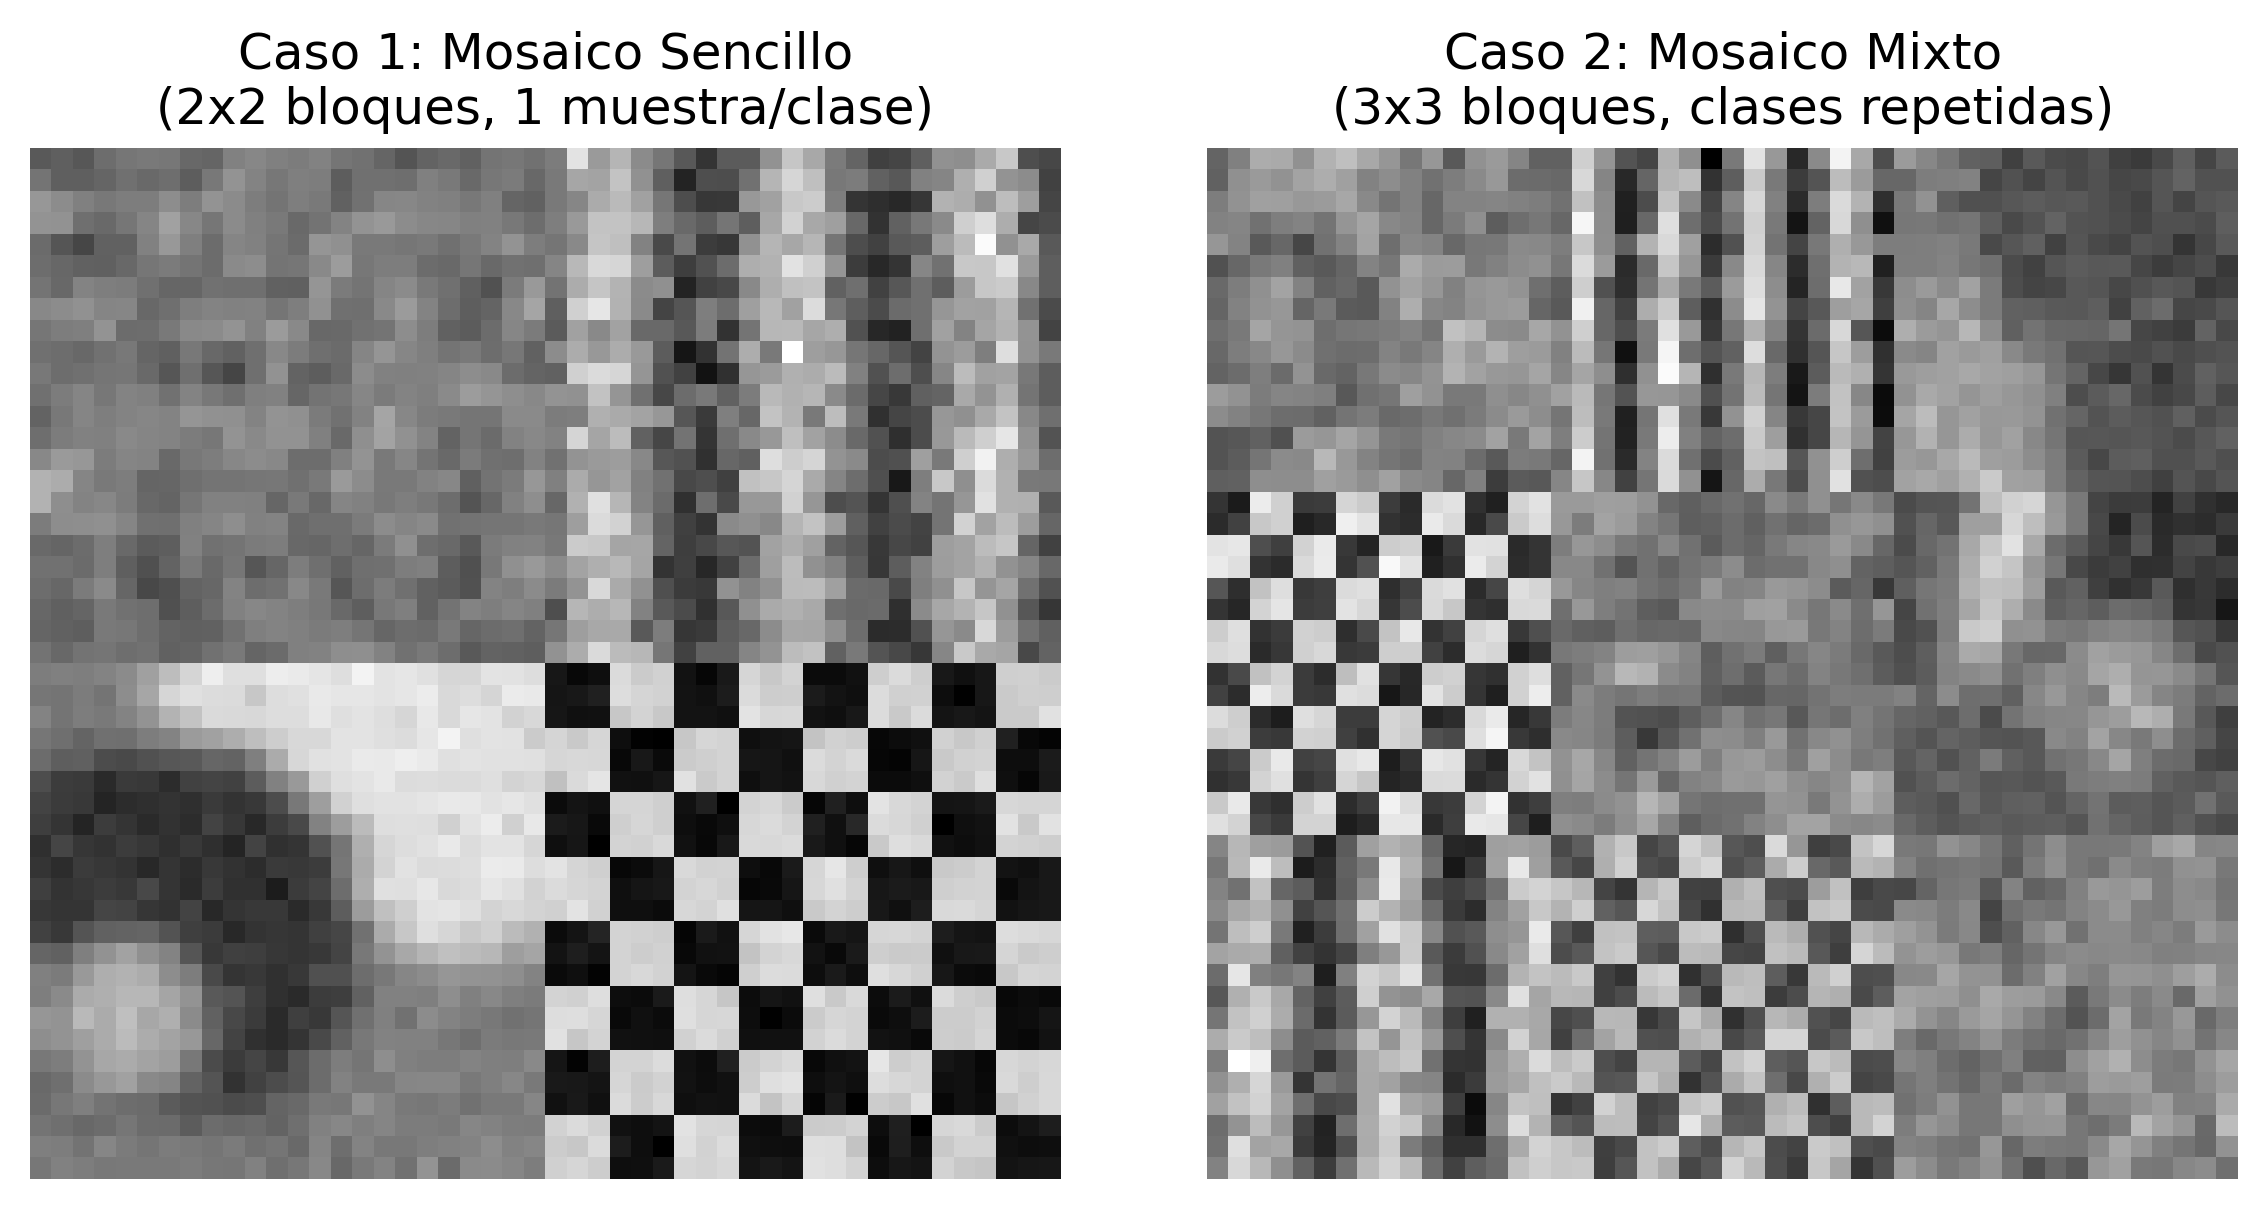

**Figura 7.27:** Mosaicos de referencia (formato PGM ASCII) utilizados en el EP07_07. Caso 1: cuadrícula 2x2 con una muestra de cada clase. Caso 2: cuadrícula 3x3 con clases repetidas y mayor variabilidad.


In [39]:
import os
import urllib.request
import numpy as np

def garantir_e_baixar_arquivo(nome_arquivo):
    diretorio_local = "dados/EP07"
    caminho_local = os.path.join(diretorio_local, nome_arquivo)
    
    # Crear el directorio local si no existe
    if not os.path.exists(diretorio_local):
        os.makedirs(diretorio_local)
        
    # Si el archivo no existe localmente, se descarga del repositorio remoto
    if not os.path.exists(caminho_local):
        url_base = "https://raw.githubusercontent.com/fzampirolli/"
        url_base += "pdi-vc/master/all/cap07/dados/EP07"
        url_arquivo = f"{url_base}/{nome_arquivo}"
        print(f"Descargando {nome_arquivo} desde GitHub...")
        try:
            urllib.request.urlretrieve(url_arquivo, caminho_local)
        except Exception as e:
            raise IOError(f"Erro ao baixar {nome_arquivo} do GitHub. ",
                          "Verifique a conexão ou a URL. Detalhes: {e}")
            
    return caminho_local

def ler_pgm_p2(caminho):
    with open(caminho) as f:
        linhas = [l for l in f.read().split() if l]
    assert linhas[0] == "P2"
    C, L = int(linhas[1]), int(linhas[2])
    maxv = int(linhas[3])
    valores = list(map(int, linhas[4:4 + L * C]))
    return np.array(valores, dtype=np.uint8).reshape(L, C)

# Garantiza la descarga y obtiene la ruta correcta
arq_caso1 = garantir_e_baixar_arquivo("Caso1_Mosaico_Simples.pgm")
arq_caso2 = garantir_e_baixar_arquivo("Caso2_Mosaico_Misto.pgm")

# Lee las matrices PGM
caso1 = ler_pgm_p2(arq_caso1)
caso2 = ler_pgm_p2(arq_caso2)

mm.show(
    [caso1, caso2],
    titles=[
        "Caso 1: Mosaico Sencillo\n(2x2 bloques, 1 muestra/clase)",
        "Caso 2: Mosaico Mixto\n(3x3 bloques, clases repetidas)",
    ],
    cols=2,
    figsize=(8, 4),
)

In [40]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML('''
<div id="sim-ep0707" style="background-color:#fef9ef;border-radius:18px;border:1px solid #ede6d8;overflow:hidden;margin-top:20px;font-family:sans-serif;">  
<style>
  #sim-ep0707 * { box-sizing: border-box; margin: 0; padding: 0; }
  #sim-ep0707 button { font-size: 11px; padding: 6px 12px; border-radius: 8px; border: 1px solid #ede6d8; background: #f3efe6; color: #5e5a4a; cursor: pointer; transition: all 0.15s ease; font-weight: 600; display: inline-flex; align-items: center; justify-content: center; gap: 5px; }
  #sim-ep0707 button:hover { background: #e8e0cf; }
  #sim-ep0707 button.sim-ep0707_active { background: #26241d !important; border-color: #26241d !important; color: #7ee7c6 !important; }
  .sim-ep0707_pill { font-size: 10px; font-weight: 700; padding: 3px 10px; border-radius: 40px; border: 1px solid #ede6d8; background: #26241d; color: #7ee7c6; font-family: monospace; }
  .sim-ep0707_panel { background: #fafaf7; border: 1px solid #e9e3d3; border-radius: 12px; padding: 12px; }
</style>
  
<!-- Cabeçalho -->
<div style="background:#f1ead7;padding:8px 16px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #e4dcc8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
  <span style="font-weight:600;color:#26241d;">🎮 Simulador EP07_07: Clasificación de Mosaico mediante LBP + k-NN</span>
  <span class="sim-ep0707_pill">⚫ pipeline completo</span>
</div>


  <div style="padding:20px;background:white;overflow:auto">
    <p style="font-size:11px;color:#777;margin-bottom:14px;text-align:center;">
Mosaico 3x3 de bloques 12x12 (L=C=36). LBP (P=8,R=1) calculado píxel a píxel, con exclusión del borde global.      Ajusta k y la métrica y observa la clasificación de cada bloque frente a 8 prototipos (2 por clase).
   
   </p>
     
<div style="background:#fff3cd;border:1px solid #ffe69c;border-radius:8px;padding:8px 12px;margin-bottom:12px;font-size:11px;color:#7a5c00;">
  ⚠️ Texturas sintéticas generadas por código, no los archivos .pgm reales del EP07_07. Usa este simulador para entender el flujo del algoritmo, no como referencia de dificultad entre las clases.
</div>
     
    <div style="background:#fafafa;border:1px solid #ddd;border-radius:12px;padding:16px;margin-bottom:16px;display:flex;gap:24px;flex-wrap:wrap;align-items:center;">
      <div style="flex:1;min-width:180px;">
        <div style="display:flex;justify-content:space-between;margin-bottom:6px;">
          <label style="font-size:12px;font-weight:bold;color:#2980b9;">k (número de vecinos)</label>
          <span id="ep0707_vl" style="font-family:monospace;font-weight:bold;color:#2980b9;">1</span>
        </div>
<input id="ep0707_sl" style="width:100%;accent-color:#2980b9;" max="5" min="1" step="2" type="range" value="1">
      </div>
      <div>
        <label style="font-size:12px;font-weight:bold;color:#2980b9;display:block;margin-bottom:6px;">Métrica</label>
        <select id="ep0707_metric" style="font-size:12px;padding:4px 8px;border-radius:6px;border:1px solid #ccc;">
          <option value="euclidiana">euclidiana</option>
          <option value="manhattan">manhattan</option>
        </select>
      </div>
    </div>

    <div style="display:flex;gap:20px;flex-wrap:wrap;align-items:flex-start;">
      <canvas id="ep0707_canvas" style="border-radius:8px;border:1px solid #ccc;"></canvas>
      <div id="ep0707_grid" style="flex:1;min-width:220px;display:grid;grid-template-columns:repeat(3,1fr);gap:8px;"></div>
    </div>

    <div id="ep0707_debug" style="margin-top:16px;background:#e3f2fd;border-radius:8px;padding:10px;border:1px solid #bbdefb;font-family:monospace;font-size:11px;color:#1565c0;white-space:pre-line;"></div>
  </div>
</div>
<script>
(function(){
  function init(root){
    if(!root || root.dataset.init) return;
    root.dataset.init = "1";

    var S = 12, G = 3, L = G * S, SCALE = 5;   // bloco maior reduz o vazamento de borda; SCALE ajustado p/ manter o canvas ~180px
    var classesOrder = ["granular", "listrada", "manchada", "xadrez"];
    // Grade 3x3 com classes repetidas, análoga ao Caso 2 do enunciado
    var layout = [
      "granular", "listrada", "manchada",
      "xadrez",   "granular", "manchada",
      "listrada", "xadrez",   "granular"
    ];

    // --- Geração determinística de textura por pixel (didática, não os PGMs reais) ---
    function h(a, b, phase){
      var v = Math.sin((a + phase) * 12.9898 + (b + phase * 0.7) * 78.233 + phase * 3.1) * 43758.5453;
      return v - Math.floor(v);
    }
    function texturePixel(cls, r, c, phase){
      phase = phase || 0;
      switch(cls){
        case "granular": return h(r, c, phase) < 0.5 ? 220 : 30;
        case "listrada": return ((c + Math.floor(phase * 2)) % 4) < 2 ? 220 : 30;
        case "manchada": return h(Math.floor(r / 3), Math.floor(c / 3), phase) < 0.5 ? 200 : 60;
        case "xadrez":   return ((Math.floor(r / 2) + Math.floor(c / 2)) % 2 === 0) ? 230 : 20;
      }
    }

    function buildImage(){
      var img = [];
      for(var r = 0; r < L; r++){
        var row = [];
        for(var c = 0; c < L; c++){
          var bi = Math.floor(r / S), bj = Math.floor(c / S);
          row.push(texturePixel(layout[bi * G + bj], r, c, 0));
        }
        img.push(row);
      }
      return img;
    }

    // --- LBP: P=8, R=1, sentido horário, s_p = 1 se vizinho >= centro ---
    function lbpBin(patch, r, c){
      var center = patch[r][c];
      var neigh = [
        patch[r-1][c-1], patch[r-1][c], patch[r-1][c+1],
        patch[r][c+1],
        patch[r+1][c+1], patch[r+1][c], patch[r+1][c-1],
        patch[r][c-1]
      ];
      var bits = neigh.map(function(v){ return v >= center ? 1 : 0; });
      var trans = 0;
      for(var i = 0; i < 8; i++){ if(bits[i] !== bits[(i+1) % 8]) trans++; }
      if(trans <= 2) return bits.reduce(function(a,b){ return a+b; }, 0); // popcount 0..8
      return 9; // não uniforme
    }

    // Histograma de um patch isolado (usado para gerar protótipos), excluindo apenas a borda do patch
    function computeLBPHist(patch){
      var n = patch.length, m = patch[0].length;
      var hist = new Array(10).fill(0), count = 0;
      for(var r = 1; r < n - 1; r++){
        for(var c = 1; c < m - 1; c++){
          hist[lbpBin(patch, r, c)]++;
          count++;
        }
      }
      for(var k = 0; k < 10; k++) hist[k] = count > 0 ? hist[k] / count : 0;
      return hist;
    }

    // Histogramas por bloco da imagem completa, excluindo só a borda global (item 4/5 do enunciado)
    function computeMosaicHistograms(img){
      var hists = [], counts = [];
      for(var i = 0; i < G*G; i++){ hists.push(new Array(10).fill(0)); counts.push(0); }
      for(var r = 1; r < L - 1; r++){
        for(var c = 1; c < L - 1; c++){
          var bin = lbpBin(img, r, c);
          var idx = Math.floor(r/S) * G + Math.floor(c/S);
          hists[idx][bin]++;
          counts[idx]++;
        }
      }
      for(var b = 0; b < hists.length; b++){
        for(var k = 0; k < 10; k++) hists[b][k] = counts[b] > 0 ? hists[b][k] / counts[b] : 0;
      }
      return hists;
    }

    // --- Protótipos: 2 por classe (N=8), ordem de leitura fixa (usada no desempate) ---
    var prototypes = [];
    classesOrder.forEach(function(cls){
      [0, 5].forEach(function(phase){
        var Sp = S + 2, patch = [];
        for(var r = 0; r < Sp; r++){
          var row = [];
          for(var c = 0; c < Sp; c++) row.push(texturePixel(cls, r, c, phase));
          patch.push(row);
        }
        prototypes.push({ classe: cls, hist: computeLBPHist(patch) });
      });
    });

    function dist(u, v, metric){
      var s = 0;
      for(var i = 0; i < u.length; i++){
        s += metric === "euclidiana" ? (u[i]-v[i])*(u[i]-v[i]) : Math.abs(u[i]-v[i]);
      }
      return metric === "euclidiana" ? Math.sqrt(s) : s;
    }

    // Desempate de distância: ordem de leitura dos protótipos. Desempate de votação: ordem das classes.
    function classify(hist, k, metric){
      var cand = prototypes.map(function(p, idx){ return { classe: p.classe, d: dist(hist, p.hist, metric), idx: idx }; });
      cand.sort(function(a, b){ return a.d !== b.d ? a.d - b.d : a.idx - b.idx; });
      var viz = cand.slice(0, k);
      var votos = {};
      viz.forEach(function(v){ votos[v.classe] = (votos[v.classe] || 0) + 1; });
      var melhor = null, melhorN = -1;
      classesOrder.forEach(function(c){
        var n = votos[c] || 0;
        if(n > melhorN){ melhorN = n; melhor = c; }
      });
      return melhor;
    }

    var canvas = root.querySelector('#ep0707_canvas');
    canvas.width = L * SCALE; canvas.height = L * SCALE;
    var ctx = canvas.getContext('2d');
    var slK = root.querySelector('#ep0707_sl');
    var vlK = root.querySelector('#ep0707_vl');
    var selMetric = root.querySelector('#ep0707_metric');
    var gridEl = root.querySelector('#ep0707_grid');
    var dbg = root.querySelector('#ep0707_debug');

    var img = buildImage();
    var hists = computeMosaicHistograms(img);

    function render(){
      var k = parseInt(slK.value);
      var metric = selMetric.value;
      vlK.textContent = k;

      var preds = [];
      for(var idx = 0; idx < G*G; idx++) preds.push(classify(hists[idx], k, metric));

      var confusion = classesOrder.map(function(){ return new Array(classesOrder.length).fill(0); });
      var acertos = 0;
      for(var i2 = 0; i2 < G*G; i2++){
        var ri = classesOrder.indexOf(layout[i2]);
        var pi = classesOrder.indexOf(preds[i2]);
        confusion[ri][pi]++;
        if(layout[i2] === preds[i2]) acertos++;
      }
      var acc = acertos / (G*G);

      // Desenha a imagem real em tons de cinza
      for(var r = 0; r < L; r++){
        for(var c = 0; c < L; c++){
          var v = img[r][c];
          ctx.fillStyle = 'rgb(' + v + ',' + v + ',' + v + ')';
          ctx.fillRect(c*SCALE, r*SCALE, SCALE, SCALE);
        }
      }
      // Contorna cada bloco: verde = acerto, vermelho = erro
      for(var idx3 = 0; idx3 < G*G; idx3++){
        var bi = Math.floor(idx3 / G), bj = idx3 % G;
        ctx.strokeStyle = (preds[idx3] === layout[idx3]) ? '#10b981' : '#f43f5e';
        ctx.lineWidth = 2;
        ctx.strokeRect(bj*S*SCALE + 1, bi*S*SCALE + 1, S*SCALE - 2, S*SCALE - 2);
      }

      // Grade textual de apoio
      gridEl.innerHTML = '';
      for(var idx4 = 0; idx4 < G*G; idx4++){
        var ok = preds[idx4] === layout[idx4];
        var card = document.createElement('div');
        card.style.cssText = 'border-radius:8px;padding:6px;text-align:center;font-size:10px;border:2px solid ' + (ok ? '#10b981' : '#f43f5e') + ';';
        card.innerHTML = 'Real: ' + layout[idx4] + '<br><b style="color:' + (ok ? '#059669' : '#e11d48') + '">Pred: ' + preds[idx4] + (ok ? ' ✅' : ' ❌') + '</b>';
        gridEl.appendChild(card);
      }

      // Saída no mesmo formato do programa (itens 7-9 do enunciado)
      var linhas = [];
      linhas.push('Classes preditas (ordem de leitura da grade):');
      linhas.push(preds.join(' '));
      linhas.push('');
      linhas.push('Matriz de confusão (linhas=real, colunas=predita; ordem ' + classesOrder.join(',') + '):');
      confusion.forEach(function(lin){ linhas.push(lin.join(' ')); });
      linhas.push('');
      linhas.push('Acuracia: ' + acc.toFixed(4));
      dbg.textContent = linhas.join('\\n');
    }

    slK.addEventListener('input', render);
    selMetric.addEventListener('change', render);
    render();
  }

  function tryInit(){
    var root = document.getElementById('sim-ep0707');
    if(root) init(root); else setTimeout(tryInit, 200);
  }
  tryInit();
})();
</script>
''')

**Figura 7.28:** Simulador EP07_07: Clasificación de un Mosaico de Texturas vía LBP + k-NN


In [41]:
%%writefile EP07_07.py
# Código Python

Overwriting EP07_07.py


In [42]:
TestSuite("EP07_07.py").run()

## Referências do Capítulo


COVER, T.; HART, P. **Nearest neighbor pattern classification**. 1967.

DALAL, N.; TRIGGS, B. **Histograms of oriented gradients for human detection**. 2005.

DUDA, Richard O.; HART, Peter E.; STORK, David G. **Pattern Classification**. New York, Wiley-Interscience, 2001.

GONZALEZ, R. C.; WOODS, R. E. **Digital Image Processing**. New York, Pearson, 2018.

OJALA, Timo; PIETIK\"{A}INEN, Matti; M\"{A}ENP\"{A}\"{A}, Topi. **Multiresolution Gray-Scale and Rotation Invariant Texture Classification with Local Binary Patterns**. USA, IEEE Computer Society, 2002.

PEDREGOSA, Fabian *et al*. **Scikit-learn: Machine Learning in Python**. 2011.

QUILICI-GONZALEZ, José Artur; ZAMPIROLLI, Francisco de Assis. **Sistemas Inteligentes e Mineração de Dados**. Editora UFABC, 2014.

QUILICI-GONZALEZ, José Artur; ZAMPIROLLI, Francisco de Assis; SOUZA, Fábio Rezende de. **Sistemas Inteligentes e Mineração de Dados: Do Weka ao Python**. 2026.

SZELISKI, Richard. **Computer Vision: Algorithms and Applications**. Springer, 2022.

{GOOGLE}. **{NotebookLM}**. 2025.